<a href="https://colab.research.google.com/github/mrupendrakushwaha/MRPL-Smart-Manufacturing/blob/main/MRPL_Smart_Management_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install streamlit pandas plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.7 MB/s eta 0:00:00


In [2]:
import os

folders = [
    "mrpl_system",
    "mrpl_system/database",
    "mrpl_system/pages",
    "mrpl_system/utils",
    "mrpl_system/assets",
    "mrpl_system/assets/products",
    "mrpl_system/data"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ MRPL project structure created successfully!")

✅ MRPL project structure created successfully!


In [3]:
for root, dirs, files in os.walk("mrpl_system"):
    level = root.replace("mrpl_system", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

mrpl_system/
    data/
    pages/
    utils/
    database/
    assets/
        products/


In [4]:
import sqlite3
import os

DB_PATH = "mrpl_system/database/mrpl.db"

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("✅ Database connected successfully!")
print("Database:", DB_PATH)

✅ Database connected successfully!
Database: mrpl_system/database/mrpl.db


In [5]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS departments (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL UNIQUE,
    description TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("✅ Departments table created!")

✅ Departments table created!


In [6]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS employees (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_code TEXT NOT NULL UNIQUE,
    name TEXT NOT NULL,
    department_id INTEGER,
    designation TEXT,
    phone TEXT,
    email TEXT,
    joining_date TEXT,
    status TEXT DEFAULT 'Active',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    FOREIGN KEY (department_id)
        REFERENCES departments(id)
)
""")

conn.commit()

print("✅ Employees table created!")

✅ Employees table created!


In [7]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT NOT NULL UNIQUE,
    password_hash TEXT NOT NULL,
    role TEXT NOT NULL,
    employee_id INTEGER,
    is_active INTEGER DEFAULT 1,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    FOREIGN KEY (employee_id)
        REFERENCES employees(id)
)
""")

conn.commit()

print("✅ Users table created!")

✅ Users table created!


In [8]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS attendance (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_id INTEGER NOT NULL,
    date TEXT NOT NULL,
    check_in TEXT,
    check_out TEXT,
    status TEXT NOT NULL,
    remarks TEXT,

    FOREIGN KEY (employee_id)
        REFERENCES employees(id),

    UNIQUE(employee_id, date)
)
""")

conn.commit()

print("✅ Attendance table created!")

✅ Attendance table created!


In [9]:
tables = {

"leave_requests": """
CREATE TABLE IF NOT EXISTS leave_requests (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_id INTEGER NOT NULL,
    start_date TEXT NOT NULL,
    end_date TEXT NOT NULL,
    reason TEXT,
    status TEXT DEFAULT 'Pending',
    approved_by INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (employee_id) REFERENCES employees(id)
)
""",

"products": """
CREATE TABLE IF NOT EXISTS products (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_code TEXT UNIQUE,
    name TEXT NOT NULL,
    category TEXT,
    description TEXT,
    specifications TEXT,
    applications TEXT,
    image_path TEXT,
    is_public INTEGER DEFAULT 1,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""",

"raw_materials": """
CREATE TABLE IF NOT EXISTS raw_materials (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    material_code TEXT UNIQUE,
    name TEXT NOT NULL,
    unit TEXT,
    minimum_stock REAL DEFAULT 0,
    supplier TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""",

"stock": """
CREATE TABLE IF NOT EXISTS stock (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    item_type TEXT NOT NULL,
    item_id INTEGER NOT NULL,
    quantity REAL DEFAULT 0,
    unit TEXT,
    location TEXT,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""",

"production": """
CREATE TABLE IF NOT EXISTS production (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_id INTEGER NOT NULL,
    batch_number TEXT UNIQUE,
    production_date TEXT,
    planned_quantity REAL,
    actual_quantity REAL,
    rejected_quantity REAL DEFAULT 0,
    status TEXT DEFAULT 'In Progress',
    FOREIGN KEY (product_id) REFERENCES products(id)
)
""",

"orders": """
CREATE TABLE IF NOT EXISTS orders (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_number TEXT UNIQUE,
    customer_name TEXT NOT NULL,
    order_date TEXT,
    required_date TEXT,
    status TEXT DEFAULT 'Pending',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""",

"order_items": """
CREATE TABLE IF NOT EXISTS order_items (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity REAL NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(id),
    FOREIGN KEY (product_id) REFERENCES products(id)
)
""",

"quality_checks": """
CREATE TABLE IF NOT EXISTS quality_checks (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    batch_number TEXT NOT NULL,
    test_name TEXT NOT NULL,
    test_value TEXT,
    specification TEXT,
    result TEXT,
    checked_by INTEGER,
    checked_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""",

"dispatch": """
CREATE TABLE IF NOT EXISTS dispatch (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    dispatch_date TEXT,
    quantity REAL,
    vehicle_number TEXT,
    transporter TEXT,
    status TEXT DEFAULT 'Pending',
    FOREIGN KEY (order_id) REFERENCES orders(id)
)
""",

"notifications": """
CREATE TABLE IF NOT EXISTS notifications (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    title TEXT NOT NULL,
    message TEXT,
    is_read INTEGER DEFAULT 0,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (user_id) REFERENCES users(id)
)
"""
}

for name, query in tables.items():
    cursor.execute(query)

conn.commit()

print("✅ All core tables created successfully!")

✅ All core tables created successfully!


In [10]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
""")

tables = cursor.fetchall()

print("📋 MRPL Database Tables:\n")

for table in tables:
    print("✔", table[0])

📋 MRPL Database Tables:

✔ attendance
✔ departments
✔ dispatch
✔ employees
✔ leave_requests
✔ notifications
✔ order_items
✔ orders
✔ production
✔ products
✔ quality_checks
✔ raw_materials
✔ sqlite_sequence
✔ stock
✔ users


In [11]:
import hashlib
import getpass

def hash_password(password):
    return hashlib.sha256(password.encode("utf-8")).hexdigest()

print("✅ Password hashing function ready!")

✅ Password hashing function ready!


In [12]:
cursor.execute("""
INSERT OR IGNORE INTO employees
(employee_code, name, designation, status)
VALUES (?, ?, ?, ?)
""", (
    "ADMIN001",
    "System Administrator",
    "Administrator",
    "Active"
))

conn.commit()

cursor.execute("""
SELECT id
FROM employees
WHERE employee_code = ?
""", ("ADMIN001",))

admin_employee_id = cursor.fetchone()[0]

print("✅ Admin employee created!")
print("Employee ID:", admin_employee_id)

✅ Admin employee created!
Employee ID: 1


In [13]:
username = input("Create Admin Username: ").strip()
password = getpass.getpass("Create Admin Password: ")

password_hash = hash_password(password)

cursor.execute("""
INSERT OR REPLACE INTO users
(username, password_hash, role, employee_id, is_active)
VALUES (?, ?, ?, ?, ?)
""", (
    username,
    password_hash,
    "Admin",
    admin_employee_id,
    1
))

conn.commit()

print("✅ Admin login created successfully!")

Create Admin Username: Upendra
Create Admin Password: ··········
✅ Admin login created successfully!


In [14]:
def verify_login(username, password):
    cursor.execute("""
    SELECT id, username, password_hash, role, employee_id
    FROM users
    WHERE username = ? AND is_active = 1
    """, (username,))

    user = cursor.fetchone()

    if user is None:
        return None

    if hash_password(password) == user[2]:
        return {
            "user_id": user[0],
            "username": user[1],
            "role": user[3],
            "employee_id": user[4]
        }

    return None


print("✅ Login verification system ready!")

✅ Login verification system ready!


In [15]:
test_username = input("Username: ").strip()
test_password = getpass.getpass("Password: ")

user = verify_login(test_username, test_password)

if user:
    print("\n✅ LOGIN SUCCESSFUL")
    print("Username:", user["username"])
    print("Role:", user["role"])
    print("Employee ID:", user["employee_id"])
else:
    print("\n❌ Invalid username or password")

Username: Upendra
Password: ··········

✅ LOGIN SUCCESSFUL
Username: Upendra
Role: Admin
Employee ID: 1


In [16]:
ROLE_PERMISSIONS = {

    "Employee": {
        "view_own_profile",
        "view_own_attendance",
        "request_leave",
        "view_own_tasks",
        "view_public_products"
    },

    "Manager": {
        "view_own_profile",
        "view_department_employees",
        "view_department_attendance",
        "manage_department_attendance",
        "approve_leave",
        "view_stock",
        "view_orders",
        "view_production",
        "view_quality",
        "view_public_products"
    },

    "Admin": {
        "view_all_employees",
        "manage_employees",
        "view_all_attendance",
        "manage_attendance",
        "manage_departments",
        "manage_stock",
        "view_all_stock",
        "manage_orders",
        "view_all_orders",
        "manage_production",
        "manage_quality",
        "manage_dispatch",
        "manage_products",
        "manage_users",
        "view_reports",
        "view_public_products"
    }
}

print("✅ Role permissions configured!")

✅ Role permissions configured!


In [17]:
def has_permission(role, permission):
    return permission in ROLE_PERMISSIONS.get(role, set())


print("Admin - Manage Stock:",
      has_permission("Admin", "manage_stock"))

print("Manager - Manage Stock:",
      has_permission("Manager", "manage_stock"))

print("Employee - Manage Stock:",
      has_permission("Employee", "manage_stock"))

Admin - Manage Stock: True
Manager - Manage Stock: False
Employee - Manage Stock: False


In [18]:
PUBLIC_MODULES = {
    "our_products"
}

def is_public_module(module):
    return module in PUBLIC_MODULES


print("Our Products:",
      is_public_module("our_products"))

Our Products: True


In [19]:
database_code = '''
import sqlite3

DB_PATH = "mrpl_system/database/mrpl.db"

def get_connection():
    conn = sqlite3.connect(DB_PATH)
    conn.execute("PRAGMA foreign_keys = ON")
    return conn
'''

with open("mrpl_system/database/database.py", "w") as f:
    f.write(database_code)

print("✅ database.py created!")

✅ database.py created!


In [20]:
auth_code = '''
import hashlib
from database.database import get_connection

def hash_password(password):
    return hashlib.sha256(
        password.encode("utf-8")
    ).hexdigest()

def verify_login(username, password):
    conn = get_connection()
    cursor = conn.cursor()

    cursor.execute("""
        SELECT id, username, password_hash, role, employee_id
        FROM users
        WHERE username = ?
        AND is_active = 1
    """, (username,))

    user = cursor.fetchone()
    conn.close()

    if user is None:
        return None

    if hash_password(password) == user[2]:
        return {
            "user_id": user[0],
            "username": user[1],
            "role": user[3],
            "employee_id": user[4]
        }

    return None
'''

with open("mrpl_system/utils/auth.py", "w") as f:
    f.write(auth_code)

print("✅ auth.py created!")

✅ auth.py created!


In [21]:
open("mrpl_system/__init__.py", "w").close()
open("mrpl_system/database/__init__.py", "w").close()
open("mrpl_system/utils/__init__.py", "w").close()

print("✅ Package structure ready!")

✅ Package structure ready!


In [22]:
for root, dirs, files in os.walk("mrpl_system"):
    level = root.replace("mrpl_system", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    └── {file}")

mrpl_system/
    └── __init__.py
    data/
    pages/
    utils/
        └── __init__.py
        └── auth.py
    database/
        └── __init__.py
        └── database.py
        └── mrpl.db
    assets/
        products/


In [23]:
schema = """
PRAGMA foreign_keys = ON;

CREATE TABLE IF NOT EXISTS departments (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL UNIQUE,
    description TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS employees (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_code TEXT NOT NULL UNIQUE,
    name TEXT NOT NULL,
    department_id INTEGER,
    designation TEXT,
    phone TEXT,
    email TEXT,
    joining_date TEXT,
    status TEXT DEFAULT 'Active',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (department_id) REFERENCES departments(id)
);

CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT NOT NULL UNIQUE,
    password_hash TEXT NOT NULL,
    role TEXT NOT NULL,
    employee_id INTEGER,
    is_active INTEGER DEFAULT 1,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (employee_id) REFERENCES employees(id)
);

CREATE TABLE IF NOT EXISTS attendance (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_id INTEGER NOT NULL,
    date TEXT NOT NULL,
    check_in TEXT,
    check_out TEXT,
    status TEXT NOT NULL,
    remarks TEXT,
    FOREIGN KEY (employee_id) REFERENCES employees(id),
    UNIQUE(employee_id, date)
);

CREATE TABLE IF NOT EXISTS leave_requests (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_id INTEGER NOT NULL,
    start_date TEXT NOT NULL,
    end_date TEXT NOT NULL,
    reason TEXT,
    status TEXT DEFAULT 'Pending',
    approved_by INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (employee_id) REFERENCES employees(id)
);

CREATE TABLE IF NOT EXISTS products (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_code TEXT UNIQUE,
    name TEXT NOT NULL,
    category TEXT,
    description TEXT,
    specifications TEXT,
    applications TEXT,
    image_path TEXT,
    is_public INTEGER DEFAULT 1,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS raw_materials (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    material_code TEXT UNIQUE,
    name TEXT NOT NULL,
    unit TEXT,
    minimum_stock REAL DEFAULT 0,
    supplier TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS stock (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    item_type TEXT NOT NULL,
    item_id INTEGER NOT NULL,
    quantity REAL DEFAULT 0,
    unit TEXT,
    location TEXT,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS production (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_id INTEGER NOT NULL,
    batch_number TEXT UNIQUE,
    production_date TEXT,
    planned_quantity REAL,
    actual_quantity REAL,
    rejected_quantity REAL DEFAULT 0,
    status TEXT DEFAULT 'In Progress',
    FOREIGN KEY (product_id) REFERENCES products(id)
);

CREATE TABLE IF NOT EXISTS orders (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_number TEXT UNIQUE,
    customer_name TEXT NOT NULL,
    order_date TEXT,
    required_date TEXT,
    status TEXT DEFAULT 'Pending',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS order_items (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity REAL NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(id),
    FOREIGN KEY (product_id) REFERENCES products(id)
);

CREATE TABLE IF NOT EXISTS quality_checks (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    batch_number TEXT NOT NULL,
    test_name TEXT NOT NULL,
    test_value TEXT,
    specification TEXT,
    result TEXT,
    checked_by INTEGER,
    checked_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS dispatch (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    dispatch_date TEXT,
    quantity REAL,
    vehicle_number TEXT,
    transporter TEXT,
    status TEXT DEFAULT 'Pending',
    FOREIGN KEY (order_id) REFERENCES orders(id)
);

CREATE TABLE IF NOT EXISTS notifications (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    title TEXT NOT NULL,
    message TEXT,
    is_read INTEGER DEFAULT 0,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (user_id) REFERENCES users(id)
);
"""

with open("mrpl_system/database/schema.sql", "w") as f:
    f.write(schema)

print("✅ schema.sql created successfully!")

✅ schema.sql created successfully!


In [24]:
init_code = '''
import os
from database.database import get_connection

SCHEMA_PATH = os.path.join(
    os.path.dirname(__file__),
    "schema.sql"
)

def initialize_database():
    conn = get_connection()

    with open(SCHEMA_PATH, "r") as f:
        schema = f.read()

    conn.executescript(schema)
    conn.commit()
    conn.close()

    print("✅ Database initialized successfully.")


if __name__ == "__main__":
    initialize_database()
'''

with open("mrpl_system/database/init_db.py", "w") as f:
    f.write(init_code)

print("✅ Fixed init_db.py created!")

✅ Fixed init_db.py created!


In [25]:
import sys

if "mrpl_system" not in sys.path:
    sys.path.append("mrpl_system")

from database.init_db import initialize_database

initialize_database()

✅ Database initialized successfully.


In [26]:
conn = sqlite3.connect("mrpl_system/database/mrpl.db")

cursor = conn.cursor()

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name
""")

for row in cursor.fetchall():
    print("✔", row[0])

conn.close()

✔ attendance
✔ departments
✔ dispatch
✔ employees
✔ leave_requests
✔ notifications
✔ order_items
✔ orders
✔ production
✔ products
✔ quality_checks
✔ raw_materials
✔ sqlite_sequence
✔ stock
✔ users


##Employee & Department Management

In [27]:
import sqlite3

DB_PATH = "mrpl_system/database/mrpl.db"

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON")
cursor = conn.cursor()

print("✅ MRPL database connected!")

✅ MRPL database connected!


In [28]:
departments = [
    ("Production", "Manufacturing and production operations"),
    ("Quality Control", "Quality testing and inspection"),
    ("Raw Material", "Raw material management and processing"),
    ("Warehouse", "Finished goods and inventory management"),
    ("Sales", "Customer and sales management"),
    ("Dispatch", "Order dispatch and logistics"),
    ("Maintenance", "Plant and equipment maintenance"),
    ("HR", "Human resource management"),
    ("Finance", "Finance and accounts"),
    ("Administration", "Administrative operations"),
    ("R&D", "Research and development"),
    ("Management", "Management and supervision")
]

cursor.executemany("""
    INSERT OR IGNORE INTO departments
    (name, description)
    VALUES (?, ?)
""", departments)

conn.commit()

print("✅ Departments added successfully!")

✅ Departments added successfully!


In [29]:
cursor.execute("""
    SELECT id, name, description
    FROM departments
    ORDER BY id
""")

rows = cursor.fetchall()

print("MRPL Departments\n")

for row in rows:
    print(f"{row[0]}. {row[1]} — {row[2]}")

MRPL Departments

1. Production — Manufacturing and production operations
2. Quality Control — Quality testing and inspection
3. Raw Material — Raw material management and processing
4. Warehouse — Finished goods and inventory management
5. Sales — Customer and sales management
6. Dispatch — Order dispatch and logistics
7. Maintenance — Plant and equipment maintenance
8. HR — Human resource management
9. Finance — Finance and accounts
10. Administration — Administrative operations
11. R&D — Research and development
12. Management — Management and supervision


In [30]:
def add_employee(
    employee_code,
    name,
    department_id,
    designation,
    phone=None,
    email=None,
    joining_date=None
):
    try:
        cursor.execute("""
            INSERT INTO employees
            (
                employee_code,
                name,
                department_id,
                designation,
                phone,
                email,
                joining_date
            )
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (
            employee_code,
            name,
            department_id,
            designation,
            phone,
            email,
            joining_date
        ))

        conn.commit()

        print(f"✅ Employee '{name}' added successfully!")

    except sqlite3.IntegrityError as e:
        print("❌ Employee could not be added.")
        print("Reason:", e)

In [31]:
def get_all_employees():
    cursor.execute("""
        SELECT
            e.id,
            e.employee_code,
            e.name,
            d.name AS department,
            e.designation,
            e.phone,
            e.email,
            e.joining_date,
            e.status
        FROM employees e
        LEFT JOIN departments d
            ON e.department_id = d.id
        ORDER BY e.id
    """)

    return cursor.fetchall()


print("✅ Employee management functions ready!")

✅ Employee management functions ready!


In [32]:
add_employee(
    employee_code="EMP001",
    name="Test Employee",
    department_id=1,
    designation="Production Executive",
    phone="9999999999",
    email="test@mrpl.com",
    joining_date="2026-09-12"
)

✅ Employee 'Test Employee' added successfully!


In [33]:
employees = get_all_employees()

print("MRPL Employees\n")

for emp in employees:
    print(
        f"ID: {emp[0]} | "
        f"Code: {emp[1]} | "
        f"Name: {emp[2]} | "
        f"Department: {emp[3]} | "
        f"Designation: {emp[4]} | "
        f"Status: {emp[8]}"
    )

MRPL Employees

ID: 1 | Code: ADMIN001 | Name: System Administrator | Department: None | Designation: Administrator | Status: Active
ID: 2 | Code: EMP001 | Name: Test Employee | Department: Production | Designation: Production Executive | Status: Active


In [34]:
def search_employees(keyword):
    keyword = f"%{keyword}%"

    cursor.execute("""
        SELECT
            e.id,
            e.employee_code,
            e.name,
            d.name,
            e.designation,
            e.status
        FROM employees e
        LEFT JOIN departments d
            ON e.department_id = d.id
        WHERE e.employee_code LIKE ?
           OR e.name LIKE ?
           OR e.designation LIKE ?
           OR d.name LIKE ?
        ORDER BY e.name
    """, (keyword, keyword, keyword, keyword))

    return cursor.fetchall()


results = search_employees("Production")

for emp in results:
    print(emp)

(2, 'EMP001', 'Test Employee', 'Production', 'Production Executive', 'Active')


In [35]:
def update_employee(
    employee_id,
    name=None,
    department_id=None,
    designation=None,
    phone=None,
    email=None
):
    cursor.execute("""
        UPDATE employees
        SET
            name = COALESCE(?, name),
            department_id = COALESCE(?, department_id),
            designation = COALESCE(?, designation),
            phone = COALESCE(?, phone),
            email = COALESCE(?, email)
        WHERE id = ?
    """, (
        name,
        department_id,
        designation,
        phone,
        email,
        employee_id
    ))

    conn.commit()

    if cursor.rowcount > 0:
        print("✅ Employee updated successfully!")
    else:
        print("❌ Employee not found.")

In [36]:
def deactivate_employee(employee_id):
    cursor.execute("""
        UPDATE employees
        SET status = 'Inactive'
        WHERE id = ?
    """, (employee_id,))

    conn.commit()

    if cursor.rowcount > 0:
        print("✅ Employee deactivated successfully!")
    else:
        print("❌ Employee not found.")

In [37]:
def get_employees_by_department(department_id):
    cursor.execute("""
        SELECT
            e.id,
            e.employee_code,
            e.name,
            d.name,
            e.designation,
            e.status
        FROM employees e
        LEFT JOIN departments d
            ON e.department_id = d.id
        WHERE e.department_id = ?
        ORDER BY e.name
    """, (department_id,))

    return cursor.fetchall()


production_employees = get_employees_by_department(1)

for emp in production_employees:
    print(emp)

(2, 'EMP001', 'Test Employee', 'Production', 'Production Executive', 'Active')


In [38]:
import getpass

def create_login_account(employee_id, username, password, role):

    if role not in ["Employee", "Manager"]:
        print("❌ Invalid role. Only Employee or Manager allowed.")
        return

    # Check employee
    cursor.execute("""
        SELECT id, name, status
        FROM employees
        WHERE id = ?
    """, (employee_id,))

    employee = cursor.fetchone()

    if employee is None:
        print("❌ Employee not found.")
        return

    if employee[2] != "Active":
        print("❌ Inactive employee cannot get a login.")
        return

    # Check existing username
    cursor.execute("""
        SELECT id
        FROM users
        WHERE username = ?
    """, (username,))

    if cursor.fetchone():
        print("❌ Username already exists.")
        return

    # Check employee already has login
    cursor.execute("""
        SELECT id
        FROM users
        WHERE employee_id = ?
    """, (employee_id,))

    if cursor.fetchone():
        print("❌ This employee already has a login account.")
        return

    password_hash = hash_password(password)

    cursor.execute("""
        INSERT INTO users
        (username, password_hash, role, employee_id, is_active)
        VALUES (?, ?, ?, ?, 1)
    """, (
        username,
        password_hash,
        role,
        employee_id
    ))

    conn.commit()

    print(f"✅ Login created for {employee[1]}")
    print(f"Role: {role}")

In [39]:
create_login_account(
    employee_id=1,
    username="employee001",
    password="Employee@123",
    role="Employee"
)

❌ This employee already has a login account.


In [40]:
add_employee(
    employee_code="MGR001",
    name="Test Manager",
    department_id=1,
    designation="Production Manager",
    phone="8888888888",
    email="manager@mrpl.com",
    joining_date="2026-09-12"
)

✅ Employee 'Test Manager' added successfully!


In [41]:
cursor.execute("""
    SELECT id, name
    FROM employees
    WHERE employee_code = ?
""", ("MGR001",))

manager = cursor.fetchone()

print(manager)

(3, 'Test Manager')


In [42]:
create_login_account(
    employee_id=manager[0],
    username="manager001",
    password="Manager@123",
    role="Manager"
)

✅ Login created for Test Manager
Role: Manager


In [43]:
cursor.execute("""
    SELECT
        u.id,
        u.username,
        u.role,
        e.employee_code,
        e.name,
        e.designation,
        u.is_active
    FROM users u
    LEFT JOIN employees e
        ON u.employee_id = e.id
    ORDER BY u.id
""")

users = cursor.fetchall()

print("MRPL LOGIN ACCOUNTS\n")

for user in users:
    print(
        f"ID: {user[0]} | "
        f"Username: {user[1]} | "
        f"Role: {user[2]} | "
        f"Employee: {user[4]} | "
        f"Active: {user[6]}"
    )

MRPL LOGIN ACCOUNTS

ID: 1 | Username: Upendra | Role: Admin | Employee: System Administrator | Active: 1
ID: 2 | Username: manager001 | Role: Manager | Employee: Test Manager | Active: 1


In [44]:
def get_dashboard_by_role(role):

    dashboards = {
        "Employee": "Employee Dashboard",
        "Manager": "Manager Dashboard",
        "Admin": "Admin Dashboard"
    }

    return dashboards.get(role, "Access Denied")


print(get_dashboard_by_role("Employee"))
print(get_dashboard_by_role("Manager"))
print(get_dashboard_by_role("Admin"))

Employee Dashboard
Manager Dashboard
Admin Dashboard


In [45]:
test_roles = ["Employee", "Manager", "Admin"]

for role in test_roles:
    print(f"\n{role}")
    print("-" * 30)

    permissions = ROLE_PERMISSIONS.get(role, set())

    for permission in sorted(permissions):
        print("✔", permission)


Employee
------------------------------
✔ request_leave
✔ view_own_attendance
✔ view_own_profile
✔ view_own_tasks
✔ view_public_products

Manager
------------------------------
✔ approve_leave
✔ manage_department_attendance
✔ view_department_attendance
✔ view_department_employees
✔ view_orders
✔ view_own_profile
✔ view_production
✔ view_public_products
✔ view_quality
✔ view_stock

Admin
------------------------------
✔ manage_attendance
✔ manage_departments
✔ manage_dispatch
✔ manage_employees
✔ manage_orders
✔ manage_production
✔ manage_products
✔ manage_quality
✔ manage_stock
✔ manage_users
✔ view_all_attendance
✔ view_all_employees
✔ view_all_orders
✔ view_all_stock
✔ view_public_products
✔ view_reports


In [46]:
def test_user_login(username, password):

    user = verify_login(username, password)

    if user:
        print("✅ Login Successful")
        print("Username :", user["username"])
        print("Role     :", user["role"])
        print("Dashboard:", get_dashboard_by_role(user["role"]))
    else:
        print("❌ Invalid username or password")

In [47]:
create_login_account(
    employee_id=2,
    username="employee001",
    password="Employee@123",
    role="Employee"
)

✅ Login created for Test Employee
Role: Employee


In [48]:
cursor.execute("""
SELECT
    id,
    username,
    role,
    employee_id,
    is_active,
    password_hash
FROM users
WHERE username = ?
""", ("employee001",))

employee_user = cursor.fetchone()

print("Employee account:")
print(employee_user)

if employee_user:
    print("\nUsername:", employee_user[1])
    print("Role:", employee_user[2])
    print("Employee ID:", employee_user[3])
    print("Active:", employee_user[4])
    print("Hash length:", len(employee_user[5]))

Employee account:
(3, 'employee001', 'Employee', 2, 1, 'b4bd29480ab196faa782e0d4ecd10c2f4212814105227e5f7992f5bf4b212a64')

Username: employee001
Role: Employee
Employee ID: 2
Active: 1
Hash length: 64


In [49]:
test_user_login(
    "Upendra",
    "Upendra@123"
)

✅ Login Successful
Username : Upendra
Role     : Admin
Dashboard: Admin Dashboard


In [50]:
test_user_login(
    "manager001",
    "Manager@123"
)

✅ Login Successful
Username : manager001
Role     : Manager
Dashboard: Manager Dashboard


In [51]:
new_password = "Employee@123"

cursor.execute("""
UPDATE users
SET password_hash = ?,
    is_active = 1
WHERE username = ?
""", (
    hash_password(new_password),
    "employee001"
))

conn.commit()

print("✅ Employee test password reset successfully!")

✅ Employee test password reset successfully!


In [52]:
cursor.execute("""
SELECT id, username, role, employee_id, is_active
FROM users
ORDER BY id
""")

all_users = cursor.fetchall()

print("ALL LOGIN ACCOUNTS\n")

for user in all_users:
    print(user)

ALL LOGIN ACCOUNTS

(1, 'Upendra', 'Admin', 1, 1)
(2, 'manager001', 'Manager', 3, 1)
(3, 'employee001', 'Employee', 2, 1)


In [53]:
cursor.execute("PRAGMA table_info(employees)")

columns = cursor.fetchall()

print("EMPLOYEES TABLE COLUMNS\n")

for col in columns:
    print(col)

EMPLOYEES TABLE COLUMNS

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'employee_code', 'TEXT', 1, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'department_id', 'INTEGER', 0, None, 0)
(4, 'designation', 'TEXT', 0, None, 0)
(5, 'phone', 'TEXT', 0, None, 0)
(6, 'email', 'TEXT', 0, None, 0)
(7, 'joining_date', 'TEXT', 0, None, 0)
(8, 'status', 'TEXT', 0, "'Active'", 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [54]:
cursor.execute("""
SELECT
    id,
    employee_code,
    name,
    department_id,
    designation,
    phone,
    email,
    joining_date,
    status
FROM employees
ORDER BY id
""")

employees = cursor.fetchall()

print("ALL EMPLOYEES\n")

for emp in employees:
    print(emp)

ALL EMPLOYEES

(1, 'ADMIN001', 'System Administrator', None, 'Administrator', None, None, None, 'Active')
(2, 'EMP001', 'Test Employee', 1, 'Production Executive', '9999999999', 'test@mrpl.com', '2026-09-12', 'Active')
(3, 'MGR001', 'Test Manager', 1, 'Production Manager', '8888888888', 'manager@mrpl.com', '2026-09-12', 'Active')


In [55]:
cursor.execute("""
SELECT
    u.id,
    u.username,
    u.role,
    u.employee_id,
    e.employee_code,
    e.name
FROM users u
LEFT JOIN employees e
    ON u.employee_id = e.id
ORDER BY u.id
""")

for user in cursor.fetchall():
    print(user)

(1, 'Upendra', 'Admin', 1, 'ADMIN001', 'System Administrator')
(2, 'manager001', 'Manager', 3, 'MGR001', 'Test Manager')
(3, 'employee001', 'Employee', 2, 'EMP001', 'Test Employee')


In [56]:
test_user_login(
    "employee001",
    "Employee@123"
)

✅ Login Successful
Username : employee001
Role     : Employee
Dashboard: Employee Dashboard


In [57]:
# ==========================================
# EMPLOYEE MANAGEMENT - VIEW ALL EMPLOYEES
# ==========================================

cursor.execute("""
SELECT
    id,
    employee_code,
    name,
    department_id,
    designation,
    phone,
    email,
    joining_date,
    status
FROM employees
ORDER BY id
""")

employees = cursor.fetchall()

print("👥 EMPLOYEE MANAGEMENT")
print("=" * 80)

for emp in employees:
    print(emp)

👥 EMPLOYEE MANAGEMENT
(1, 'ADMIN001', 'System Administrator', None, 'Administrator', None, None, None, 'Active')
(2, 'EMP001', 'Test Employee', 1, 'Production Executive', '9999999999', 'test@mrpl.com', '2026-09-12', 'Active')
(3, 'MGR001', 'Test Manager', 1, 'Production Manager', '8888888888', 'manager@mrpl.com', '2026-09-12', 'Active')


In [58]:
# ==========================================
# EMPLOYEE MANAGEMENT - ADD EMPLOYEE
# ==========================================

def add_employee(employee_code, name, department_id, designation,
                 phone, email, joining_date, status="Active"):

    cursor.execute("""
    INSERT INTO employees
    (
        employee_code,
        name,
        department_id,
        designation,
        phone,
        email,
        joining_date,
        status
    )
    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        employee_code,
        name,
        department_id,
        designation,
        phone,
        email,
        joining_date,
        status
    ))

    conn.commit()

    print("✅ Employee added successfully")
    print("Employee Code :", employee_code)
    print("Name          :", name)
    print("Designation   :", designation)
    print("Status        :", status)

In [59]:
# Check whether EMP002 already exists

cursor.execute("""
SELECT id, employee_code, name, department_id,
       designation, phone, email, joining_date, status
FROM employees
WHERE employee_code = ?
""", ("EMP002",))

existing_employee = cursor.fetchone()

print("EMP002 RECORD:")
print(existing_employee)

EMP002 RECORD:
None


In [60]:
# ==========================================
# VERIFY EMP002
# ==========================================

cursor.execute("""
SELECT
    id,
    employee_code,
    name,
    department_id,
    designation,
    phone,
    email,
    joining_date,
    status
FROM employees
WHERE employee_code = ?
""", ("EMP002",))

emp = cursor.fetchone()

if emp:
    print("✅ EMPLOYEE FOUND")
    print("ID            :", emp[0])
    print("Employee Code :", emp[1])
    print("Name          :", emp[2])
    print("Department ID :", emp[3])
    print("Designation   :", emp[4])
    print("Phone         :", emp[5])
    print("Email         :", emp[6])
    print("Joining Date  :", emp[7])
    print("Status        :", emp[8])
else:
    print("❌ EMPLOYEE NOT FOUND")

❌ EMPLOYEE NOT FOUND


In [61]:
# ==========================================
# EMPLOYEE MANAGEMENT - UPDATE EMPLOYEE
# ==========================================

def update_employee(employee_code, name=None, department_id=None,
                    designation=None, phone=None, email=None,
                    joining_date=None, status=None):

    updates = []
    values = []

    if name is not None:
        updates.append("name = ?")
        values.append(name)

    if department_id is not None:
        updates.append("department_id = ?")
        values.append(department_id)

    if designation is not None:
        updates.append("designation = ?")
        values.append(designation)

    if phone is not None:
        updates.append("phone = ?")
        values.append(phone)

    if email is not None:
        updates.append("email = ?")
        values.append(email)

    if joining_date is not None:
        updates.append("joining_date = ?")
        values.append(joining_date)

    if status is not None:
        updates.append("status = ?")
        values.append(status)

    if not updates:
        print("⚠️ No changes provided")
        return

    values.append(employee_code)

    cursor.execute(
        f"""
        UPDATE employees
        SET {", ".join(updates)}
        WHERE employee_code = ?
        """,
        values
    )

    conn.commit()

    if cursor.rowcount > 0:
        print("✅ Employee updated successfully")
        print("Employee Code :", employee_code)
    else:
        print("❌ Employee not found")

In [62]:
update_employee(
    "EMP002",
    designation="Senior Production Engineer"
)

❌ Employee not found


In [63]:
# ==========================================
# STEP 3 - DAILY ATTENDANCE
# CREATE ATTENDANCE TABLE
# ==========================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS attendance (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_id INTEGER NOT NULL,
    attendance_date TEXT NOT NULL,
    status TEXT NOT NULL DEFAULT 'Present',
    check_in TEXT,
    check_out TEXT,
    remarks TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    FOREIGN KEY (employee_id) REFERENCES employees(id),

    UNIQUE(employee_id, attendance_date)
)
""")

conn.commit()

print("✅ Attendance table created successfully")

✅ Attendance table created successfully


In [64]:
# ==========================================
# STEP 4B - FIX ADD ATTENDANCE FUNCTION
# ==========================================

def add_attendance(employee_code, attendance_date,
                   status="Present",
                   check_in=None,
                   check_out=None,
                   remarks=None):

    # Find employee
    cursor.execute("""
        SELECT id, employee_code, name
        FROM employees
        WHERE employee_code = ?
    """, (employee_code,))

    employee = cursor.fetchone()

    if employee is None:
        print("❌ Employee not found")
        return

    employee_id = employee[0]

    # Check duplicate attendance
    cursor.execute("""
        SELECT id
        FROM attendance
        WHERE employee_id = ? AND date = ?
    """, (employee_id, attendance_date))

    existing = cursor.fetchone()

    if existing:
        print("⚠️ Attendance already exists for this employee on this date")
        return

    # Insert attendance
    cursor.execute("""
        INSERT INTO attendance
        (
            employee_id,
            date,
            check_in,
            check_out,
            status,
            remarks
        )
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        employee_id,
        attendance_date,
        check_in,
        check_out,
        status,
        remarks
    ))

    conn.commit()

    print("✅ Attendance added successfully")
    print("Employee Code :", employee_code)
    print("Employee Name :", employee[2])
    print("Date          :", attendance_date)
    print("Status        :", status)

In [65]:
add_attendance(
    "EMP001",
    "2026-09-12",
    "Present",
    "09:00",
    "18:00",
    "Regular shift"
)

✅ Attendance added successfully
Employee Code : EMP001
Employee Name : Test Employee
Date          : 2026-09-12
Status        : Present


In [66]:
# ==========================================
# STEP 5 - VIEW ATTENDANCE RECORDS
# ==========================================

cursor.execute("""
SELECT
    a.id,
    e.employee_code,
    e.name,
    a.date,
    a.check_in,
    a.check_out,
    a.status,
    a.remarks
FROM attendance a
JOIN employees e
    ON a.employee_id = e.id
ORDER BY a.date DESC, a.id DESC
""")

attendance_records = cursor.fetchall()

print("ALL ATTENDANCE RECORDS\n")

if attendance_records:
    for record in attendance_records:
        print(record)
else:
    print("No attendance records found.")

ALL ATTENDANCE RECORDS

(1, 'EMP001', 'Test Employee', '2026-09-12', '09:00', '18:00', 'Present', 'Regular shift')


In [67]:
# ==========================================
# STEP 6 - UPDATE ATTENDANCE
# ==========================================

def update_attendance(employee_code, attendance_date,
                      status=None,
                      check_in=None,
                      check_out=None,
                      remarks=None):

    # Find employee
    cursor.execute("""
        SELECT id, employee_code, name
        FROM employees
        WHERE employee_code = ?
    """, (employee_code,))

    employee = cursor.fetchone()

    if employee is None:
        print("❌ Employee not found")
        return

    employee_id = employee[0]

    # Check attendance record
    cursor.execute("""
        SELECT id
        FROM attendance
        WHERE employee_id = ? AND date = ?
    """, (employee_id, attendance_date))

    attendance = cursor.fetchone()

    if attendance is None:
        print("❌ Attendance record not found")
        return

    updates = []
    values = []

    if status is not None:
        updates.append("status = ?")
        values.append(status)

    if check_in is not None:
        updates.append("check_in = ?")
        values.append(check_in)

    if check_out is not None:
        updates.append("check_out = ?")
        values.append(check_out)

    if remarks is not None:
        updates.append("remarks = ?")
        values.append(remarks)

    if not updates:
        print("⚠️ Nothing to update")
        return

    values.extend([employee_id, attendance_date])

    cursor.execute(
        f"""
        UPDATE attendance
        SET {", ".join(updates)}
        WHERE employee_id = ? AND date = ?
        """,
        values
    )

    conn.commit()

    print("✅ Attendance updated successfully")
    print("Employee Code :", employee_code)
    print("Date          :", attendance_date)

In [68]:
update_attendance(
    "EMP001",
    "2026-09-12",
    check_out="18:30",
    remarks="Overtime"
)

✅ Attendance updated successfully
Employee Code : EMP001
Date          : 2026-09-12


In [69]:
# ==========================================
# STEP 7 - DELETE ATTENDANCE
# ==========================================

def delete_attendance(employee_code, attendance_date):

    # Find employee
    cursor.execute("""
        SELECT id, name
        FROM employees
        WHERE employee_code = ?
    """, (employee_code,))

    employee = cursor.fetchone()

    if employee is None:
        print("❌ Employee not found")
        return

    employee_id = employee[0]

    # Check attendance
    cursor.execute("""
        SELECT id
        FROM attendance
        WHERE employee_id = ? AND date = ?
    """, (employee_id, attendance_date))

    attendance = cursor.fetchone()

    if attendance is None:
        print("❌ Attendance record not found")
        return

    # Delete attendance
    cursor.execute("""
        DELETE FROM attendance
        WHERE employee_id = ? AND date = ?
    """, (employee_id, attendance_date))

    conn.commit()

    print("✅ Attendance deleted successfully")
    print("Employee Code :", employee_code)
    print("Employee Name :", employee[1])
    print("Date          :", attendance_date)

In [70]:
# ==========================================
# STEP 8 - ATTENDANCE SUMMARY
# ==========================================

def attendance_summary(employee_code):

    # Find employee
    cursor.execute("""
        SELECT id, employee_code, name
        FROM employees
        WHERE employee_code = ?
    """, (employee_code,))

    employee = cursor.fetchone()

    if employee is None:
        print("❌ Employee not found")
        return

    employee_id = employee[0]

    # Attendance summary
    cursor.execute("""
        SELECT
            COUNT(*) AS total_days,
            SUM(CASE WHEN status = 'Present' THEN 1 ELSE 0 END) AS present_days,
            SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS absent_days,
            SUM(CASE WHEN status = 'Leave' THEN 1 ELSE 0 END) AS leave_days
        FROM attendance
        WHERE employee_id = ?
    """, (employee_id,))

    summary = cursor.fetchone()

    total_days = summary[0] or 0
    present_days = summary[1] or 0
    absent_days = summary[2] or 0
    leave_days = summary[3] or 0

    print("📊 ATTENDANCE SUMMARY")
    print("----------------------------")
    print("Employee Code :", employee[1])
    print("Employee Name :", employee[2])
    print("Total Days    :", total_days)
    print("Present Days  :", present_days)
    print("Absent Days   :", absent_days)
    print("Leave Days    :", leave_days)

In [71]:
attendance_summary("EMP001")

📊 ATTENDANCE SUMMARY
----------------------------
Employee Code : EMP001
Employee Name : Test Employee
Total Days    : 1
Present Days  : 1
Absent Days   : 0
Leave Days    : 0


In [72]:
# ==========================================
# STEP 9 - EMPLOYEE ATTENDANCE HISTORY
# ==========================================

def get_employee_attendance(employee_code):

    cursor.execute("""
        SELECT id, employee_code, name
        FROM employees
        WHERE employee_code = ?
    """, (employee_code,))

    employee = cursor.fetchone()

    if employee is None:
        print("❌ Employee not found")
        return

    cursor.execute("""
        SELECT
            a.date,
            a.check_in,
            a.check_out,
            a.status,
            a.remarks
        FROM attendance a
        WHERE a.employee_id = ?
        ORDER BY a.date DESC
    """, (employee[0],))

    records = cursor.fetchall()

    print("📅 ATTENDANCE HISTORY")
    print("=" * 70)
    print("Employee:", employee[1], "-", employee[2])
    print("-" * 70)

    if not records:
        print("No attendance records found.")
        return

    for record in records:
        print(
            f"Date: {record[0]} | "
            f"In: {record[1]} | "
            f"Out: {record[2]} | "
            f"Status: {record[3]} | "
            f"Remarks: {record[4]}"
        )

In [73]:
get_employee_attendance("EMP001")

📅 ATTENDANCE HISTORY
Employee: EMP001 - Test Employee
----------------------------------------------------------------------
Date: 2026-09-12 | In: 09:00 | Out: 18:30 | Status: Present | Remarks: Overtime


In [74]:
# ==========================================
# STEP 10 - DEPARTMENT ATTENDANCE
# ==========================================

def get_department_attendance(department_id, attendance_date):

    cursor.execute("""
        SELECT
            e.employee_code,
            e.name,
            e.designation,
            a.date,
            a.check_in,
            a.check_out,
            a.status,
            a.remarks
        FROM employees e
        LEFT JOIN attendance a
            ON e.id = a.employee_id
            AND a.date = ?
        WHERE e.department_id = ?
        AND e.status = 'Active'
        ORDER BY e.name
    """, (attendance_date, department_id))

    records = cursor.fetchall()

    print("📊 DEPARTMENT ATTENDANCE")
    print("=" * 80)
    print("Date:", attendance_date)
    print("-" * 80)

    if not records:
        print("No employees found.")
        return

    for record in records:
        print(
            f"Code: {record[0]} | "
            f"Name: {record[1]} | "
            f"Designation: {record[2]} | "
            f"Status: {record[6] or 'Not Marked'} | "
            f"In: {record[4] or '-'} | "
            f"Out: {record[5] or '-'}"
        )

In [75]:
get_department_attendance(
    department_id=1,
    attendance_date="2026-09-12"
)

📊 DEPARTMENT ATTENDANCE
Date: 2026-09-12
--------------------------------------------------------------------------------
Code: EMP001 | Name: Test Employee | Designation: Production Executive | Status: Present | In: 09:00 | Out: 18:30
Code: MGR001 | Name: Test Manager | Designation: Production Manager | Status: Not Marked | In: - | Out: -


In [76]:
# ============================================
# STEP 4B - EMPLOYEE ATTENDANCE REPORT
# ============================================

def get_employee_attendance(employee_code):
    cursor.execute("""
        SELECT
            e.employee_code,
            e.name,
            a.date,
            a.check_in,
            a.check_out,
            a.status,
            a.remarks
        FROM attendance a
        JOIN employees e
            ON a.employee_id = e.id
        WHERE e.employee_code = ?
        ORDER BY a.date DESC
    """, (employee_code,))

    records = cursor.fetchall()

    print("📋 EMPLOYEE ATTENDANCE REPORT")
    print("=" * 55)
    print(f"Employee Code: {employee_code}")

    if not records:
        print("No attendance records found.")
        return

    for record in records:
        print(
            f"Date: {record[2]} | "
            f"In: {record[3] or '-'} | "
            f"Out: {record[4] or '-'} | "
            f"Status: {record[5]} | "
            f"Remarks: {record[6] or '-'}"
        )

In [77]:
get_employee_attendance("EMP001")

📋 EMPLOYEE ATTENDANCE REPORT
Employee Code: EMP001
Date: 2026-09-12 | In: 09:00 | Out: 18:30 | Status: Present | Remarks: Overtime


In [78]:
# ============================================
# STEP 4C - ATTENDANCE SUMMARY (FIXED)
# ============================================

def get_attendance_summary(employee_code):

    cursor.execute("""
        SELECT
            COUNT(*) AS total_days,
            SUM(CASE WHEN a.status = 'Present' THEN 1 ELSE 0 END) AS present_days,
            SUM(CASE WHEN a.status = 'Absent' THEN 1 ELSE 0 END) AS absent_days,
            SUM(CASE WHEN a.status = 'Leave' THEN 1 ELSE 0 END) AS leave_days
        FROM attendance a
        JOIN employees e
            ON a.employee_id = e.id
        WHERE e.employee_code = ?
    """, (employee_code,))

    summary = cursor.fetchone()

    total_days = summary[0] or 0
    present_days = summary[1] or 0
    absent_days = summary[2] or 0
    leave_days = summary[3] or 0

    attendance_percentage = (
        (present_days / total_days) * 100
        if total_days > 0 else 0
    )

    print("📊 ATTENDANCE SUMMARY")
    print("=" * 40)
    print("Employee Code :", employee_code)
    print("Total Days    :", total_days)
    print("Present Days  :", present_days)
    print("Absent Days   :", absent_days)
    print("Leave Days    :", leave_days)
    print("Attendance %  :", round(attendance_percentage, 2), "%")

In [79]:
get_attendance_summary("EMP001")

📊 ATTENDANCE SUMMARY
Employee Code : EMP001
Total Days    : 1
Present Days  : 1
Absent Days   : 0
Leave Days    : 0
Attendance %  : 100.0 %


In [80]:
# ============================================================
# STEP 4 - ATTENDANCE REPORT
# ============================================================

def get_attendance_report(attendance_date=None):

    if attendance_date:
        cursor.execute("""
            SELECT
                e.employee_code,
                e.name,
                e.designation,
                a.date,
                a.status,
                a.check_in,
                a.check_out,
                a.remarks
            FROM attendance a
            JOIN employees e
                ON a.employee_id = e.id
            WHERE a.date = ?
            ORDER BY e.employee_code
        """, (attendance_date,))
    else:
        cursor.execute("""
            SELECT
                e.employee_code,
                e.name,
                e.designation,
                a.date,
                a.status,
                a.check_in,
                a.check_out,
                a.remarks
            FROM attendance a
            JOIN employees e
                ON a.employee_id = e.id
            ORDER BY a.date DESC, e.employee_code
        """)

    records = cursor.fetchall()

    print("📊 ATTENDANCE REPORT")
    print("=" * 100)

    if not records:
        print("No attendance records found.")
        return

    for record in records:
        print(
            f"Code: {record[0]} | "
            f"Name: {record[1]} | "
            f"Date: {record[3]} | "
            f"Status: {record[4]} | "
            f"In: {record[5] or '-'} | "
            f"Out: {record[6] or '-'} | "
            f"Remarks: {record[7] or '-'}"
        )

    print("=" * 100)

In [81]:
get_attendance_report("2026-09-12")

📊 ATTENDANCE REPORT
Code: EMP001 | Name: Test Employee | Date: 2026-09-12 | Status: Present | In: 09:00 | Out: 18:30 | Remarks: Overtime


In [82]:
# ============================================
# STEP 4D - UPDATE ATTENDANCE
# ============================================

def update_attendance(employee_code, attendance_date,
                      check_in=None, check_out=None,
                      status=None, remarks=None):

    # Employee ID find karo
    cursor.execute("""
        SELECT id
        FROM employees
        WHERE employee_code = ?
    """, (employee_code,))

    employee = cursor.fetchone()

    if not employee:
        print("❌ Employee not found")
        return

    employee_id = employee[0]

    # Attendance record find karo
    cursor.execute("""
        SELECT id
        FROM attendance
        WHERE employee_id = ? AND date = ?
    """, (employee_id, attendance_date))

    attendance = cursor.fetchone()

    if not attendance:
        print("❌ Attendance record not found")
        return

    attendance_id = attendance[0]

    # Update values
    updates = []
    values = []

    if check_in is not None:
        updates.append("check_in = ?")
        values.append(check_in)

    if check_out is not None:
        updates.append("check_out = ?")
        values.append(check_out)

    if status is not None:
        updates.append("status = ?")
        values.append(status)

    if remarks is not None:
        updates.append("remarks = ?")
        values.append(remarks)

    if not updates:
        print("⚠️ Nothing to update")
        return

    values.append(attendance_id)

    cursor.execute(
        f"""
        UPDATE attendance
        SET {", ".join(updates)}
        WHERE id = ?
        """,
        values
    )

    conn.commit()

    print("✅ Attendance updated successfully")
    print("Employee Code :", employee_code)
    print("Date          :", attendance_date)

In [83]:
update_attendance(
    "EMP001",
    "2026-09-12",
    check_out="18:00",
    remarks="Regular shift completed"
)

✅ Attendance updated successfully
Employee Code : EMP001
Date          : 2026-09-12


In [84]:
# ============================================
# STEP 4E - VIEW EMPLOYEE ATTENDANCE
# ============================================

def get_employee_attendance(employee_code):

    cursor.execute("""
        SELECT
            e.employee_code,
            e.name,
            a.date,
            a.status,
            a.check_in,
            a.check_out,
            a.remarks
        FROM attendance a
        JOIN employees e
            ON a.employee_id = e.id
        WHERE e.employee_code = ?
        ORDER BY a.date DESC
    """, (employee_code,))

    records = cursor.fetchall()

    if not records:
        print("❌ No attendance records found")
        return

    print("📋 EMPLOYEE ATTENDANCE")
    print("=" * 70)

    for record in records:
        print(
            f"Date: {record[2]} | "
            f"Status: {record[3]} | "
            f"In: {record[4] or '-'} | "
            f"Out: {record[5] or '-'} | "
            f"Remarks: {record[6] or '-'}"
        )

In [85]:
get_employee_attendance("EMP001")

📋 EMPLOYEE ATTENDANCE
Date: 2026-09-12 | Status: Present | In: 09:00 | Out: 18:00 | Remarks: Regular shift completed


In [86]:
# ============================================
# STEP 4F - MONTHLY ATTENDANCE REPORT
# ============================================

def get_monthly_attendance(employee_code, year_month):

    cursor.execute("""
        SELECT
            e.employee_code,
            e.name,
            a.date,
            a.status,
            a.check_in,
            a.check_out
        FROM attendance a
        JOIN employees e
            ON a.employee_id = e.id
        WHERE e.employee_code = ?
        AND substr(a.date, 1, 7) = ?
        ORDER BY a.date
    """, (employee_code, year_month))

    records = cursor.fetchall()

    if not records:
        print("❌ No attendance records found")
        return

    print("📊 MONTHLY ATTENDANCE REPORT")
    print("=" * 70)
    print("Employee Code :", employee_code)
    print("Month         :", year_month)
    print("=" * 70)

    for record in records:
        print(
            f"Date: {record[2]} | "
            f"Status: {record[3]} | "
            f"In: {record[4] or '-'} | "
            f"Out: {record[5] or '-'}"
        )

    print("=" * 70)
    print("Total Records :", len(records))

In [87]:
get_monthly_attendance(
    "EMP001",
    "2026-09"
)

📊 MONTHLY ATTENDANCE REPORT
Employee Code : EMP001
Month         : 2026-09
Date: 2026-09-12 | Status: Present | In: 09:00 | Out: 18:00
Total Records : 1


In [88]:
# ============================================
# STEP 4G - DEPARTMENT ATTENDANCE SUMMARY
# ============================================

def get_department_attendance_summary(department_id, attendance_date):

    cursor.execute("""
        SELECT
            COUNT(*) AS total_employees,
            SUM(CASE WHEN a.status = 'Present' THEN 1 ELSE 0 END) AS present,
            SUM(CASE WHEN a.status = 'Absent' THEN 1 ELSE 0 END) AS absent,
            SUM(CASE WHEN a.status = 'Leave' THEN 1 ELSE 0 END) AS leave
        FROM attendance a
        JOIN employees e
            ON a.employee_id = e.id
        WHERE e.department_id = ?
        AND a.date = ?
    """, (department_id, attendance_date))

    result = cursor.fetchone()

    total = result[0] or 0
    present = result[1] or 0
    absent = result[2] or 0
    leave = result[3] or 0

    percentage = (present / total * 100) if total > 0 else 0

    print("📊 DEPARTMENT ATTENDANCE SUMMARY")
    print("=" * 45)
    print("Department ID :", department_id)
    print("Date          :", attendance_date)
    print("Total         :", total)
    print("Present       :", present)
    print("Absent        :", absent)
    print("Leave         :", leave)
    print("Attendance %  :", round(percentage, 2), "%")

In [89]:
get_department_attendance_summary(
    1,
    "2026-09-12"
)

📊 DEPARTMENT ATTENDANCE SUMMARY
Department ID : 1
Date          : 2026-09-12
Total         : 1
Present       : 1
Absent        : 0
Leave         : 0
Attendance %  : 100.0 %


In [90]:
# ============================================
# STEP 4H - ATTENDANCE DASHBOARD DATA
# ============================================

def get_attendance_dashboard(attendance_date):

    cursor.execute("""
        SELECT
            COUNT(DISTINCT e.id) AS total_employees,
            COUNT(DISTINCT CASE
                WHEN a.status = 'Present' THEN e.id
            END) AS present,
            COUNT(DISTINCT CASE
                WHEN a.status = 'Absent' THEN e.id
            END) AS absent,
            COUNT(DISTINCT CASE
                WHEN a.status = 'Leave' THEN e.id
            END) AS leave
        FROM employees e
        LEFT JOIN attendance a
            ON e.id = a.employee_id
            AND a.date = ?
        WHERE e.status = 'Active'
    """, (attendance_date,))

    result = cursor.fetchone()

    total = result[0] or 0
    present = result[1] or 0
    absent = result[2] or 0
    leave = result[3] or 0

    not_marked = total - (present + absent + leave)

    percentage = (
        (present / total) * 100
        if total > 0 else 0
    )

    print("📊 ATTENDANCE DASHBOARD")
    print("=" * 45)
    print("Date          :", attendance_date)
    print("Total Employees:", total)
    print("Present       :", present)
    print("Absent        :", absent)
    print("Leave         :", leave)
    print("Not Marked    :", not_marked)
    print("Attendance %  :", round(percentage, 2), "%")

In [91]:
get_attendance_dashboard("2026-09-12")

📊 ATTENDANCE DASHBOARD
Date          : 2026-09-12
Total Employees: 3
Present       : 1
Absent        : 0
Leave         : 0
Not Marked    : 2
Attendance %  : 33.33 %


###Raw Material / Stock Management

In [92]:
# ============================================
# STEP 5 - RAW MATERIAL MANAGEMENT
# CREATE RAW MATERIAL TABLE
# ============================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS raw_materials (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    material_code TEXT UNIQUE NOT NULL,
    material_name TEXT NOT NULL,
    category TEXT,
    unit TEXT NOT NULL,
    current_stock REAL DEFAULT 0,
    minimum_stock REAL DEFAULT 0,
    supplier TEXT,
    last_updated TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("✅ Raw material table created successfully")

✅ Raw material table created successfully


In [93]:
cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
AND name='raw_materials'
""")

result = cursor.fetchone()

if result:
    print("✅ raw_materials table verified")
else:
    print("❌ Table not found")

✅ raw_materials table verified


In [94]:
# ============================================
# CELL 1 - RAW MATERIAL TABLE
# ============================================

cursor.execute("""
CREATE TABLE IF NOT EXISTS raw_materials (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    material_code TEXT UNIQUE NOT NULL,
    material_name TEXT NOT NULL,
    category TEXT,
    unit TEXT NOT NULL,
    current_stock REAL DEFAULT 0,
    minimum_stock REAL DEFAULT 0,
    supplier TEXT,
    last_updated TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("✅ Raw material table ready")

✅ Raw material table ready


In [95]:
# ============================================
# CELL 8 - FIX RAW MATERIAL TABLE
# ============================================

# Add missing columns only if they do not exist

cursor.execute("PRAGMA table_info(raw_materials)")
existing_columns = [col[1] for col in cursor.fetchall()]

if "material_name" not in existing_columns:
    cursor.execute("""
        ALTER TABLE raw_materials
        ADD COLUMN material_name TEXT
    """)

if "category" not in existing_columns:
    cursor.execute("""
        ALTER TABLE raw_materials
        ADD COLUMN category TEXT
    """)

if "current_stock" not in existing_columns:
    cursor.execute("""
        ALTER TABLE raw_materials
        ADD COLUMN current_stock REAL DEFAULT 0
    """)

# Existing "name" data ko material_name me copy karo
cursor.execute("""
    UPDATE raw_materials
    SET material_name = name
    WHERE material_name IS NULL
""")

conn.commit()

print("✅ Raw material table structure fixed")
print("✅ Existing data preserved")

✅ Raw material table structure fixed
✅ Existing data preserved


In [96]:
# ============================================
# CELL 9 - VERIFY FIXED TABLE
# ============================================

cursor.execute("PRAGMA table_info(raw_materials)")
columns = cursor.fetchall()

print("📦 UPDATED RAW MATERIAL TABLE")
print("=" * 60)

for col in columns:
    print(col)

📦 UPDATED RAW MATERIAL TABLE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'material_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'unit', 'TEXT', 0, None, 0)
(4, 'minimum_stock', 'REAL', 0, '0', 0)
(5, 'supplier', 'TEXT', 0, None, 0)
(6, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
(7, 'material_name', 'TEXT', 0, None, 0)
(8, 'category', 'TEXT', 0, None, 0)
(9, 'current_stock', 'REAL', 0, '0', 0)


In [97]:
# ============================================================
# CELL 11 - VIEW ALL RAW MATERIALS
# ============================================================

def get_all_raw_materials():
    cursor.execute("""
        SELECT
            id,
            material_code,
            name,
            unit,
            minimum_stock,
            supplier
        FROM raw_materials
        ORDER BY id
    """)

    records = cursor.fetchall()

    print("\n📦 RAW MATERIAL INVENTORY")
    print("=" * 70)

    if not records:
        print("No raw materials found.")
        return

    for record in records:
        print(f"ID              : {record[0]}")
        print(f"Material Code   : {record[1]}")
        print(f"Material Name   : {record[2]}")
        print(f"Unit            : {record[3]}")
        print(f"Minimum Stock   : {record[4]}")
        print(f"Supplier        : {record[5]}")
        print("-" * 70)

In [98]:
# ============================================
# FIX - ADD RAW MATERIAL FUNCTION
# ============================================

def add_raw_material(
    material_code,
    material_name,
    category,
    unit,
    current_stock,
    minimum_stock,
    supplier
):
    try:
        cursor.execute("""
            INSERT INTO raw_materials
            (material_code, name, unit, minimum_stock, supplier, category, current_stock)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (
            material_code,
            material_name,
            unit,
            minimum_stock,
            supplier,
            category,
            current_stock
        ))

        conn.commit()
        print("✅ Raw material added successfully")
        print("Material Code :", material_code)
        print("Material Name :", material_name)

    except Exception as e:
        print("❌ Error:", e)

In [99]:
# ============================================
# CHECK EXISTING RAW MATERIAL DATA
# ============================================

cursor.execute("""
SELECT *
FROM raw_materials
""")

rows = cursor.fetchall()

print("📦 EXISTING RAW MATERIALS")
print("=" * 80)

for row in rows:
    print(row)

print("\nTOTAL RECORDS:", len(rows))

📦 EXISTING RAW MATERIALS

TOTAL RECORDS: 0


In [100]:
# ============================================
# CHECK UNIQUE CONSTRAINT + EXISTING RECORDS
# ============================================

print("🔍 RAW MATERIAL TABLE CHECK")
print("=" * 70)

# Existing records
cursor.execute("""
SELECT id, material_code, name, unit,
       minimum_stock, supplier, category, current_stock
FROM raw_materials
ORDER BY id
""")

rows = cursor.fetchall()

print("\n📦 EXISTING RECORDS:")
for row in rows:
    print(row)

print("\nTOTAL RECORDS:", len(rows))

# Table indexes / unique constraints
cursor.execute("""
PRAGMA index_list(raw_materials)
""")

indexes = cursor.fetchall()

print("\n🔐 TABLE INDEXES / UNIQUE CONSTRAINTS:")
for index in indexes:
    print(index)

🔍 RAW MATERIAL TABLE CHECK

📦 EXISTING RECORDS:

TOTAL RECORDS: 0

🔐 TABLE INDEXES / UNIQUE CONSTRAINTS:
(0, 'sqlite_autoindex_raw_materials_1', 1, 'u', 0)


In [101]:
cursor.execute("SELECT * FROM raw_materials")
rows = cursor.fetchall()

for row in rows:
    print(row)

In [102]:
# CHECK TOTAL RAW MATERIALS IN DATABASE

cursor.execute("""
SELECT COUNT(*)
FROM raw_materials
""")

count = cursor.fetchone()[0]

print("📦 RAW MATERIAL COUNT:", count)

📦 RAW MATERIAL COUNT: 0


In [103]:
# VIEW ALL RAW MATERIALS

cursor.execute("""
SELECT
    id,
    material_code,
    name,
    category,
    unit,
    current_stock,
    minimum_stock,
    supplier
FROM raw_materials
ORDER BY id
""")

rows = cursor.fetchall()

print("📦 RAW MATERIALS")
print("=" * 80)

if rows:
    for row in rows:
        print(row)
else:
    print("No raw materials found.")

📦 RAW MATERIALS
No raw materials found.


In [104]:
# SEARCH RAW MATERIAL BY CODE

def search_raw_material(material_code):

    cursor.execute("""
    SELECT
        id,
        material_code,
        name,
        category,
        unit,
        current_stock,
        minimum_stock,
        supplier
    FROM raw_materials
    WHERE material_code = ?
    """, (material_code,))

    row = cursor.fetchone()

    if row:
        print("📦 RAW MATERIAL FOUND")
        print("=" * 50)
        print("ID            :", row[0])
        print("Material Code :", row[1])
        print("Name          :", row[2])
        print("Category      :", row[3])
        print("Unit          :", row[4])
        print("Current Stock :", row[5])
        print("Minimum Stock :", row[6])
        print("Supplier      :", row[7])
    else:
        print("❌ Raw material not found.")

In [105]:
search_raw_material("RM001")

❌ Raw material not found.


In [106]:
# CHECK LOW STOCK RAW MATERIALS

cursor.execute("""
SELECT
    material_code,
    name,
    current_stock,
    minimum_stock,
    unit,
    supplier
FROM raw_materials
WHERE current_stock <= minimum_stock
ORDER BY current_stock ASC
""")

rows = cursor.fetchall()

print("⚠️ LOW STOCK MATERIALS")
print("=" * 70)

if rows:
    for row in rows:
        print(row)
else:
    print("✅ No low-stock raw materials found.")

⚠️ LOW STOCK MATERIALS
✅ No low-stock raw materials found.


In [107]:
# UPDATE RAW MATERIAL STOCK

def update_raw_material_stock(material_code, new_stock):

    cursor.execute("""
    UPDATE raw_materials
    SET current_stock = ?
    WHERE material_code = ?
    """, (new_stock, material_code))

    conn.commit()

    if cursor.rowcount > 0:
        print("✅ Stock updated successfully")
    else:
        print("❌ Material not found")

In [108]:
update_raw_material_stock("RM001", 20)

❌ Material not found


In [109]:
# VERIFY UPDATED RAW MATERIAL STOCK

cursor.execute("""
SELECT material_code, name, current_stock, minimum_stock, unit
FROM raw_materials
WHERE material_code = ?
""", ("RM001",))

row = cursor.fetchone()

print("📦 UPDATED STOCK")
print("=" * 50)

if row:
    print("Material Code :", row[0])
    print("Material Name :", row[1])
    print("Current Stock :", row[2])
    print("Minimum Stock :", row[3])
    print("Unit          :", row[4])
else:
    print("❌ Material not found")

📦 UPDATED STOCK
❌ Material not found


In [110]:
# CHECK LOW STOCK AFTER STOCK UPDATE

cursor.execute("""
SELECT material_code, name, current_stock, minimum_stock, unit
FROM raw_materials
WHERE current_stock <= minimum_stock
ORDER BY current_stock ASC
""")

rows = cursor.fetchall()

print("⚠️ LOW STOCK MATERIALS")
print("=" * 70)

for row in rows:
    print(row)

⚠️ LOW STOCK MATERIALS


In [111]:
# CREATE PRODUCTION TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS production (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    production_code TEXT UNIQUE NOT NULL,
    product_name TEXT NOT NULL,
    production_date TEXT NOT NULL,
    planned_quantity REAL DEFAULT 0,
    produced_quantity REAL DEFAULT 0,
    unit TEXT NOT NULL,
    status TEXT DEFAULT 'Planned',
    remarks TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("✅ Production table created successfully")

✅ Production table created successfully


In [112]:
# ADD PRODUCTION RECORD

def add_production(
    production_code,
    product_name,
    production_date,
    planned_quantity,
    produced_quantity,
    unit,
    status="Planned",
    remarks=""
):
    try:
        cursor.execute("""
        INSERT INTO production
        (
            production_code,
            product_name,
            production_date,
            planned_quantity,
            produced_quantity,
            unit,
            status,
            remarks
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            production_code,
            product_name,
            production_date,
            planned_quantity,
            produced_quantity,
            unit,
            status,
            remarks
        ))

        conn.commit()

        print("✅ Production record added successfully")
        print("Production Code :", production_code)
        print("Product Name    :", product_name)

    except Exception as e:
        print("❌ Error:", e)

In [113]:
# TEST PRODUCTION RECORD

add_production(
    production_code="PRD001",
    product_name="Refractory Brick",
    production_date="2026-09-12",
    planned_quantity=100,
    produced_quantity=0,
    unit="MT",
    status="Planned",
    remarks="Initial production plan"
)

❌ Error: table production has no column named production_code


In [114]:
# FIX - CHECK PRODUCTION TABLE COLUMNS

cursor.execute("PRAGMA table_info(production)")
columns = cursor.fetchall()

print("🏭 PRODUCTION TABLE STRUCTURE")
print("=" * 60)

for col in columns:
    print(col)

🏭 PRODUCTION TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_id', 'INTEGER', 1, None, 0)
(2, 'batch_number', 'TEXT', 0, None, 0)
(3, 'production_date', 'TEXT', 0, None, 0)
(4, 'planned_quantity', 'REAL', 0, None, 0)
(5, 'actual_quantity', 'REAL', 0, None, 0)
(6, 'rejected_quantity', 'REAL', 0, '0', 0)
(7, 'status', 'TEXT', 0, "'In Progress'", 0)


In [115]:
# PRODUCTION TABLE - SHOW ALL COLUMN NAMES

cursor.execute("PRAGMA table_info(production)")
columns = cursor.fetchall()

for col in columns:
    print(col[1])

id
product_id
batch_number
production_date
planned_quantity
actual_quantity
rejected_quantity
status


In [116]:
# PRODUCTION TABLE - CHECK COMPLETE STRUCTURE

cursor.execute("PRAGMA table_info(production)")
columns = cursor.fetchall()

print("🏭 PRODUCTION TABLE")
print("=" * 60)

for col in columns:
    print("Column:", col[1], "| Type:", col[2])

🏭 PRODUCTION TABLE
Column: id | Type: INTEGER
Column: product_id | Type: INTEGER
Column: batch_number | Type: TEXT
Column: production_date | Type: TEXT
Column: planned_quantity | Type: REAL
Column: actual_quantity | Type: REAL
Column: rejected_quantity | Type: REAL
Column: status | Type: TEXT


In [117]:
# CHECK PRODUCT TABLE

cursor.execute("PRAGMA table_info(products)")
columns = cursor.fetchall()

print("📦 PRODUCT TABLE")
print("=" * 60)

for col in columns:
    print(col)

📦 PRODUCT TABLE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'category', 'TEXT', 0, None, 0)
(4, 'description', 'TEXT', 0, None, 0)
(5, 'specifications', 'TEXT', 0, None, 0)
(6, 'applications', 'TEXT', 0, None, 0)
(7, 'image_path', 'TEXT', 0, None, 0)
(8, 'is_public', 'INTEGER', 0, '1', 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [118]:
# DATABASE - CHECK ALL TABLES AND COLUMNS

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
""")

tables = cursor.fetchall()

print("🗄️ DATABASE TABLES")
print("=" * 60)

for table in tables:
    table_name = table[0]
    print(f"\n📌 {table_name}")

    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()

    for col in columns:
        print(f"   - {col[1]} ({col[2]})")

🗄️ DATABASE TABLES

📌 attendance
   - id (INTEGER)
   - employee_id (INTEGER)
   - date (TEXT)
   - check_in (TEXT)
   - check_out (TEXT)
   - status (TEXT)
   - remarks (TEXT)

📌 departments
   - id (INTEGER)
   - name (TEXT)
   - description (TEXT)
   - created_at (TIMESTAMP)

📌 dispatch
   - id (INTEGER)
   - order_id (INTEGER)
   - dispatch_date (TEXT)
   - quantity (REAL)
   - vehicle_number (TEXT)
   - transporter (TEXT)
   - status (TEXT)

📌 employees
   - id (INTEGER)
   - employee_code (TEXT)
   - name (TEXT)
   - department_id (INTEGER)
   - designation (TEXT)
   - phone (TEXT)
   - email (TEXT)
   - joining_date (TEXT)
   - status (TEXT)
   - created_at (TIMESTAMP)

📌 leave_requests
   - id (INTEGER)
   - employee_id (INTEGER)
   - start_date (TEXT)
   - end_date (TEXT)
   - reason (TEXT)
   - status (TEXT)
   - approved_by (INTEGER)
   - created_at (TIMESTAMP)

📌 notifications
   - id (INTEGER)
   - user_id (INTEGER)
   - title (TEXT)
   - message (TEXT)
   - is_read (INTEG

In [119]:
# CHECK PRODUCTION AND PRODUCT TABLES

for table_name in ["production", "products"]:
    print(f"\n📌 {table_name.upper()}")
    print("=" * 60)

    cursor.execute(f"PRAGMA table_info({table_name})")
    for col in cursor.fetchall():
        print(col)


📌 PRODUCTION
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_id', 'INTEGER', 1, None, 0)
(2, 'batch_number', 'TEXT', 0, None, 0)
(3, 'production_date', 'TEXT', 0, None, 0)
(4, 'planned_quantity', 'REAL', 0, None, 0)
(5, 'actual_quantity', 'REAL', 0, None, 0)
(6, 'rejected_quantity', 'REAL', 0, '0', 0)
(7, 'status', 'TEXT', 0, "'In Progress'", 0)

📌 PRODUCTS
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'category', 'TEXT', 0, None, 0)
(4, 'description', 'TEXT', 0, None, 0)
(5, 'specifications', 'TEXT', 0, None, 0)
(6, 'applications', 'TEXT', 0, None, 0)
(7, 'image_path', 'TEXT', 0, None, 0)
(8, 'is_public', 'INTEGER', 0, '1', 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [120]:
# FIX - ADD PRODUCTION FUNCTION

def add_production(
    product_id,
    batch_number,
    production_date,
    planned_quantity,
    actual_quantity,
    rejected_quantity,
    status="Planned"
):
    try:
        cursor.execute("""
            INSERT INTO production
            (
                product_id,
                batch_number,
                production_date,
                planned_quantity,
                actual_quantity,
                rejected_quantity,
                status
            )
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (
            product_id,
            batch_number,
            production_date,
            planned_quantity,
            actual_quantity,
            rejected_quantity,
            status
        ))

        conn.commit()

        print("✅ Production record added successfully")
        print("Batch Number :", batch_number)
        print("Product ID   :", product_id)

    except Exception as e:
        print("❌ Error:", e)

In [121]:
# CHECK PRODUCTS

cursor.execute("SELECT id, product_code, name FROM products")
products = cursor.fetchall()

print("📦 PRODUCTS")
for product in products:
    print(product)

📦 PRODUCTS


In [122]:
# ADD FIRST PRODUCT

cursor.execute("""
INSERT INTO products
(product_code, name, category, description)
VALUES (?, ?, ?, ?)
""", (
    "PRD001",
    "Refractory Brick",
    "Refractory",
    "Industrial refractory brick"
))

conn.commit()

print("✅ Product added successfully")

✅ Product added successfully


In [123]:
# CHECK PRODUCT ID

cursor.execute("""
SELECT id, product_code, name
FROM products
""")

for product in cursor.fetchall():
    print(product)

(1, 'PRD001', 'Refractory Brick')


In [124]:
# TEST - ADD PRODUCTION RECORD

add_production(
    product_id=1,
    batch_number="B001",
    production_date="2026-09-12",
    planned_quantity=100,
    actual_quantity=0,
    rejected_quantity=0,
    status="In Progress"
)

✅ Production record added successfully
Batch Number : B001
Product ID   : 1


In [125]:
# CHECK PRODUCTION RECORD

cursor.execute("""
SELECT
    id,
    product_id,
    batch_number,
    production_date,
    planned_quantity,
    actual_quantity,
    rejected_quantity,
    status
FROM production
""")

records = cursor.fetchall()

print("🏭 PRODUCTION RECORDS")
print("=" * 80)

for record in records:
    print(record)

🏭 PRODUCTION RECORDS
(1, 1, 'B001', '2026-09-12', 100.0, 0.0, 0.0, 'In Progress')


In [126]:
# PRODUCTION SUMMARY

cursor.execute("""
SELECT
    COUNT(*) AS total_batches,
    SUM(planned_quantity) AS total_planned,
    SUM(actual_quantity) AS total_actual,
    SUM(rejected_quantity) AS total_rejected
FROM production
""")

summary = cursor.fetchone()

print("🏭 PRODUCTION SUMMARY")
print("=" * 50)
print("Total Batches     :", summary[0])
print("Total Planned     :", summary[1])
print("Total Actual      :", summary[2])
print("Total Rejected    :", summary[3])

🏭 PRODUCTION SUMMARY
Total Batches     : 1
Total Planned     : 100.0
Total Actual      : 0.0
Total Rejected    : 0.0


In [127]:
# VIEW ALL PRODUCTION RECORDS

cursor.execute("""
SELECT
    p.id,
    p.product_id,
    pr.name,
    p.batch_number,
    p.production_date,
    p.planned_quantity,
    p.actual_quantity,
    p.rejected_quantity,
    p.status
FROM production p
JOIN products pr
    ON p.product_id = pr.id
ORDER BY p.production_date DESC, p.id DESC
""")

records = cursor.fetchall()

print("🏭 PRODUCTION RECORDS")
print("=" * 100)

if records:
    for record in records:
        print(record)
else:
    print("No production records found.")

🏭 PRODUCTION RECORDS
(1, 1, 'Refractory Brick', 'B001', '2026-09-12', 100.0, 0.0, 0.0, 'In Progress')


In [128]:
# UPDATE PRODUCTION RECORD

def update_production(
    batch_number,
    actual_quantity=None,
    rejected_quantity=None,
    status=None
):
    updates = []
    values = []

    if actual_quantity is not None:
        updates.append("actual_quantity = ?")
        values.append(actual_quantity)

    if rejected_quantity is not None:
        updates.append("rejected_quantity = ?")
        values.append(rejected_quantity)

    if status is not None:
        updates.append("status = ?")
        values.append(status)

    if not updates:
        print("⚠️ Nothing to update")
        return

    values.append(batch_number)

    cursor.execute(
        f"""
        UPDATE production
        SET {", ".join(updates)}
        WHERE batch_number = ?
        """,
        values
    )

    conn.commit()

    if cursor.rowcount > 0:
        print("✅ Production record updated successfully")
    else:
        print("❌ Batch not found")

In [129]:
# TEST PRODUCTION UPDATE

update_production(
    batch_number="B001",
    actual_quantity=95,
    rejected_quantity=5,
    status="Completed"
)

✅ Production record updated successfully


In [130]:
# PRODUCTION PERFORMANCE SUMMARY

cursor.execute("""
SELECT
    COUNT(*) AS total_batches,
    COALESCE(SUM(planned_quantity), 0),
    COALESCE(SUM(actual_quantity), 0),
    COALESCE(SUM(rejected_quantity), 0)
FROM production
""")

summary = cursor.fetchone()

total_batches = summary[0]
total_planned = summary[1]
total_actual = summary[2]
total_rejected = summary[3]

production_percentage = (
    (total_actual / total_planned) * 100
    if total_planned > 0 else 0
)

rejection_percentage = (
    (total_rejected / total_actual) * 100
    if total_actual > 0 else 0
)

print("🏭 PRODUCTION PERFORMANCE")
print("=" * 60)
print("Total Batches       :", total_batches)
print("Total Planned       :", total_planned)
print("Total Actual        :", total_actual)
print("Total Rejected      :", total_rejected)
print("Production %        :", round(production_percentage, 2), "%")
print("Rejection %         :", round(rejection_percentage, 2), "%")

🏭 PRODUCTION PERFORMANCE
Total Batches       : 1
Total Planned       : 100.0
Total Actual        : 95.0
Total Rejected      : 5.0
Production %        : 95.0 %
Rejection %         : 5.26 %


In [131]:
# PRODUCTION STATUS SUMMARY

cursor.execute("""
SELECT
    status,
    COUNT(*) AS total_records
FROM production
GROUP BY status
ORDER BY status
""")

records = cursor.fetchall()

print("🏭 PRODUCTION STATUS")
print("=" * 50)

if records:
    for record in records:
        print("Status :", record[0], "| Total :", record[1])
else:
    print("No production records found.")

🏭 PRODUCTION STATUS
Status : Completed | Total : 1


In [132]:
# VIEW PRODUCTION BATCH DETAILS

def get_production_batch(batch_number):

    cursor.execute("""
    SELECT
        p.id,
        p.product_id,
        pr.name,
        p.batch_number,
        p.production_date,
        p.planned_quantity,
        p.actual_quantity,
        p.rejected_quantity,
        p.status
    FROM production p
    JOIN products pr
        ON p.product_id = pr.id
    WHERE p.batch_number = ?
    """, (batch_number,))

    record = cursor.fetchone()

    print("🏭 PRODUCTION BATCH DETAILS")
    print("=" * 60)

    if record:
        print("ID                :", record[0])
        print("Product ID        :", record[1])
        print("Product Name      :", record[2])
        print("Batch Number      :", record[3])
        print("Production Date   :", record[4])
        print("Planned Quantity  :", record[5])
        print("Actual Quantity   :", record[6])
        print("Rejected Quantity :", record[7])
        print("Status            :", record[8])
    else:
        print("❌ Batch not found")

In [133]:
get_production_batch("B001")

🏭 PRODUCTION BATCH DETAILS
ID                : 1
Product ID        : 1
Product Name      : Refractory Brick
Batch Number      : B001
Production Date   : 2026-09-12
Planned Quantity  : 100.0
Actual Quantity   : 95.0
Rejected Quantity : 5.0
Status            : Completed


###Quality Control

In [134]:
# CREATE QUALITY CONTROL TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS quality_control (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    production_id INTEGER NOT NULL,
    inspection_date TEXT NOT NULL,
    test_name TEXT NOT NULL,
    test_value REAL,
    specification TEXT,
    result TEXT,
    remarks TEXT,
    FOREIGN KEY (production_id) REFERENCES production(id)
)
""")

conn.commit()

print("✅ Quality control table created successfully")

✅ Quality control table created successfully


In [135]:
# ADD QUALITY CONTROL RECORD

def add_quality_control(
    production_id,
    inspection_date,
    test_name,
    test_value,
    specification,
    result,
    remarks=""
):
    try:
        cursor.execute("""
        INSERT INTO quality_control
        (
            production_id,
            inspection_date,
            test_name,
            test_value,
            specification,
            result,
            remarks
        )
        VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (
            production_id,
            inspection_date,
            test_name,
            test_value,
            specification,
            result,
            remarks
        ))

        conn.commit()

        print("✅ Quality control record added successfully")

    except Exception as e:
        print("❌ Error:", e)

In [136]:
# TEST QUALITY CONTROL RECORD

add_quality_control(
    production_id=1,
    inspection_date="2026-09-12",
    test_name="Compressive Strength",
    test_value=50,
    specification=">= 45 MPa",
    result="Pass",
    remarks="Initial quality test"
)

✅ Quality control record added successfully


In [137]:
# VIEW QUALITY CONTROL RECORDS

cursor.execute("""
SELECT
    qc.id,
    qc.production_id,
    p.batch_number,
    pr.name,
    qc.inspection_date,
    qc.test_name,
    qc.test_value,
    qc.specification,
    qc.result,
    qc.remarks
FROM quality_control qc
JOIN production p
    ON qc.production_id = p.id
JOIN products pr
    ON p.product_id = pr.id
ORDER BY qc.inspection_date DESC, qc.id DESC
""")

records = cursor.fetchall()

print("🔎 QUALITY CONTROL RECORDS")
print("=" * 110)

if records:
    for record in records:
        print(record)
else:
    print("No quality control records found.")

🔎 QUALITY CONTROL RECORDS
(1, 1, 'B001', 'Refractory Brick', '2026-09-12', 'Compressive Strength', 50.0, '>= 45 MPa', 'Pass', 'Initial quality test')


In [138]:
# VIEW QC DETAILS FOR A PRODUCTION BATCH

def get_quality_control_by_batch(batch_number):

    cursor.execute("""
    SELECT
        qc.id,
        p.batch_number,
        pr.name,
        qc.inspection_date,
        qc.test_name,
        qc.test_value,
        qc.specification,
        qc.result,
        qc.remarks
    FROM quality_control qc
    JOIN production p
        ON qc.production_id = p.id
    JOIN products pr
        ON p.product_id = pr.id
    WHERE p.batch_number = ?
    ORDER BY qc.inspection_date DESC
    """, (batch_number,))

    records = cursor.fetchall()

    print("🔎 QUALITY CONTROL - BATCH DETAILS")
    print("=" * 100)

    if records:
        for record in records:
            print(record)
    else:
        print("No QC records found for this batch.")

In [139]:
get_quality_control_by_batch("B001")

🔎 QUALITY CONTROL - BATCH DETAILS
(1, 'B001', 'Refractory Brick', '2026-09-12', 'Compressive Strength', 50.0, '>= 45 MPa', 'Pass', 'Initial quality test')


In [140]:
# QUALITY CONTROL SUMMARY

cursor.execute("""
SELECT
    COUNT(*) AS total_tests,
    SUM(CASE WHEN result = 'Pass' THEN 1 ELSE 0 END) AS passed,
    SUM(CASE WHEN result = 'Fail' THEN 1 ELSE 0 END) AS failed
FROM quality_control
""")

summary = cursor.fetchone()

total_tests = summary[0] or 0
passed = summary[1] or 0
failed = summary[2] or 0

pass_percentage = (
    (passed / total_tests) * 100
    if total_tests > 0 else 0
)

print("🔎 QUALITY CONTROL SUMMARY")
print("=" * 60)
print("Total Tests   :", total_tests)
print("Passed        :", passed)
print("Failed        :", failed)
print("Pass %        :", round(pass_percentage, 2), "%")

🔎 QUALITY CONTROL SUMMARY
Total Tests   : 1
Passed        : 1
Failed        : 0
Pass %        : 100.0 %


In [141]:
# CHECK QUALITY STATUS OF PRODUCTION BATCH

def check_batch_quality(batch_number):

    cursor.execute("""
    SELECT
        COUNT(*) AS total_tests,
        SUM(CASE WHEN qc.result = 'Pass' THEN 1 ELSE 0 END) AS passed,
        SUM(CASE WHEN qc.result = 'Fail' THEN 1 ELSE 0 END) AS failed
    FROM quality_control qc
    JOIN production p
        ON qc.production_id = p.id
    WHERE p.batch_number = ?
    """, (batch_number,))

    result = cursor.fetchone()

    total_tests = result[0] or 0
    passed = result[1] or 0
    failed = result[2] or 0

    print("🔎 BATCH QUALITY STATUS")
    print("=" * 50)
    print("Batch Number :", batch_number)
    print("Total Tests  :", total_tests)
    print("Passed       :", passed)
    print("Failed       :", failed)

    if failed > 0:
        print("Result       : ❌ FAIL")
    elif total_tests > 0:
        print("Result       : ✅ PASS")
    else:
        print("Result       : ⚠️ NO TEST")

In [142]:
check_batch_quality("B001")

🔎 BATCH QUALITY STATUS
Batch Number : B001
Total Tests  : 1
Passed       : 1
Failed       : 0
Result       : ✅ PASS


In [143]:
# VIEW FAILED QUALITY CONTROL RECORDS

cursor.execute("""
SELECT
    qc.id,
    p.batch_number,
    pr.name,
    qc.inspection_date,
    qc.test_name,
    qc.test_value,
    qc.specification,
    qc.result
FROM quality_control qc
JOIN production p
    ON qc.production_id = p.id
JOIN products pr
    ON p.product_id = pr.id
WHERE qc.result = 'Fail'
ORDER BY qc.inspection_date DESC
""")

records = cursor.fetchall()

print("❌ FAILED QUALITY RECORDS")
print("=" * 100)

if records:
    for record in records:
        print(record)
else:
    print("✅ No failed quality records found.")

❌ FAILED QUALITY RECORDS
✅ No failed quality records found.


In [144]:
# SHOW QUALITY RESULT FOR ALL PRODUCTION BATCHES

cursor.execute("""
SELECT
    p.batch_number,
    pr.name,
    COUNT(qc.id) AS total_tests,
    SUM(CASE WHEN qc.result = 'Pass' THEN 1 ELSE 0 END) AS passed,
    SUM(CASE WHEN qc.result = 'Fail' THEN 1 ELSE 0 END) AS failed
FROM production p
JOIN products pr
    ON p.product_id = pr.id
LEFT JOIN quality_control qc
    ON p.id = qc.production_id
GROUP BY p.id, p.batch_number, pr.name
ORDER BY p.production_date DESC
""")

records = cursor.fetchall()

print("🔎 QUALITY RESULT BY PRODUCTION BATCH")
print("=" * 100)

if records:
    for record in records:
        print(record)
else:
    print("No production batches found.")

🔎 QUALITY RESULT BY PRODUCTION BATCH
('B001', 'Refractory Brick', 1, 1, 0)


###Finished Goods / Warehouse

In [145]:
# CREATE FINISHED GOODS TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS finished_goods (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_id INTEGER NOT NULL,
    batch_number TEXT NOT NULL,
    quantity REAL DEFAULT 0,
    unit TEXT NOT NULL,
    warehouse_location TEXT,
    status TEXT DEFAULT 'Available',
    FOREIGN KEY (product_id) REFERENCES products(id)
)
""")

conn.commit()

print("✅ Finished goods table created successfully")

✅ Finished goods table created successfully


In [146]:
# ADD FINISHED GOODS RECORD

def add_finished_goods(
    product_id,
    batch_number,
    quantity,
    unit,
    warehouse_location,
    status="Available"
):
    try:
        cursor.execute("""
        INSERT INTO finished_goods
        (
            product_id,
            batch_number,
            quantity,
            unit,
            warehouse_location,
            status
        )
        VALUES (?, ?, ?, ?, ?, ?)
        """, (
            product_id,
            batch_number,
            quantity,
            unit,
            warehouse_location,
            status
        ))

        conn.commit()

        print("✅ Finished goods record added successfully")

    except Exception as e:
        print("❌ Error:", e)

In [147]:
# TEST FINISHED GOODS RECORD

add_finished_goods(
    product_id=1,
    batch_number="B001",
    quantity=95,
    unit="MT",
    warehouse_location="Warehouse A",
    status="Available"
)

✅ Finished goods record added successfully


In [148]:
# VIEW FINISHED GOODS INVENTORY

cursor.execute("""
SELECT
    fg.id,
    fg.product_id,
    p.name,
    fg.batch_number,
    fg.quantity,
    fg.unit,
    fg.warehouse_location,
    fg.status
FROM finished_goods fg
JOIN products p
    ON fg.product_id = p.id
ORDER BY fg.id DESC
""")

records = cursor.fetchall()

print("📦 FINISHED GOODS INVENTORY")
print("=" * 100)

if records:
    for record in records:
        print(record)
else:
    print("No finished goods found.")

📦 FINISHED GOODS INVENTORY
(1, 1, 'Refractory Brick', 'B001', 95.0, 'MT', 'Warehouse A', 'Available')


In [149]:
# UPDATE FINISHED GOODS STOCK

def update_finished_goods_stock(
    finished_goods_id,
    new_quantity,
    status="Available"
):
    try:
        cursor.execute("""
        UPDATE finished_goods
        SET quantity = ?, status = ?
        WHERE id = ?
        """, (
            new_quantity,
            status,
            finished_goods_id
        ))

        conn.commit()

        if cursor.rowcount > 0:
            print("✅ Finished goods stock updated successfully")
        else:
            print("❌ Finished goods record not found")

    except Exception as e:
        print("❌ Error:", e)

In [150]:
# TEST - UPDATE FINISHED GOODS STOCK

update_finished_goods_stock(
    finished_goods_id=1,
    new_quantity=90,
    status="Available"
)

✅ Finished goods stock updated successfully


In [151]:
# VERIFY UPDATED STOCK

cursor.execute("""
SELECT
    id,
    product_id,
    batch_number,
    quantity,
    unit,
    warehouse_location,
    status
FROM finished_goods
ORDER BY id DESC
""")

records = cursor.fetchall()

print("📦 UPDATED FINISHED GOODS STOCK")
print("=" * 80)

for record in records:
    print(record)

📦 UPDATED FINISHED GOODS STOCK
(1, 1, 'B001', 90.0, 'MT', 'Warehouse A', 'Available')


###Order Management

In [152]:
# CREATE ORDERS TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS orders (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_number TEXT UNIQUE NOT NULL,
    customer_name TEXT NOT NULL,
    order_date TEXT NOT NULL,
    product_id INTEGER NOT NULL,
    quantity REAL NOT NULL,
    unit TEXT NOT NULL,
    delivery_date TEXT,
    status TEXT DEFAULT 'Pending',
    remarks TEXT,
    FOREIGN KEY (product_id) REFERENCES products(id)
)
""")

conn.commit()

print("✅ Orders table created successfully")

✅ Orders table created successfully


In [153]:
# ADD NEW ORDER

def add_order(
    order_number,
    customer_name,
    order_date,
    product_id,
    quantity,
    unit,
    delivery_date=None,
    status="Pending",
    remarks=""
):
    try:
        cursor.execute("""
        INSERT INTO orders
        (
            order_number,
            customer_name,
            order_date,
            product_id,
            quantity,
            unit,
            delivery_date,
            status,
            remarks
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            order_number,
            customer_name,
            order_date,
            product_id,
            quantity,
            unit,
            delivery_date,
            status,
            remarks
        ))

        conn.commit()

        print("✅ Order added successfully")
        print("Order Number :", order_number)
        print("Customer     :", customer_name)

    except Exception as e:
        print("❌ Error:", e)

In [154]:
# FIX EXISTING ORDERS TABLE

columns_to_add = [
    ("product_id", "INTEGER"),
    ("quantity", "REAL"),
    ("unit", "TEXT"),
    ("delivery_date", "TEXT"),
    ("remarks", "TEXT")
]

for column_name, column_type in columns_to_add:
    try:
        cursor.execute(
            f"ALTER TABLE orders ADD COLUMN {column_name} {column_type}"
        )
        print(f"✅ Added: {column_name}")
    except Exception as e:
        if "duplicate column name" in str(e).lower():
            print(f"ℹ️ Already exists: {column_name}")
        else:
            print(f"❌ Error adding {column_name}:", e)

conn.commit()

print("\n✅ Orders table structure updated")

✅ Added: product_id
✅ Added: quantity
✅ Added: unit
✅ Added: delivery_date
✅ Added: remarks

✅ Orders table structure updated


In [155]:
# VERIFY ORDERS TABLE

cursor.execute("PRAGMA table_info(orders)")

for column in cursor.fetchall():
    print(column)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_number', 'TEXT', 0, None, 0)
(2, 'customer_name', 'TEXT', 1, None, 0)
(3, 'order_date', 'TEXT', 0, None, 0)
(4, 'required_date', 'TEXT', 0, None, 0)
(5, 'status', 'TEXT', 0, "'Pending'", 0)
(6, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
(7, 'product_id', 'INTEGER', 0, None, 0)
(8, 'quantity', 'REAL', 0, None, 0)
(9, 'unit', 'TEXT', 0, None, 0)
(10, 'delivery_date', 'TEXT', 0, None, 0)
(11, 'remarks', 'TEXT', 0, None, 0)


In [156]:
# TEST - ADD ORDER RECORD

add_order(
    order_number="ORD001",
    customer_name="ABC Refractories",
    order_date="2026-09-12",
    product_id=1,
    quantity=20,
    unit="MT",
    delivery_date="2026-09-20",
    status="Pending",
    remarks="Initial customer order"
)

✅ Order added successfully
Order Number : ORD001
Customer     : ABC Refractories


In [157]:
# VERIFY - ORDERS RECORD

cursor.execute("""
SELECT
    id,
    order_number,
    customer_name,
    order_date,
    product_id,
    quantity,
    unit,
    delivery_date,
    status,
    remarks
FROM orders
""")

orders = cursor.fetchall()

print("📦 ORDERS")

for order in orders:
    print(order)

📦 ORDERS
(1, 'ORD001', 'ABC Refractories', '2026-09-12', 1, 20.0, 'MT', '2026-09-20', 'Pending', 'Initial customer order')


In [158]:
# CHECK - FINISHED GOODS / STOCK TABLE

cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()

print("📦 DATABASE TABLES")

for table in tables:
    print(table[0])

📦 DATABASE TABLES
departments
sqlite_sequence
employees
users
attendance
leave_requests
products
raw_materials
stock
production
orders
order_items
quality_checks
dispatch
notifications
quality_control
finished_goods


In [159]:
# CHECK - FINISHED GOODS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(finished_goods)")

for column in cursor.fetchall():
    print(column)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_id', 'INTEGER', 1, None, 0)
(2, 'batch_number', 'TEXT', 1, None, 0)
(3, 'quantity', 'REAL', 0, '0', 0)
(4, 'unit', 'TEXT', 1, None, 0)
(5, 'warehouse_location', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Available'", 0)


In [160]:
# CHECK - FINISHED GOODS STRUCTURE & RECORDS

cursor.execute("PRAGMA table_info(finished_goods)")
columns = cursor.fetchall()

print("📦 FINISHED GOODS TABLE STRUCTURE")
for column in columns:
    print(column)

print("\n📋 EXISTING FINISHED GOODS RECORDS")

cursor.execute("SELECT * FROM finished_goods")
records = cursor.fetchall()

for record in records:
    print(record)

📦 FINISHED GOODS TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_id', 'INTEGER', 1, None, 0)
(2, 'batch_number', 'TEXT', 1, None, 0)
(3, 'quantity', 'REAL', 0, '0', 0)
(4, 'unit', 'TEXT', 1, None, 0)
(5, 'warehouse_location', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Available'", 0)

📋 EXISTING FINISHED GOODS RECORDS
(1, 1, 'B001', 90.0, 'MT', 'Warehouse A', 'Available')


In [161]:
# TEST - ADD FINISHED GOODS RECORD

cursor.execute("""
INSERT INTO finished_goods
(product_id, batch_number, quantity, unit, warehouse_location, status)
VALUES (?, ?, ?, ?, ?, ?)
""", (
    1,
    "B001",
    100,
    "MT",
    "Warehouse-A",
    "Available"
))

conn.commit()

print("✅ Finished goods record added successfully")

✅ Finished goods record added successfully


In [162]:
# VERIFY - FINISHED GOODS RECORD

cursor.execute("""
SELECT
    id,
    product_id,
    batch_number,
    quantity,
    unit,
    warehouse_location,
    status
FROM finished_goods
""")

finished_goods = cursor.fetchall()

print("📦 FINISHED GOODS")

for item in finished_goods:
    print(item)

📦 FINISHED GOODS
(1, 1, 'B001', 90.0, 'MT', 'Warehouse A', 'Available')
(2, 1, 'B001', 100.0, 'MT', 'Warehouse-A', 'Available')


### Dispatch

In [163]:
# CHECK - DISPATCH TABLE STRUCTURE

cursor.execute("PRAGMA table_info(dispatch)")

for column in cursor.fetchall():
    print(column)

(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_id', 'INTEGER', 1, None, 0)
(2, 'dispatch_date', 'TEXT', 0, None, 0)
(3, 'quantity', 'REAL', 0, None, 0)
(4, 'vehicle_number', 'TEXT', 0, None, 0)
(5, 'transporter', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Pending'", 0)


In [164]:
# CHECK - DISPATCH TABLE STRUCTURE

cursor.execute("PRAGMA table_info(dispatch)")

dispatch_columns = cursor.fetchall()

print("🚚 DISPATCH TABLE STRUCTURE")

for column in dispatch_columns:
    print(column)

🚚 DISPATCH TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_id', 'INTEGER', 1, None, 0)
(2, 'dispatch_date', 'TEXT', 0, None, 0)
(3, 'quantity', 'REAL', 0, None, 0)
(4, 'vehicle_number', 'TEXT', 0, None, 0)
(5, 'transporter', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Pending'", 0)


In [165]:
# CHECK - DISPATCH TABLE

cursor.execute("PRAGMA table_info(dispatch)")
columns = cursor.fetchall()

print("🚚 DISPATCH TABLE STRUCTURE")

for column in columns:
    print(column)

print("\n📋 EXISTING DISPATCH RECORDS")

cursor.execute("SELECT * FROM dispatch")
for record in cursor.fetchall():
    print(record)

🚚 DISPATCH TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_id', 'INTEGER', 1, None, 0)
(2, 'dispatch_date', 'TEXT', 0, None, 0)
(3, 'quantity', 'REAL', 0, None, 0)
(4, 'vehicle_number', 'TEXT', 0, None, 0)
(5, 'transporter', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Pending'", 0)

📋 EXISTING DISPATCH RECORDS


In [166]:
# CHECK - DISPATCH TABLE AND RECORDS

cursor.execute("PRAGMA table_info(dispatch)")
columns = cursor.fetchall()

print("🚚 DISPATCH TABLE STRUCTURE")

for column in columns:
    print(column)

print("\n📋 EXISTING DISPATCH RECORDS")

cursor.execute("SELECT * FROM dispatch")

for record in cursor.fetchall():
    print(record)

🚚 DISPATCH TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_id', 'INTEGER', 1, None, 0)
(2, 'dispatch_date', 'TEXT', 0, None, 0)
(3, 'quantity', 'REAL', 0, None, 0)
(4, 'vehicle_number', 'TEXT', 0, None, 0)
(5, 'transporter', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Pending'", 0)

📋 EXISTING DISPATCH RECORDS


In [167]:
# TEST - ADD DISPATCH RECORD

cursor.execute("""
INSERT INTO dispatch
(order_id, dispatch_date, quantity, vehicle_number, transporter, status)
VALUES (?, ?, ?, ?, ?, ?)
""", (
    1,
    "2026-09-12",
    20,
    "MP20AB1234",
    "ABC Transport",
    "Pending"
))

conn.commit()

print("✅ Dispatch record added successfully")

✅ Dispatch record added successfully


In [168]:
# VERIFY - DISPATCH RECORD

cursor.execute("""
SELECT
    id,
    order_id,
    dispatch_date,
    quantity,
    vehicle_number,
    transporter,
    status
FROM dispatch
""")

dispatch_records = cursor.fetchall()

print("🚚 DISPATCH RECORDS")

for record in dispatch_records:
    print(record)

🚚 DISPATCH RECORDS
(1, 1, '2026-09-12', 20.0, 'MP20AB1234', 'ABC Transport', 'Pending')


In [169]:
# CHECK - QUALITY CONTROL TABLE STRUCTURE

cursor.execute("PRAGMA table_info(quality_control)")

quality_columns = cursor.fetchall()

print("🔬 QUALITY CONTROL TABLE STRUCTURE")

for column in quality_columns:
    print(column)

🔬 QUALITY CONTROL TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'production_id', 'INTEGER', 1, None, 0)
(2, 'inspection_date', 'TEXT', 1, None, 0)
(3, 'test_name', 'TEXT', 1, None, 0)
(4, 'test_value', 'REAL', 0, None, 0)
(5, 'specification', 'TEXT', 0, None, 0)
(6, 'result', 'TEXT', 0, None, 0)
(7, 'remarks', 'TEXT', 0, None, 0)


In [170]:
# CHECK - QUALITY CONTROL TABLE

cursor.execute("PRAGMA table_info(quality_control)")
columns = cursor.fetchall()

print("🔬 QUALITY CONTROL STRUCTURE")

for column in columns:
    print(column)

🔬 QUALITY CONTROL STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'production_id', 'INTEGER', 1, None, 0)
(2, 'inspection_date', 'TEXT', 1, None, 0)
(3, 'test_name', 'TEXT', 1, None, 0)
(4, 'test_value', 'REAL', 0, None, 0)
(5, 'specification', 'TEXT', 0, None, 0)
(6, 'result', 'TEXT', 0, None, 0)
(7, 'remarks', 'TEXT', 0, None, 0)


In [171]:

# TEST - ADD DISPATCH RECORD

try:
    cursor.execute("""
        INSERT INTO dispatch (
            order_id,
            dispatch_date,
            quantity,
            vehicle_number,
            transporter,
            status
        )
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        1,
        "2026-09-12",
        20,
        "MP20AB1234",
        "ABC Transport",
        "Pending"
    ))

    conn.commit()

    print("✅ Dispatch record added successfully")
    print("Order ID :", 1)
    print("Quantity :", 20)
    print("Status   :", "Pending")

except Exception as e:
    print("❌ Error:", e)

✅ Dispatch record added successfully
Order ID : 1
Quantity : 20
Status   : Pending


In [172]:
# VERIFY - DISPATCH RECORD

cursor.execute("""
    SELECT
        id,
        order_id,
        dispatch_date,
        quantity,
        vehicle_number,
        transporter,
        status
    FROM dispatch
""")

dispatch_records = cursor.fetchall()

print("🚚 DISPATCH RECORDS")

for record in dispatch_records:
    print(record)

🚚 DISPATCH RECORDS
(1, 1, '2026-09-12', 20.0, 'MP20AB1234', 'ABC Transport', 'Pending')
(2, 1, '2026-09-12', 20.0, 'MP20AB1234', 'ABC Transport', 'Pending')


In [173]:
# TEST - ADD FINISHED GOODS RECORD

try:
    cursor.execute("""
        INSERT INTO finished_goods (
            product_id,
            batch_number,
            quantity,
            unit,
            warehouse_location,
            status
        )
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        1,
        "B001",
        20,
        "MT",
        "Warehouse-A",
        "Available"
    ))

    conn.commit()

    print("✅ Finished goods record added successfully")
    print("Product ID :", 1)
    print("Batch      :", "B001")
    print("Quantity   :", 20)
    print("Status     :", "Available")

except Exception as e:
    print("❌ Error:", e)

✅ Finished goods record added successfully
Product ID : 1
Batch      : B001
Quantity   : 20
Status     : Available


In [174]:
# VERIFY - FINISHED GOODS RECORD

cursor.execute("""
    SELECT
        id,
        product_id,
        batch_number,
        quantity,
        unit,
        warehouse_location,
        status
    FROM finished_goods
""")

finished_goods_records = cursor.fetchall()

print("📦 FINISHED GOODS")

for record in finished_goods_records:
    print(record)

📦 FINISHED GOODS
(1, 1, 'B001', 90.0, 'MT', 'Warehouse A', 'Available')
(2, 1, 'B001', 100.0, 'MT', 'Warehouse-A', 'Available')
(3, 1, 'B001', 20.0, 'MT', 'Warehouse-A', 'Available')


In [175]:
# CHECK - QUALITY CHECKS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(quality_checks)")

quality_columns = cursor.fetchall()

print("🔍 QUALITY CHECKS TABLE STRUCTURE")

for column in quality_columns:
    print(column)

🔍 QUALITY CHECKS TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'batch_number', 'TEXT', 1, None, 0)
(2, 'test_name', 'TEXT', 1, None, 0)
(3, 'test_value', 'TEXT', 0, None, 0)
(4, 'specification', 'TEXT', 0, None, 0)
(5, 'result', 'TEXT', 0, None, 0)
(6, 'checked_by', 'INTEGER', 0, None, 0)
(7, 'checked_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [176]:
# TEST - ADD QUALITY CHECK

try:
    cursor.execute("""
        INSERT INTO quality_checks (
            batch_number,
            test_name,
            test_value,
            specification,
            result,
            checked_by
        )
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        "B001",
        "Compressive Strength",
        "85 MPa",
        "Minimum 80 MPa",
        "PASS",
        1
    ))

    conn.commit()

    print("✅ Quality check added successfully")
    print("Batch      :", "B001")
    print("Test       :", "Compressive Strength")
    print("Result     :", "PASS")

except Exception as e:
    print("❌ Error:", e)

✅ Quality check added successfully
Batch      : B001
Test       : Compressive Strength
Result     : PASS


In [177]:
# VERIFY - QUALITY CHECK RECORD

cursor.execute("""
    SELECT
        id,
        batch_number,
        test_name,
        test_value,
        specification,
        result,
        checked_by,
        checked_at
    FROM quality_checks
""")

quality_records = cursor.fetchall()

print("🔍 QUALITY CHECK RECORDS")

for record in quality_records:
    print(record)

🔍 QUALITY CHECK RECORDS
(1, 'B001', 'Compressive Strength', '85 MPa', 'Minimum 80 MPa', 'PASS', 1, '2026-09-13 02:45:36')


In [178]:
# CHECK - QUALITY CONTROL TABLE STRUCTURE

cursor.execute("PRAGMA table_info(quality_control)")

qc_columns = cursor.fetchall()

print("🔍 QUALITY CONTROL TABLE STRUCTURE")

for column in qc_columns:
    print(column)

🔍 QUALITY CONTROL TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'production_id', 'INTEGER', 1, None, 0)
(2, 'inspection_date', 'TEXT', 1, None, 0)
(3, 'test_name', 'TEXT', 1, None, 0)
(4, 'test_value', 'REAL', 0, None, 0)
(5, 'specification', 'TEXT', 0, None, 0)
(6, 'result', 'TEXT', 0, None, 0)
(7, 'remarks', 'TEXT', 0, None, 0)


In [179]:
# TEST - ADD QUALITY CONTROL RECORD

try:
    cursor.execute("""
        INSERT INTO quality_control (
            production_id,
            inspection_date,
            test_name,
            test_value,
            specification,
            result,
            remarks
        )
        VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (
        1,
        "2026-09-12",
        "Compressive Strength",
        85.0,
        "Minimum 80 MPa",
        "PASS",
        "Quality inspection completed"
    ))

    conn.commit()

    print("✅ Quality control record added successfully")
    print("Production ID :", 1)
    print("Test          :", "Compressive Strength")
    print("Result        :", "PASS")

except Exception as e:
    print("❌ Error:", e)

✅ Quality control record added successfully
Production ID : 1
Test          : Compressive Strength
Result        : PASS


In [180]:
# VERIFY - QUALITY CONTROL RECORD

cursor.execute("""
    SELECT
        id,
        production_id,
        inspection_date,
        test_name,
        test_value,
        specification,
        result,
        remarks
    FROM quality_control
""")

qc_records = cursor.fetchall()

print("🔍 QUALITY CONTROL RECORDS")

for record in qc_records:
    print(record)

🔍 QUALITY CONTROL RECORDS
(1, 1, '2026-09-12', 'Compressive Strength', 50.0, '>= 45 MPa', 'Pass', 'Initial quality test')
(2, 1, '2026-09-12', 'Compressive Strength', 85.0, 'Minimum 80 MPa', 'PASS', 'Quality inspection completed')


In [181]:
# CHECK - NOTIFICATIONS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(notifications)")

notification_columns = cursor.fetchall()

print("🔔 NOTIFICATIONS TABLE STRUCTURE")

for column in notification_columns:
    print(column)

🔔 NOTIFICATIONS TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'user_id', 'INTEGER', 0, None, 0)
(2, 'title', 'TEXT', 1, None, 0)
(3, 'message', 'TEXT', 0, None, 0)
(4, 'is_read', 'INTEGER', 0, '0', 0)
(5, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [182]:
# 🔔 VERIFY - NOTIFICATIONS RECORDS

cursor.execute("""
    SELECT
        id,
        user_id,
        title,
        message,
        is_read,
        created_at
    FROM notifications
""")

notification_records = cursor.fetchall()

print("🔔 NOTIFICATION RECORDS")

for record in notification_records:
    print(record)

🔔 NOTIFICATION RECORDS


In [183]:
# 🔔 ADD - SAMPLE NOTIFICATION FOR EXISTING USER

try:
    cursor.execute("""
        INSERT INTO notifications
        (user_id, title, message, is_read)
        VALUES (?, ?, ?, ?)
    """, (
        4,
        "Order Update",
        "New customer order ORD001 is pending",
        0
    ))

    conn.commit()

    print("✅ Notification added successfully")

except Exception as e:
    print("❌ Error:", e)

❌ Error: FOREIGN KEY constraint failed


In [184]:
# 🔔 FIX - ADD NOTIFICATION WITH VALID USER ID

try:
    cursor.execute("""
        INSERT INTO notifications
        (user_id, title, message, is_read)
        VALUES (?, ?, ?, ?)
    """, (
        2,
        "Order Update",
        "New customer order ORD001 is pending",
        0
    ))

    conn.commit()

    print("✅ Notification added successfully")

except Exception as e:
    print("❌ Error:", e)

✅ Notification added successfully


In [185]:
# 🔎 VERIFY - NOTIFICATION RECORD

cursor.execute("""
    SELECT
        id,
        user_id,
        title,
        message,
        is_read,
        created_at
    FROM notifications
    ORDER BY id DESC
    LIMIT 5
""")

notification_records = cursor.fetchall()

print("🔔 NOTIFICATION RECORDS")

for record in notification_records:
    print(record)

🔔 NOTIFICATION RECORDS
(1, 2, 'Order Update', 'New customer order ORD001 is pending', 0, '2026-09-13 02:45:36')


In [186]:
# 🔔 TEST - MARK NOTIFICATION AS READ

try:
    cursor.execute("""
        UPDATE notifications
        SET is_read = 1
        WHERE user_id = ? AND title = ?
    """, (2, "Order Update"))

    conn.commit()

    print("✅ Notification marked as READ")

except Exception as e:
    print("❌ Error:", e)

✅ Notification marked as READ


In [187]:
# 🔎 VERIFY - NOTIFICATION READ STATUS

cursor.execute("""
    SELECT
        id,
        user_id,
        title,
        is_read,
        created_at
    FROM notifications
    WHERE user_id = 2
    ORDER BY id DESC
""")

records = cursor.fetchall()

print("🔔 NOTIFICATION READ STATUS")

for record in records:
    print(record)

🔔 NOTIFICATION READ STATUS
(1, 2, 'Order Update', 1, '2026-09-13 02:45:36')


In [188]:
# 🔔 TEST - MARK NOTIFICATION AS UNREAD

try:
    cursor.execute("""
        UPDATE notifications
        SET is_read = 0
        WHERE user_id = ? AND title = ?
    """, (2, "Order Update"))

    conn.commit()

    print("✅ Notification marked as UNREAD")

except Exception as e:
    print("❌ Error:", e)

✅ Notification marked as UNREAD


In [189]:
# 🔎 VERIFY - NOTIFICATION UNREAD STATUS

cursor.execute("""
    SELECT
        id,
        user_id,
        title,
        is_read,
        created_at
    FROM notifications
    WHERE user_id = 2
    ORDER BY id DESC
""")

records = cursor.fetchall()

print("🔔 NOTIFICATION UNREAD STATUS")

for record in records:
    print(record)

🔔 NOTIFICATION UNREAD STATUS
(1, 2, 'Order Update', 0, '2026-09-13 02:45:36')


In [190]:
# 🔎 FINAL CHECK - NOTIFICATIONS

cursor.execute("""
    SELECT
        id,
        user_id,
        title,
        message,
        is_read
    FROM notifications
    ORDER BY id DESC
""")

notifications = cursor.fetchall()

print("🔔 FINAL NOTIFICATION CHECK")
print("-" * 50)

if notifications:
    for notification in notifications:
        print(notification)
else:
    print("No notifications found.")

print("-" * 50)
print("✅ Notification module verification completed")

🔔 FINAL NOTIFICATION CHECK
--------------------------------------------------
(1, 2, 'Order Update', 'New customer order ORD001 is pending', 0)
--------------------------------------------------
✅ Notification module verification completed


In [191]:
# 📦 CHECK - ORDERS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(orders)")

order_columns = cursor.fetchall()

print("📦 ORDERS TABLE STRUCTURE")

for column in order_columns:
    print(column)

📦 ORDERS TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_number', 'TEXT', 0, None, 0)
(2, 'customer_name', 'TEXT', 1, None, 0)
(3, 'order_date', 'TEXT', 0, None, 0)
(4, 'required_date', 'TEXT', 0, None, 0)
(5, 'status', 'TEXT', 0, "'Pending'", 0)
(6, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
(7, 'product_id', 'INTEGER', 0, None, 0)
(8, 'quantity', 'REAL', 0, None, 0)
(9, 'unit', 'TEXT', 0, None, 0)
(10, 'delivery_date', 'TEXT', 0, None, 0)
(11, 'remarks', 'TEXT', 0, None, 0)


In [192]:
# 📦 CHECK - EXISTING ORDERS

cursor.execute("""
    SELECT
        id,
        order_number,
        customer_name,
        order_date,
        required_date,
        status,
        product_id,
        quantity,
        unit
    FROM orders
    ORDER BY id
""")

order_records = cursor.fetchall()

print("📦 EXISTING ORDERS")

if order_records:
    for order in order_records:
        print(order)
else:
    print("No orders found.")

📦 EXISTING ORDERS
(1, 'ORD001', 'ABC Refractories', '2026-09-12', None, 'Pending', 1, 20.0, 'MT')


In [193]:
# 🧱 CHECK - PRODUCTS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(products)")

product_columns = cursor.fetchall()

print("🧱 PRODUCTS TABLE STRUCTURE")

for column in product_columns:
    print(column)

🧱 PRODUCTS TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'category', 'TEXT', 0, None, 0)
(4, 'description', 'TEXT', 0, None, 0)
(5, 'specifications', 'TEXT', 0, None, 0)
(6, 'applications', 'TEXT', 0, None, 0)
(7, 'image_path', 'TEXT', 0, None, 0)
(8, 'is_public', 'INTEGER', 0, '1', 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [194]:
# 🧱 CHECK - EXISTING PRODUCTS

cursor.execute("""
    SELECT *
    FROM products
    ORDER BY id
    LIMIT 10
""")

product_records = cursor.fetchall()

print("🧱 EXISTING PRODUCTS")

if product_records:
    for product in product_records:
        print(product)
else:
    print("No products found.")

🧱 EXISTING PRODUCTS
(1, 'PRD001', 'Refractory Brick', 'Refractory', 'Industrial refractory brick', None, None, None, 1, '2026-09-13 02:45:35')


In [195]:
# 📦 CHECK - EXISTING ORDERS

cursor.execute("""
    SELECT
        id,
        order_number,
        customer_name,
        order_date,
        required_date,
        status,
        product_id,
        quantity,
        unit,
        delivery_date,
        remarks
    FROM orders
    ORDER BY id
""")

order_records = cursor.fetchall()

print("📦 EXISTING ORDERS")

if order_records:
    for order in order_records:
        print(order)
else:
    print("No orders found.")

📦 EXISTING ORDERS
(1, 'ORD001', 'ABC Refractories', '2026-09-12', None, 'Pending', 1, 20.0, 'MT', '2026-09-20', 'Initial customer order')


In [196]:
# 📦 UPDATE - ORDER STATUS

try:
    cursor.execute("""
        UPDATE orders
        SET status = ?
        WHERE order_number = ?
    """, ("Confirmed", "ORD001"))

    conn.commit()

    print("✅ Order status updated successfully")

except Exception as e:
    print("❌ Error:", e)

✅ Order status updated successfully


In [197]:
# 📦 VERIFY - ORDER STATUS

cursor.execute("""
    SELECT
        id,
        order_number,
        customer_name,
        status,
        quantity,
        unit,
        delivery_date
    FROM orders
    WHERE order_number = ?
""", ("ORD001",))

order = cursor.fetchone()

print("📦 ORDER STATUS")

if order:
    print(order)
else:
    print("❌ Order not found")

📦 ORDER STATUS
(1, 'ORD001', 'ABC Refractories', 'Confirmed', 20.0, 'MT', '2026-09-20')


In [198]:
# 📦 UPDATE - ORDER DELIVERY DATE

try:
    cursor.execute("""
        UPDATE orders
        SET delivery_date = ?
        WHERE order_number = ?
    """, ("2026-09-20", "ORD001"))

    conn.commit()

    print("✅ Delivery date updated successfully")

except Exception as e:
    print("❌ Error:", e)

✅ Delivery date updated successfully


In [199]:
# 📦 VERIFY - ORDER DELIVERY DATE

cursor.execute("""
    SELECT
        order_number,
        status,
        delivery_date
    FROM orders
    WHERE order_number = ?
""", ("ORD001",))

order = cursor.fetchone()

print("📦 ORDER DELIVERY DATE")

if order:
    print(order)
else:
    print("❌ Order not found")

📦 ORDER DELIVERY DATE
('ORD001', 'Confirmed', '2026-09-20')


In [200]:
# 📦 CHECK - CONFIRMED ORDERS

cursor.execute("""
    SELECT
        order_number,
        customer_name,
        status,
        quantity,
        unit,
        delivery_date
    FROM orders
    WHERE status = ?
    ORDER BY id DESC
""", ("Confirmed",))

confirmed_orders = cursor.fetchall()

print("📦 CONFIRMED ORDERS")

if confirmed_orders:
    for order in confirmed_orders:
        print(order)
else:
    print("❌ No confirmed orders found")

📦 CONFIRMED ORDERS
('ORD001', 'ABC Refractories', 'Confirmed', 20.0, 'MT', '2026-09-20')


In [201]:
# 📦 ORDER SUMMARY

cursor.execute("""
    SELECT
        COUNT(*) AS total_orders,
        SUM(CASE WHEN status = 'Pending' THEN 1 ELSE 0 END) AS pending,
        SUM(CASE WHEN status = 'Confirmed' THEN 1 ELSE 0 END) AS confirmed,
        SUM(CASE WHEN status = 'Completed' THEN 1 ELSE 0 END) AS completed
    FROM orders
""")

summary = cursor.fetchone()

print("📦 ORDER SUMMARY")
print("=" * 50)
print("Total Orders :", summary[0] or 0)
print("Pending      :", summary[1] or 0)
print("Confirmed    :", summary[2] or 0)
print("Completed    :", summary[3] or 0)

📦 ORDER SUMMARY
Total Orders : 1
Pending      : 0
Confirmed    : 1
Completed    : 0


####Employee Management

In [202]:
# 👨‍💼 CHECK - EMPLOYEES TABLE STRUCTURE

cursor.execute("PRAGMA table_info(employees)")

employee_columns = cursor.fetchall()

print("👨‍💼 EMPLOYEES TABLE STRUCTURE")

for column in employee_columns:
    print(column)

👨‍💼 EMPLOYEES TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'employee_code', 'TEXT', 1, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'department_id', 'INTEGER', 0, None, 0)
(4, 'designation', 'TEXT', 0, None, 0)
(5, 'phone', 'TEXT', 0, None, 0)
(6, 'email', 'TEXT', 0, None, 0)
(7, 'joining_date', 'TEXT', 0, None, 0)
(8, 'status', 'TEXT', 0, "'Active'", 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [203]:
# 👨‍💼 CHECK - EXISTING EMPLOYEES

cursor.execute("""
    SELECT
        id,
        employee_code,
        name,
        department_id,
        designation,
        phone,
        email,
        joining_date,
        status
    FROM employees
    ORDER BY id
""")

employee_records = cursor.fetchall()

print("👨‍💼 EXISTING EMPLOYEES")

if employee_records:
    for employee in employee_records:
        print(employee)
else:
    print("No employees found.")

👨‍💼 EXISTING EMPLOYEES
(1, 'ADMIN001', 'System Administrator', None, 'Administrator', None, None, None, 'Active')
(2, 'EMP001', 'Test Employee', 1, 'Production Executive', '9999999999', 'test@mrpl.com', '2026-09-12', 'Active')
(3, 'MGR001', 'Test Manager', 1, 'Production Manager', '8888888888', 'manager@mrpl.com', '2026-09-12', 'Active')


In [204]:
# 👨‍💼 ADD - SAMPLE EMPLOYEE

try:
    cursor.execute("SELECT COALESCE(MAX(id), 0) + 1 FROM employees")
    next_id = cursor.fetchone()[0]

    employee_code = f"EMP{next_id:03d}"

    cursor.execute("""
        INSERT INTO employees
        (
            employee_code,
            name,
            department_id,
            designation,
            phone,
            email,
            joining_date,
            status
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        employee_code,
        "Test Employee",
        None,
        "Production Engineer",
        "9999999999",
        "test.employee@mrpl.com",
        "2026-09-12",
        "Active"
    ))

    conn.commit()

    print("✅ Employee added successfully")
    print("Employee Code:", employee_code)

except Exception as e:
    print("❌ Error:", e)

✅ Employee added successfully
Employee Code: EMP004


In [205]:
# 👨‍💼 VERIFY - EMPLOYEE RECORD

cursor.execute("""
    SELECT
        id,
        employee_code,
        name,
        department_id,
        designation,
        phone,
        email,
        joining_date,
        status
    FROM employees
    WHERE employee_code = ?
""", (employee_code,))

employee = cursor.fetchone()

print("👨‍💼 EMPLOYEE RECORD")

if employee:
    print(employee)
else:
    print("❌ Employee not found")

👨‍💼 EMPLOYEE RECORD
(4, 'EMP004', 'Test Employee', None, 'Production Engineer', '9999999999', 'test.employee@mrpl.com', '2026-09-12', 'Active')


In [206]:
# 🕒 CHECK - ATTENDANCE TABLE STRUCTURE

cursor.execute("PRAGMA table_info(attendance)")

attendance_columns = cursor.fetchall()

print("🕒 ATTENDANCE TABLE STRUCTURE")

for column in attendance_columns:
    print(column)

🕒 ATTENDANCE TABLE STRUCTURE
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'employee_id', 'INTEGER', 1, None, 0)
(2, 'date', 'TEXT', 1, None, 0)
(3, 'check_in', 'TEXT', 0, None, 0)
(4, 'check_out', 'TEXT', 0, None, 0)
(5, 'status', 'TEXT', 1, None, 0)
(6, 'remarks', 'TEXT', 0, None, 0)


In [207]:
# 🕒 CHECK - EXISTING ATTENDANCE

cursor.execute("""
    SELECT
        id,
        employee_id,
        date,
        check_in,
        check_out,
        status,
        remarks
    FROM attendance
    ORDER BY id
""")

attendance_records = cursor.fetchall()

print("🕒 EXISTING ATTENDANCE")

if attendance_records:
    for record in attendance_records:
        print(record)
else:
    print("No attendance records found.")

🕒 EXISTING ATTENDANCE
(1, 2, '2026-09-12', '09:00', '18:00', 'Present', 'Regular shift completed')


In [208]:
# 📊 ATTENDANCE SUMMARY

cursor.execute("""
SELECT
    e.employee_code,
    e.name,
    COUNT(a.id) AS total_days,
    SUM(CASE WHEN a.status = 'Present' THEN 1 ELSE 0 END) AS present_days,
    SUM(CASE WHEN a.status = 'Absent' THEN 1 ELSE 0 END) AS absent_days
FROM employees e
LEFT JOIN attendance a
    ON e.id = a.employee_id
GROUP BY e.id, e.employee_code, e.name
ORDER BY e.id
""")

attendance_summary = cursor.fetchall()

print("📊 ATTENDANCE SUMMARY")
print("-" * 60)

for record in attendance_summary:
    print(record)

📊 ATTENDANCE SUMMARY
------------------------------------------------------------
('ADMIN001', 'System Administrator', 0, 0, 0)
('EMP001', 'Test Employee', 1, 1, 0)
('MGR001', 'Test Manager', 0, 0, 0)
('EMP004', 'Test Employee', 0, 0, 0)


In [209]:
# 👨‍💼📊 VERIFY - EMPLOYEE ATTENDANCE DETAILS

cursor.execute("""
SELECT
    e.employee_code,
    e.name,
    e.department_id,
    a.date,
    a.check_in,
    a.check_out,
    a.status,
    a.remarks
FROM employees e
LEFT JOIN attendance a
    ON e.id = a.employee_id
ORDER BY a.date DESC, e.id
""")

records = cursor.fetchall()

print("👨‍💼 EMPLOYEE ATTENDANCE DETAILS")
print("-" * 80)

if records:
    for record in records:
        print(record)
else:
    print("No employee attendance records found.")

print("-" * 80)
print("✅ Employee-Attendance verification completed")

👨‍💼 EMPLOYEE ATTENDANCE DETAILS
--------------------------------------------------------------------------------
('EMP001', 'Test Employee', 1, '2026-09-12', '09:00', '18:00', 'Present', 'Regular shift completed')
('ADMIN001', 'System Administrator', None, None, None, None, None, None)
('MGR001', 'Test Manager', 1, None, None, None, None, None)
('EMP004', 'Test Employee', None, None, None, None, None, None)
--------------------------------------------------------------------------------
✅ Employee-Attendance verification completed


In [210]:
# 🕒 FINAL CHECK - ATTENDANCE MODULE

cursor.execute("""
SELECT
    COUNT(*) AS total_records,
    SUM(CASE WHEN status = 'Present' THEN 1 ELSE 0 END) AS present_records,
    SUM(CASE WHEN status = 'Absent' THEN 1 ELSE 0 END) AS absent_records
FROM attendance
""")

result = cursor.fetchone()

print("🕒 ATTENDANCE MODULE FINAL CHECK")
print("-" * 50)
print("Total Attendance Records :", result[0])
print("Present Records          :", result[1] or 0)
print("Absent Records           :", result[2] or 0)
print("-" * 50)
print("✅ Attendance module verification completed")

🕒 ATTENDANCE MODULE FINAL CHECK
--------------------------------------------------
Total Attendance Records : 1
Present Records          : 1
Absent Records           : 0
--------------------------------------------------
✅ Attendance module verification completed


In [211]:
# 🏢 CHECK - DEPARTMENTS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(departments)")

department_columns = cursor.fetchall()

print("🏢 DEPARTMENTS TABLE STRUCTURE")
print("-" * 60)

if department_columns:
    for column in department_columns:
        print(column)
else:
    print("❌ Departments table not found.")

print("-" * 60)

🏢 DEPARTMENTS TABLE STRUCTURE
------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'name', 'TEXT', 1, None, 0)
(2, 'description', 'TEXT', 0, None, 0)
(3, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
------------------------------------------------------------


In [212]:
# 🏢 CHECK - ACTUAL DEPARTMENTS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(departments)")

department_columns = cursor.fetchall()

print("🏢 ACTUAL DEPARTMENTS TABLE STRUCTURE")
print("-" * 60)

for column in department_columns:
    print(column)

print("-" * 60)

🏢 ACTUAL DEPARTMENTS TABLE STRUCTURE
------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'name', 'TEXT', 1, None, 0)
(2, 'description', 'TEXT', 0, None, 0)
(3, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
------------------------------------------------------------


In [213]:
# 🏢 CHECK - EXISTING DEPARTMENTS

cursor.execute("""
SELECT
    id,
    name,
    description,
    created_at
FROM departments
ORDER BY id
""")

department_records = cursor.fetchall()

print("🏢 EXISTING DEPARTMENTS")
print("-" * 70)

if department_records:
    for department in department_records:
        print(department)
else:
    print("No departments found.")

print("-" * 70)

🏢 EXISTING DEPARTMENTS
----------------------------------------------------------------------
(1, 'Production', 'Manufacturing and production operations', '2026-09-13 02:45:35')
(2, 'Quality Control', 'Quality testing and inspection', '2026-09-13 02:45:35')
(3, 'Raw Material', 'Raw material management and processing', '2026-09-13 02:45:35')
(4, 'Warehouse', 'Finished goods and inventory management', '2026-09-13 02:45:35')
(5, 'Sales', 'Customer and sales management', '2026-09-13 02:45:35')
(6, 'Dispatch', 'Order dispatch and logistics', '2026-09-13 02:45:35')
(7, 'Maintenance', 'Plant and equipment maintenance', '2026-09-13 02:45:35')
(8, 'HR', 'Human resource management', '2026-09-13 02:45:35')
(9, 'Finance', 'Finance and accounts', '2026-09-13 02:45:35')
(10, 'Administration', 'Administrative operations', '2026-09-13 02:45:35')
(11, 'R&D', 'Research and development', '2026-09-13 02:45:35')
(12, 'Management', 'Management and supervision', '2026-09-13 02:45:35')
-----------------------

In [214]:
# 🏢👨‍💼 CHECK - DEPARTMENT & EMPLOYEE MAPPING

cursor.execute("""
SELECT
    d.id AS department_id,
    d.name AS department_name,
    COUNT(e.id) AS employee_count
FROM departments d
LEFT JOIN employees e
    ON d.id = e.department_id
GROUP BY d.id, d.name
ORDER BY d.id
""")

department_employee_summary = cursor.fetchall()

print("🏢👨‍💼 DEPARTMENT - EMPLOYEE MAPPING")
print("-" * 70)

for record in department_employee_summary:
    print(record)

print("-" * 70)
print("✅ Department-Employee mapping verification completed")

🏢👨‍💼 DEPARTMENT - EMPLOYEE MAPPING
----------------------------------------------------------------------
(1, 'Production', 2)
(2, 'Quality Control', 0)
(3, 'Raw Material', 0)
(4, 'Warehouse', 0)
(5, 'Sales', 0)
(6, 'Dispatch', 0)
(7, 'Maintenance', 0)
(8, 'HR', 0)
(9, 'Finance', 0)
(10, 'Administration', 0)
(11, 'R&D', 0)
(12, 'Management', 0)
----------------------------------------------------------------------
✅ Department-Employee mapping verification completed


In [215]:
# 🏢 FINAL CHECK - DEPARTMENTS MODULE

cursor.execute("""
SELECT
    COUNT(*) AS total_departments
FROM departments
""")

total_departments = cursor.fetchone()[0]

cursor.execute("""
SELECT
    COUNT(DISTINCT department_id)
FROM employees
WHERE department_id IS NOT NULL
""")

used_departments = cursor.fetchone()[0]

print("🏢 DEPARTMENTS MODULE FINAL CHECK")
print("-" * 60)
print("Total Departments        :", total_departments)
print("Departments Used by Staff:", used_departments)
print("-" * 60)
print("✅ Departments module verification completed")

🏢 DEPARTMENTS MODULE FINAL CHECK
------------------------------------------------------------
Total Departments        : 12
Departments Used by Staff: 1
------------------------------------------------------------
✅ Departments module verification completed


###Role-Based Access System

In [216]:
# 🔐 STEP 2F - ROLE BASED ACCESS
# CREATE ROLES TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS roles (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    role_code TEXT UNIQUE NOT NULL,
    role_name TEXT UNIQUE NOT NULL,
    description TEXT,
    status TEXT NOT NULL DEFAULT 'Active',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

conn.commit()

print("🔐 ROLES TABLE CREATED / VERIFIED SUCCESSFULLY")

🔐 ROLES TABLE CREATED / VERIFIED SUCCESSFULLY


In [217]:
# 🔐 ADD DEFAULT SYSTEM ROLES

roles = [
    ("ADMIN", "Administrator", "Full system access"),
    ("MGMT", "Management", "Management dashboard and reports"),
    ("PROD", "Production", "Production management access"),
    ("QC", "Quality Control", "Quality inspection and testing access"),
    ("WH", "Warehouse", "Inventory and warehouse access"),
    ("SALES", "Sales", "Customer and sales management access"),
    ("DISPATCH", "Dispatch", "Order dispatch and logistics access"),
    ("HR", "Human Resources", "Employee and HR management access"),
    ("MAINT", "Maintenance", "Plant and equipment maintenance access"),
    ("FIN", "Finance", "Finance and accounts access"),
    ("EMP", "Employee", "Basic employee access")
]

for role in roles:
    cursor.execute("""
        INSERT OR IGNORE INTO roles
        (role_code, role_name, description)
        VALUES (?, ?, ?)
    """, role)

conn.commit()

print("✅ SYSTEM ROLES ADDED SUCCESSFULLY")

✅ SYSTEM ROLES ADDED SUCCESSFULLY


In [218]:
# 🔐 CHECK - EXISTING ROLES

cursor.execute("""
    SELECT
        id,
        role_code,
        role_name,
        description,
        status
    FROM roles
    ORDER BY id
""")

role_records = cursor.fetchall()

print("🔐 EXISTING SYSTEM ROLES")
print("-" * 70)

if role_records:
    for role in role_records:
        print(role)
else:
    print("No roles found.")

print("-" * 70)

🔐 EXISTING SYSTEM ROLES
----------------------------------------------------------------------
(1, 'ADMIN', 'Administrator', 'Full system access', 'Active')
(2, 'MGMT', 'Management', 'Management dashboard and reports', 'Active')
(3, 'PROD', 'Production', 'Production management access', 'Active')
(4, 'QC', 'Quality Control', 'Quality inspection and testing access', 'Active')
(5, 'WH', 'Warehouse', 'Inventory and warehouse access', 'Active')
(6, 'SALES', 'Sales', 'Customer and sales management access', 'Active')
(7, 'DISPATCH', 'Dispatch', 'Order dispatch and logistics access', 'Active')
(8, 'HR', 'Human Resources', 'Employee and HR management access', 'Active')
(9, 'MAINT', 'Maintenance', 'Plant and equipment maintenance access', 'Active')
(10, 'FIN', 'Finance', 'Finance and accounts access', 'Active')
(11, 'EMP', 'Employee', 'Basic employee access', 'Active')
----------------------------------------------------------------------


In [219]:
# 🔐 ROLES MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM roles")
total_roles = cursor.fetchone()[0]

cursor.execute("""
    SELECT role_code, role_name
    FROM roles
    WHERE status = 'Active'
    ORDER BY id
""")
active_roles = cursor.fetchall()

print("🔐 ROLES MODULE FINAL CHECK")
print("-" * 60)
print("Total Roles          :", total_roles)
print("Active Roles         :", len(active_roles))
print("-" * 60)

for role in active_roles:
    print(role[0], "→", role[1])

print("-" * 60)

if total_roles == 11:
    print("✅ Roles module verification completed")
else:
    print("⚠️ Roles count is not 11 — check previous cells")

🔐 ROLES MODULE FINAL CHECK
------------------------------------------------------------
Total Roles          : 11
Active Roles         : 11
------------------------------------------------------------
ADMIN → Administrator
MGMT → Management
PROD → Production
QC → Quality Control
WH → Warehouse
SALES → Sales
DISPATCH → Dispatch
HR → Human Resources
MAINT → Maintenance
FIN → Finance
EMP → Employee
------------------------------------------------------------
✅ Roles module verification completed


In [220]:
# 🔐 STEP 2F - CREATE ROLE PERMISSIONS TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS role_permissions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    role_id INTEGER NOT NULL,
    module_name TEXT NOT NULL,
    can_view INTEGER DEFAULT 0,
    can_add INTEGER DEFAULT 0,
    can_edit INTEGER DEFAULT 0,
    can_delete INTEGER DEFAULT 0,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (role_id) REFERENCES roles(id),
    UNIQUE(role_id, module_name)
)
""")

conn.commit()

print("✅ ROLE PERMISSIONS TABLE CREATED / VERIFIED SUCCESSFULLY")

✅ ROLE PERMISSIONS TABLE CREATED / VERIFIED SUCCESSFULLY


In [221]:
# 🔐 CHECK - ROLE PERMISSIONS TABLE

cursor.execute("PRAGMA table_info(role_permissions)")

permission_columns = cursor.fetchall()

print("🔐 ROLE PERMISSIONS TABLE STRUCTURE")
print("-" * 60)

for column in permission_columns:
    print(column)

print("-" * 60)

🔐 ROLE PERMISSIONS TABLE STRUCTURE
------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'role_id', 'INTEGER', 1, None, 0)
(2, 'module_name', 'TEXT', 1, None, 0)
(3, 'can_view', 'INTEGER', 0, '0', 0)
(4, 'can_add', 'INTEGER', 0, '0', 0)
(5, 'can_edit', 'INTEGER', 0, '0', 0)
(6, 'can_delete', 'INTEGER', 0, '0', 0)
(7, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
------------------------------------------------------------


In [222]:
# 🔐 ADD DEFAULT ROLE PERMISSIONS

permissions = {
    "ADMIN": {
        "All Modules": (1, 1, 1, 1)
    },
    "MGMT": {
        "Dashboard": (1, 0, 0, 0),
        "Reports": (1, 0, 0, 0)
    },
    "PROD": {
        "Production": (1, 1, 1, 0)
    },
    "QC": {
        "Quality Control": (1, 1, 1, 0)
    },
    "WH": {
        "Warehouse": (1, 1, 1, 0)
    },
    "SALES": {
        "Sales": (1, 1, 1, 0)
    },
    "DISPATCH": {
        "Dispatch": (1, 1, 1, 0)
    },
    "HR": {
        "HR": (1, 1, 1, 0)
    },
    "MAINT": {
        "Maintenance": (1, 1, 1, 0)
    },
    "FIN": {
        "Finance": (1, 1, 1, 0)
    },
    "EMP": {
        "Employee": (1, 0, 0, 0)
    }
}

for role_code, modules in permissions.items():

    cursor.execute(
        "SELECT id FROM roles WHERE role_code = ?",
        (role_code,)
    )

    role_result = cursor.fetchone()

    if role_result:
        role_id = role_result[0]

        for module_name, permission in modules.items():

            cursor.execute("""
                INSERT OR IGNORE INTO role_permissions
                (
                    role_id,
                    module_name,
                    can_view,
                    can_add,
                    can_edit,
                    can_delete
                )
                VALUES (?, ?, ?, ?, ?, ?)
            """, (
                role_id,
                module_name,
                permission[0],
                permission[1],
                permission[2],
                permission[3]
            ))

conn.commit()

print("✅ DEFAULT ROLE PERMISSIONS ADDED SUCCESSFULLY")

✅ DEFAULT ROLE PERMISSIONS ADDED SUCCESSFULLY


In [223]:
# 🔐 CHECK - EXISTING ROLE PERMISSIONS

cursor.execute("""
    SELECT
        r.role_code,
        r.role_name,
        rp.module_name,
        rp.can_view,
        rp.can_add,
        rp.can_edit,
        rp.can_delete
    FROM role_permissions rp
    JOIN roles r ON rp.role_id = r.id
    ORDER BY r.id, rp.id
""")

permission_records = cursor.fetchall()

print("🔐 EXISTING ROLE PERMISSIONS")
print("-" * 80)

if permission_records:
    for permission in permission_records:
        print(permission)
else:
    print("No permissions found.")

print("-" * 80)
print("Total Permission Records:", len(permission_records))

🔐 EXISTING ROLE PERMISSIONS
--------------------------------------------------------------------------------
('ADMIN', 'Administrator', 'All Modules', 1, 1, 1, 1)
('MGMT', 'Management', 'Dashboard', 1, 0, 0, 0)
('MGMT', 'Management', 'Reports', 1, 0, 0, 0)
('PROD', 'Production', 'Production', 1, 1, 1, 0)
('QC', 'Quality Control', 'Quality Control', 1, 1, 1, 0)
('WH', 'Warehouse', 'Warehouse', 1, 1, 1, 0)
('SALES', 'Sales', 'Sales', 1, 1, 1, 0)
('DISPATCH', 'Dispatch', 'Dispatch', 1, 1, 1, 0)
('HR', 'Human Resources', 'HR', 1, 1, 1, 0)
('MAINT', 'Maintenance', 'Maintenance', 1, 1, 1, 0)
('FIN', 'Finance', 'Finance', 1, 1, 1, 0)
('EMP', 'Employee', 'Employee', 1, 0, 0, 0)
--------------------------------------------------------------------------------
Total Permission Records: 12


In [224]:
# 🔐 ROLE PERMISSIONS MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM roles")
total_roles = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) FROM role_permissions")
total_permissions = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(DISTINCT role_id)
    FROM role_permissions
""")
roles_with_permissions = cursor.fetchone()[0]

print("🔐 ROLE PERMISSIONS MODULE FINAL CHECK")
print("-" * 60)
print("Total Roles              :", total_roles)
print("Permission Records       :", total_permissions)
print("Roles with Permissions   :", roles_with_permissions)
print("-" * 60)

if total_roles == 11 and total_permissions > 0:
    print("✅ Role Permissions module verification completed")
else:
    print("⚠️ Verification incomplete — check previous cells")

🔐 ROLE PERMISSIONS MODULE FINAL CHECK
------------------------------------------------------------
Total Roles              : 11
Permission Records       : 12
Roles with Permissions   : 11
------------------------------------------------------------
✅ Role Permissions module verification completed


###User Management

In [225]:
# 👤 STEP 2G - CREATE USERS TABLE

cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    employee_id INTEGER,
    username TEXT UNIQUE NOT NULL,
    password TEXT NOT NULL,
    role_id INTEGER NOT NULL,
    status TEXT NOT NULL DEFAULT 'Active',
    last_login TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    FOREIGN KEY (employee_id) REFERENCES employees(id),
    FOREIGN KEY (role_id) REFERENCES roles(id)
)
""")

conn.commit()

print("✅ USERS TABLE CREATED / VERIFIED SUCCESSFULLY")

✅ USERS TABLE CREATED / VERIFIED SUCCESSFULLY


In [226]:
# 👤 CHECK - USERS TABLE STRUCTURE

cursor.execute("PRAGMA table_info(users)")

user_columns = cursor.fetchall()

print("👤 USERS TABLE STRUCTURE")
print("-" * 60)

for column in user_columns:
    print(column)

print("-" * 60)

👤 USERS TABLE STRUCTURE
------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'username', 'TEXT', 1, None, 0)
(2, 'password_hash', 'TEXT', 1, None, 0)
(3, 'role', 'TEXT', 1, None, 0)
(4, 'employee_id', 'INTEGER', 0, None, 0)
(5, 'is_active', 'INTEGER', 0, '1', 0)
(6, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
------------------------------------------------------------


In [227]:
# 👤 CHECK - EXISTING USERS

cursor.execute("""
SELECT
    id,
    username,
    role,
    employee_id,
    is_active
FROM users
ORDER BY id
""")

user_records = cursor.fetchall()

print("👤 EXISTING USERS")
print("-" * 70)

if user_records:
    for user in user_records:
        print(user)
else:
    print("No users found.")

print("-" * 70)

👤 EXISTING USERS
----------------------------------------------------------------------
(1, 'Upendra', 'Admin', 1, 1)
(2, 'manager001', 'Manager', 3, 1)
(3, 'employee001', 'Employee', 2, 1)
----------------------------------------------------------------------


In [228]:
# 👤 USERS MODULE FINAL CHECK

cursor.execute("""
SELECT COUNT(*) FROM users
""")

total_users = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*) FROM users
WHERE is_active = 1
""")

active_users = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*) FROM users
WHERE role = 'Admin'
""")

admin_users = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*) FROM users
WHERE role = 'Manager'
""")

manager_users = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*) FROM users
WHERE role = 'Employee'
""")

employee_users = cursor.fetchone()[0]

print("👤 USERS MODULE FINAL CHECK")
print("-" * 60)
print("Total Users        :", total_users)
print("Active Users       :", active_users)
print("Admin Users        :", admin_users)
print("Manager Users      :", manager_users)
print("Employee Users     :", employee_users)
print("-" * 60)

print("✅ Users module verification completed")

👤 USERS MODULE FINAL CHECK
------------------------------------------------------------
Total Users        : 3
Active Users       : 3
Admin Users        : 1
Manager Users      : 1
Employee Users     : 1
------------------------------------------------------------
✅ Users module verification completed


In [229]:
# 🔐 CHECK - ROLES TABLE ACTUAL STRUCTURE

cursor.execute("PRAGMA table_info(roles)")

roles_columns = cursor.fetchall()

print("🔐 ROLES TABLE STRUCTURE")
print("-" * 60)

for column in roles_columns:
    print(column)

print("-" * 60)

🔐 ROLES TABLE STRUCTURE
------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'role_code', 'TEXT', 1, None, 0)
(2, 'role_name', 'TEXT', 1, None, 0)
(3, 'description', 'TEXT', 0, None, 0)
(4, 'status', 'TEXT', 1, "'Active'", 0)
(5, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
------------------------------------------------------------


In [230]:
# 🔐 CHECK - USER ROLES & PERMISSIONS

cursor.execute("""
SELECT
    u.username,
    u.role,
    r.role_name,
    rp.module_name,
    rp.can_view,
    rp.can_add,
    rp.can_edit,
    rp.can_delete
FROM users u
LEFT JOIN roles r
    ON u.role = r.role_name
LEFT JOIN role_permissions rp
    ON r.id = rp.role_id
ORDER BY u.id, rp.module_name
""")

permission_records = cursor.fetchall()

print("🔐 USER ROLES & PERMISSIONS")
print("-" * 80)

if permission_records:
    for record in permission_records:
        print(record)
else:
    print("No permission records found.")

print("-" * 80)
print("✅ User roles & permissions verification completed")

🔐 USER ROLES & PERMISSIONS
--------------------------------------------------------------------------------
('Upendra', 'Admin', None, None, None, None, None, None)
('manager001', 'Manager', None, None, None, None, None, None)
('employee001', 'Employee', 'Employee', 'Employee', 1, 0, 0, 0)
--------------------------------------------------------------------------------
✅ User roles & permissions verification completed


In [231]:
# 🔐 ROLE PERMISSIONS MODULE FINAL CHECK

cursor.execute("""
SELECT COUNT(*)
FROM role_permissions
""")

total_permissions = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(DISTINCT role_id)
FROM role_permissions
""")

roles_with_permissions = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(DISTINCT module_name)
FROM role_permissions
""")

modules_with_permissions = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM role_permissions
WHERE can_view = 1
""")

view_permissions = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM role_permissions
WHERE can_add = 1
""")

add_permissions = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM role_permissions
WHERE can_edit = 1
""")

edit_permissions = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM role_permissions
WHERE can_delete = 1
""")

delete_permissions = cursor.fetchone()[0]

print("🔐 ROLE PERMISSIONS MODULE FINAL CHECK")
print("-" * 60)
print("Total Permission Records :", total_permissions)
print("Roles with Permissions   :", roles_with_permissions)
print("Modules Covered          :", modules_with_permissions)
print("View Permissions         :", view_permissions)
print("Add Permissions          :", add_permissions)
print("Edit Permissions         :", edit_permissions)
print("Delete Permissions       :", delete_permissions)
print("-" * 60)

print("✅ Role Permissions module verification completed")

🔐 ROLE PERMISSIONS MODULE FINAL CHECK
------------------------------------------------------------
Total Permission Records : 12
Roles with Permissions   : 11
Modules Covered          : 12
View Permissions         : 12
Add Permissions          : 9
Edit Permissions         : 9
Delete Permissions       : 1
------------------------------------------------------------
✅ Role Permissions module verification completed


In [232]:
# 👨‍💼 CHECK - EMPLOYEES TABLE ACTUAL STRUCTURE

cursor.execute("PRAGMA table_info(employees)")

employee_columns = cursor.fetchall()

print("👨‍💼 EMPLOYEES TABLE STRUCTURE")
print("-" * 70)

if employee_columns:
    for column in employee_columns:
        print(column)
else:
    print("Employees table not found.")

print("-" * 70)

👨‍💼 EMPLOYEES TABLE STRUCTURE
----------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'employee_code', 'TEXT', 1, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'department_id', 'INTEGER', 0, None, 0)
(4, 'designation', 'TEXT', 0, None, 0)
(5, 'phone', 'TEXT', 0, None, 0)
(6, 'email', 'TEXT', 0, None, 0)
(7, 'joining_date', 'TEXT', 0, None, 0)
(8, 'status', 'TEXT', 0, "'Active'", 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
----------------------------------------------------------------------


In [233]:
# 👨‍💼 CHECK - EXISTING EMPLOYEES

cursor.execute("""
SELECT
    id,
    employee_code,
    name,
    department_id,
    designation,
    phone,
    email,
    joining_date,
    status
FROM employees
ORDER BY id
""")

employee_records = cursor.fetchall()

print("👨‍💼 EXISTING EMPLOYEES")
print("-" * 100)

if employee_records:
    for employee in employee_records:
        print(employee)
else:
    print("No employees found.")

print("-" * 100)

👨‍💼 EXISTING EMPLOYEES
----------------------------------------------------------------------------------------------------
(1, 'ADMIN001', 'System Administrator', None, 'Administrator', None, None, None, 'Active')
(2, 'EMP001', 'Test Employee', 1, 'Production Executive', '9999999999', 'test@mrpl.com', '2026-09-12', 'Active')
(3, 'MGR001', 'Test Manager', 1, 'Production Manager', '8888888888', 'manager@mrpl.com', '2026-09-12', 'Active')
(4, 'EMP004', 'Test Employee', None, 'Production Engineer', '9999999999', 'test.employee@mrpl.com', '2026-09-12', 'Active')
----------------------------------------------------------------------------------------------------


In [234]:
# 👨‍💼 CHECK - EMPLOYEES MODULE FINAL VERIFICATION

# Total employees
cursor.execute("SELECT COUNT(*) FROM employees")
total_employees = cursor.fetchone()[0]

# Active employees
cursor.execute("""
SELECT COUNT(*)
FROM employees
WHERE status = 'Active'
""")
active_employees = cursor.fetchone()[0]

# Inactive employees
cursor.execute("""
SELECT COUNT(*)
FROM employees
WHERE status != 'Active'
""")
inactive_employees = cursor.fetchone()[0]

# Employees with departments
cursor.execute("""
SELECT COUNT(*)
FROM employees
WHERE department_id IS NOT NULL
""")
employees_with_department = cursor.fetchone()[0]

# Duplicate employee codes
cursor.execute("""
SELECT COUNT(*)
FROM (
    SELECT employee_code
    FROM employees
    GROUP BY employee_code
    HAVING COUNT(*) > 1
)
""")
duplicate_employee_codes = cursor.fetchone()[0]

print("👨‍💼 EMPLOYEES MODULE FINAL CHECK")
print("-" * 60)
print("Total Employees              :", total_employees)
print("Active Employees             :", active_employees)
print("Inactive Employees           :", inactive_employees)
print("Employees with Department    :", employees_with_department)
print("Duplicate Employee Codes     :", duplicate_employee_codes)
print("-" * 60)

if duplicate_employee_codes == 0:
    print("✅ Employees module verification completed")
else:
    print("⚠️ Duplicate employee codes found")

print("-" * 60)

👨‍💼 EMPLOYEES MODULE FINAL CHECK
------------------------------------------------------------
Total Employees              : 4
Active Employees             : 4
Inactive Employees           : 0
Employees with Department    : 2
Duplicate Employee Codes     : 0
------------------------------------------------------------
✅ Employees module verification completed
------------------------------------------------------------


###Raw Materials Management

In [235]:
# 🧱 CHECK - RAW MATERIAL TABLES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%raw%'
    OR name LIKE '%material%'
)
ORDER BY name
""")

raw_material_tables = cursor.fetchall()

print("🧱 RAW MATERIAL RELATED TABLES")
print("-" * 60)

if raw_material_tables:
    for table in raw_material_tables:
        print(table)
else:
    print("No raw material tables found.")

print("-" * 60)

🧱 RAW MATERIAL RELATED TABLES
------------------------------------------------------------
('raw_materials',)
------------------------------------------------------------


In [236]:
# 🧱 CHECK - RAW MATERIAL TABLE STRUCTURES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%raw%'
    OR name LIKE '%material%'
)
ORDER BY name
""")

raw_tables = [row[0] for row in cursor.fetchall()]

print("🧱 RAW MATERIAL TABLE STRUCTURES")
print("=" * 70)

if raw_tables:
    for table_name in raw_tables:
        print(f"\n📋 TABLE: {table_name}")
        print("-" * 70)

        cursor.execute(f'PRAGMA table_info("{table_name}")')
        columns = cursor.fetchall()

        for column in columns:
            print(column)

else:
    print("No raw material related tables found.")

print("=" * 70)

🧱 RAW MATERIAL TABLE STRUCTURES

📋 TABLE: raw_materials
----------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'material_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'unit', 'TEXT', 0, None, 0)
(4, 'minimum_stock', 'REAL', 0, '0', 0)
(5, 'supplier', 'TEXT', 0, None, 0)
(6, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
(7, 'material_name', 'TEXT', 0, None, 0)
(8, 'category', 'TEXT', 0, None, 0)
(9, 'current_stock', 'REAL', 0, '0', 0)


In [237]:
# 🧱 CHECK - EXISTING RAW MATERIALS

cursor.execute("""
SELECT
    id,
    material_code,
    name,
    unit,
    minimum_stock,
    supplier,
    material_name,
    category,
    current_stock
FROM raw_materials
ORDER BY id
""")

raw_material_records = cursor.fetchall()

print("🧱 EXISTING RAW MATERIALS")
print("-" * 110)

if raw_material_records:
    for material in raw_material_records:
        print(material)
else:
    print("No raw materials found.")

print("-" * 110)

🧱 EXISTING RAW MATERIALS
--------------------------------------------------------------------------------------------------------------
No raw materials found.
--------------------------------------------------------------------------------------------------------------


In [238]:
# 🧱 CHECK - RAW MATERIAL TABLE CONSTRAINTS

cursor.execute("PRAGMA table_info(raw_materials)")
columns = cursor.fetchall()

print("🧱 RAW MATERIAL TABLE CONSTRAINTS")
print("-" * 80)

for column in columns:
    print(column)

print("-" * 80)

cursor.execute("""
SELECT sql
FROM sqlite_master
WHERE type = 'table'
AND name = 'raw_materials'
""")

table_definition = cursor.fetchone()

print("📋 TABLE DEFINITION")
print("-" * 80)
print(table_definition[0] if table_definition else "Table definition not found.")

print("-" * 80)

🧱 RAW MATERIAL TABLE CONSTRAINTS
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'material_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'unit', 'TEXT', 0, None, 0)
(4, 'minimum_stock', 'REAL', 0, '0', 0)
(5, 'supplier', 'TEXT', 0, None, 0)
(6, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)
(7, 'material_name', 'TEXT', 0, None, 0)
(8, 'category', 'TEXT', 0, None, 0)
(9, 'current_stock', 'REAL', 0, '0', 0)
--------------------------------------------------------------------------------
📋 TABLE DEFINITION
--------------------------------------------------------------------------------
CREATE TABLE raw_materials (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    material_code TEXT UNIQUE,
    name TEXT NOT NULL,
    unit TEXT,
    minimum_stock REAL DEFAULT 0,
    supplier TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
, material_name TEXT, category TEXT, current_stock REAL DEFAULT 0)
----

In [239]:
# 📦 CHECK - EXISTING RAW MATERIALS

cursor.execute("""
SELECT
    id,
    material_code,
    name,
    unit,
    minimum_stock,
    supplier,
    material_name,
    category,
    current_stock
FROM raw_materials
ORDER BY id
""")

raw_material_records = cursor.fetchall()

print("📦 EXISTING RAW MATERIALS")
print("-" * 120)

if raw_material_records:
    for material in raw_material_records:
        print(material)
else:
    print("No raw materials found.")

print("-" * 120)

📦 EXISTING RAW MATERIALS
------------------------------------------------------------------------------------------------------------------------
No raw materials found.
------------------------------------------------------------------------------------------------------------------------


In [240]:
# 📦 RAW MATERIALS MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM raw_materials")
total_materials = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM raw_materials
WHERE current_stock <= minimum_stock
""")
low_stock_materials = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM raw_materials
GROUP BY material_code
HAVING COUNT(*) > 1
""")
duplicate_material_codes = len(cursor.fetchall())

cursor.execute("""
SELECT COUNT(DISTINCT category)
FROM raw_materials
""")
categories = cursor.fetchone()[0]

print("📦 RAW MATERIALS MODULE FINAL CHECK")
print("-" * 60)
print("Total Raw Materials       :", total_materials)
print("Low Stock Materials       :", low_stock_materials)
print("Categories Covered        :", categories)
print("Duplicate Material Codes  :", duplicate_material_codes)
print("-" * 60)

if duplicate_material_codes == 0:
    print("✅ Raw Materials module verification completed")
else:
    print("⚠️ Duplicate material codes found")

print("-" * 60)

📦 RAW MATERIALS MODULE FINAL CHECK
------------------------------------------------------------
Total Raw Materials       : 0
Low Stock Materials       : 0
Categories Covered        : 0
Duplicate Material Codes  : 0
------------------------------------------------------------
✅ Raw Materials module verification completed
------------------------------------------------------------


In [241]:
# 🏭 CHECK - PRODUCTION RELATED TABLES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%production%'
    OR name LIKE '%prod%'
)
ORDER BY name
""")

production_tables = cursor.fetchall()

print("🏭 PRODUCTION RELATED TABLES")
print("=" * 70)

if production_tables:
    for table in production_tables:
        print("📋", table[0])
else:
    print("No production related tables found.")

print("=" * 70)

🏭 PRODUCTION RELATED TABLES
📋 production
📋 products


In [242]:
# 🏭 CHECK - PRODUCTION TABLE STRUCTURES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%production%'
    OR name LIKE '%prod%'
)
ORDER BY name
""")

production_tables = [row[0] for row in cursor.fetchall()]

print("🏭 PRODUCTION TABLE STRUCTURES")
print("=" * 80)

if production_tables:
    for table_name in production_tables:
        print(f"\n📋 TABLE: {table_name}")
        print("-" * 80)

        cursor.execute(f'PRAGMA table_info("{table_name}")')
        columns = cursor.fetchall()

        for column in columns:
            print(column)
else:
    print("No production related tables found.")

print("=" * 80)

🏭 PRODUCTION TABLE STRUCTURES

📋 TABLE: production
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_id', 'INTEGER', 1, None, 0)
(2, 'batch_number', 'TEXT', 0, None, 0)
(3, 'production_date', 'TEXT', 0, None, 0)
(4, 'planned_quantity', 'REAL', 0, None, 0)
(5, 'actual_quantity', 'REAL', 0, None, 0)
(6, 'rejected_quantity', 'REAL', 0, '0', 0)
(7, 'status', 'TEXT', 0, "'In Progress'", 0)

📋 TABLE: products
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_code', 'TEXT', 0, None, 0)
(2, 'name', 'TEXT', 1, None, 0)
(3, 'category', 'TEXT', 0, None, 0)
(4, 'description', 'TEXT', 0, None, 0)
(5, 'specifications', 'TEXT', 0, None, 0)
(6, 'applications', 'TEXT', 0, None, 0)
(7, 'image_path', 'TEXT', 0, None, 0)
(8, 'is_public', 'INTEGER', 0, '1', 0)
(9, 'created_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [243]:
# 🏭 CHECK - EXISTING PRODUCTS

cursor.execute("""
SELECT
    id,
    product_code,
    name,
    category,
    description,
    specifications,
    applications
FROM products
ORDER BY id
""")

product_records = cursor.fetchall()

print("🏭 EXISTING PRODUCTS")
print("-" * 100)

if product_records:
    for product in product_records:
        print(product)
else:
    print("No products found.")

print("-" * 100)

🏭 EXISTING PRODUCTS
----------------------------------------------------------------------------------------------------
(1, 'PRD001', 'Refractory Brick', 'Refractory', 'Industrial refractory brick', None, None)
----------------------------------------------------------------------------------------------------


In [244]:
# 🏭 INSERT - PRODUCTION SAMPLE DATA

cursor.execute("SELECT id FROM products ORDER BY id")
product_ids = [row[0] for row in cursor.fetchall()]

if len(product_ids) >= 4:

    production_data = [
        (product_ids[0], "BATCH005", "2026-09-01", 100, 95, 5, "Completed"),
        (product_ids[1], "BATCH006", "2026-09-03", 80, 78, 2, "Completed"),
        (product_ids[2], "BATCH007", "2026-09-05", 120, 115, 5, "Completed"),
        (product_ids[3], "BATCH008", "2026-09-08", 90, 0, 0, "In Progress")
    ]

    cursor.executemany("""
    INSERT INTO production
    (
        product_id,
        batch_number,
        production_date,
        planned_quantity,
        actual_quantity,
        rejected_quantity,
        status
    )
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, production_data)

    conn.commit()

    print("✅ Production records inserted successfully")
    print("Total production records inserted:", len(production_data))

else:
    print("⚠️ Required products are not available.")
    print("Please verify the products table first.")

⚠️ Required products are not available.
Please verify the products table first.


In [245]:
# 🏭 CHECK - EXISTING PRODUCTION RECORDS

cursor.execute("""
SELECT
    id,
    product_id,
    batch_number,
    production_date,
    planned_quantity,
    actual_quantity,
    rejected_quantity,
    status
FROM production
ORDER BY id
""")

production_records = cursor.fetchall()

print("🏭 EXISTING PRODUCTION RECORDS")
print("-" * 110)

if production_records:
    for record in production_records:
        print(record)
else:
    print("No production records found.")

print("-" * 110)

🏭 EXISTING PRODUCTION RECORDS
--------------------------------------------------------------------------------------------------------------
(1, 1, 'B001', '2026-09-12', 100.0, 95.0, 5.0, 'Completed')
--------------------------------------------------------------------------------------------------------------


In [246]:
# 🏭 PRODUCTION MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM production")
total_production = cursor.fetchone()[0]

cursor.execute("""
SELECT COALESCE(SUM(planned_quantity), 0)
FROM production
""")
planned_quantity = cursor.fetchone()[0]

cursor.execute("""
SELECT COALESCE(SUM(actual_quantity), 0)
FROM production
""")
actual_quantity = cursor.fetchone()[0]

cursor.execute("""
SELECT COALESCE(SUM(rejected_quantity), 0)
FROM production
""")
rejected_quantity = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM production
WHERE status = 'Completed'
""")
completed_production = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM production
WHERE status = 'In Progress'
""")
in_progress_production = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM (
    SELECT batch_number
    FROM production
    GROUP BY batch_number
    HAVING COUNT(*) > 1
)
""")
duplicate_batches = cursor.fetchone()[0]

print("🏭 PRODUCTION MODULE FINAL CHECK")
print("-" * 70)
print("Total Production Records :", total_production)
print("Planned Quantity         :", planned_quantity)
print("Actual Quantity          :", actual_quantity)
print("Rejected Quantity        :", rejected_quantity)
print("Completed Production     :", completed_production)
print("In Progress Production   :", in_progress_production)
print("Duplicate Batch Numbers  :", duplicate_batches)
print("-" * 70)

if duplicate_batches == 0:
    print("✅ Production module verification completed")
else:
    print("⚠️ Duplicate batch numbers found")

print("-" * 70)

🏭 PRODUCTION MODULE FINAL CHECK
----------------------------------------------------------------------
Total Production Records : 1
Planned Quantity         : 100.0
Actual Quantity          : 95.0
Rejected Quantity        : 5.0
Completed Production     : 1
In Progress Production   : 0
Duplicate Batch Numbers  : 0
----------------------------------------------------------------------
✅ Production module verification completed
----------------------------------------------------------------------


###Quality Control Structure

In [247]:

# 🧪 CHECK - QUALITY CONTROL TABLE STRUCTURE

cursor.execute("PRAGMA table_info(quality_control)")

qc_columns = cursor.fetchall()

print("🧪 QUALITY CONTROL TABLE STRUCTURE")
print("-" * 80)

for column in qc_columns:
    print(column)

print("-" * 80)

🧪 QUALITY CONTROL TABLE STRUCTURE
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'production_id', 'INTEGER', 1, None, 0)
(2, 'inspection_date', 'TEXT', 1, None, 0)
(3, 'test_name', 'TEXT', 1, None, 0)
(4, 'test_value', 'REAL', 0, None, 0)
(5, 'specification', 'TEXT', 0, None, 0)
(6, 'result', 'TEXT', 0, None, 0)
(7, 'remarks', 'TEXT', 0, None, 0)
--------------------------------------------------------------------------------


In [248]:
# 🧪 CHECK - EXISTING QUALITY CONTROL RECORDS

cursor.execute("""
SELECT
    id,
    production_id,
    inspection_date,
    test_name,
    test_value,
    specification,
    result,
    remarks
FROM quality_control
ORDER BY id
""")

qc_records = cursor.fetchall()

print("🧪 EXISTING QUALITY CONTROL RECORDS")
print("-" * 110)

if qc_records:
    for record in qc_records:
        print(record)
else:
    print("No quality control records found.")

print("-" * 110)

🧪 EXISTING QUALITY CONTROL RECORDS
--------------------------------------------------------------------------------------------------------------
(1, 1, '2026-09-12', 'Compressive Strength', 50.0, '>= 45 MPa', 'Pass', 'Initial quality test')
(2, 1, '2026-09-12', 'Compressive Strength', 85.0, 'Minimum 80 MPa', 'PASS', 'Quality inspection completed')
--------------------------------------------------------------------------------------------------------------


In [249]:
# 🧪 QUALITY CONTROL MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM quality_control")
total_qc = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM quality_control
WHERE result = 'PASS'
""")
passed_qc = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM quality_control
WHERE result = 'FAIL'
""")
failed_qc = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM quality_control
WHERE result NOT IN ('PASS', 'FAIL')
""")
other_results = cursor.fetchone()[0]

print("🧪 QUALITY CONTROL MODULE FINAL CHECK")
print("-" * 60)
print("Total QC Records :", total_qc)
print("Passed           :", passed_qc)
print("Failed           :", failed_qc)
print("Other Results    :", other_results)
print("-" * 60)

print("✅ Quality Control module verification completed")

🧪 QUALITY CONTROL MODULE FINAL CHECK
------------------------------------------------------------
Total QC Records : 2
Passed           : 1
Failed           : 0
Other Results    : 1
------------------------------------------------------------
✅ Quality Control module verification completed


####Warehouse/Finished Goods Tables Check

In [250]:
# 📦 CHECK - WAREHOUSE / FINISHED GOODS TABLES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%warehouse%'
    OR name LIKE '%finished%'
    OR name LIKE '%inventory%'
    OR name LIKE '%stock%'
)
ORDER BY name
""")

warehouse_tables = cursor.fetchall()

print("📦 WAREHOUSE / FINISHED GOODS TABLES")
print("=" * 70)

if warehouse_tables:
    for table in warehouse_tables:
        print("📋", table[0])
else:
    print("No warehouse/finished goods related tables found.")

print("=" * 70)

📦 WAREHOUSE / FINISHED GOODS TABLES
📋 finished_goods
📋 stock


In [251]:
# 📦 CHECK - WAREHOUSE / FINISHED GOODS STRUCTURES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%warehouse%'
    OR name LIKE '%finished%'
    OR name LIKE '%inventory%'
    OR name LIKE '%stock%'
)
ORDER BY name
""")

warehouse_tables = [row[0] for row in cursor.fetchall()]

print("📦 WAREHOUSE / FINISHED GOODS TABLE STRUCTURES")
print("=" * 80)

if warehouse_tables:
    for table_name in warehouse_tables:
        print(f"\n📋 TABLE: {table_name}")
        print("-" * 80)

        cursor.execute(f'PRAGMA table_info("{table_name}")')
        columns = cursor.fetchall()

        for column in columns:
            print(column)
else:
    print("No warehouse/finished goods related tables found.")

print("=" * 80)

📦 WAREHOUSE / FINISHED GOODS TABLE STRUCTURES

📋 TABLE: finished_goods
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'product_id', 'INTEGER', 1, None, 0)
(2, 'batch_number', 'TEXT', 1, None, 0)
(3, 'quantity', 'REAL', 0, '0', 0)
(4, 'unit', 'TEXT', 1, None, 0)
(5, 'warehouse_location', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Available'", 0)

📋 TABLE: stock
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'item_type', 'TEXT', 1, None, 0)
(2, 'item_id', 'INTEGER', 1, None, 0)
(3, 'quantity', 'REAL', 0, '0', 0)
(4, 'unit', 'TEXT', 0, None, 0)
(5, 'location', 'TEXT', 0, None, 0)
(6, 'updated_at', 'TIMESTAMP', 0, 'CURRENT_TIMESTAMP', 0)


In [252]:
# 📦 CHECK - EXISTING FINISHED GOODS

cursor.execute("""
SELECT
    id,
    product_id,
    batch_number,
    quantity,
    unit,
    warehouse_location,
    status
FROM finished_goods
ORDER BY id
""")

finished_goods_records = cursor.fetchall()

print("📦 EXISTING FINISHED GOODS")
print("=" * 100)

if finished_goods_records:
    for item in finished_goods_records:
        print(item)
else:
    print("No finished goods found.")

print("=" * 100)

📦 EXISTING FINISHED GOODS
(1, 1, 'B001', 90.0, 'MT', 'Warehouse A', 'Available')
(2, 1, 'B001', 100.0, 'MT', 'Warehouse-A', 'Available')
(3, 1, 'B001', 20.0, 'MT', 'Warehouse-A', 'Available')


In [253]:
# 📦 FINISHED GOODS MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM finished_goods")
total_finished_goods = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM finished_goods
WHERE quantity > 0
""")
available_goods = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM finished_goods
WHERE quantity = 0
""")
zero_quantity = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM finished_goods
WHERE status = 'Available'
""")
available_status = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM finished_goods
WHERE batch_number IS NOT NULL
AND batch_number != ''
""")
with_batch = cursor.fetchone()[0]

print("📦 FINISHED GOODS MODULE FINAL CHECK")
print("-" * 70)
print("Total Finished Goods :", total_finished_goods)
print("Quantity > 0         :", available_goods)
print("Quantity = 0         :", zero_quantity)
print("Available Status     :", available_status)
print("With Batch Number    :", with_batch)
print("-" * 70)

print("✅ Finished Goods module verification completed")

📦 FINISHED GOODS MODULE FINAL CHECK
----------------------------------------------------------------------
Total Finished Goods : 3
Quantity > 0         : 3
Quantity = 0         : 0
Available Status     : 3
With Batch Number    : 3
----------------------------------------------------------------------
✅ Finished Goods module verification completed


In [254]:
# 📦 CHECK - EXISTING STOCK

cursor.execute("""
SELECT
    id,
    item_type,
    item_id,
    quantity,
    unit,
    location
FROM stock
ORDER BY id
""")

stock_records = cursor.fetchall()

print("📦 EXISTING STOCK")
print("=" * 90)

if stock_records:
    for stock in stock_records:
        print(stock)
else:
    print("No stock records found.")

print("=" * 90)

📦 EXISTING STOCK
No stock records found.


In [255]:
# 📦 STOCK MODULE FINAL CHECK

cursor.execute("SELECT COUNT(*) FROM stock")
total_stock = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM stock
WHERE quantity > 0
""")
positive_stock = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(*)
FROM stock
WHERE quantity = 0
""")
zero_stock = cursor.fetchone()[0]

cursor.execute("""
SELECT COUNT(DISTINCT item_type)
FROM stock
""")
stock_item_types = cursor.fetchone()[0]

print("📦 STOCK MODULE FINAL CHECK")
print("-" * 60)
print("Total Stock Records :", total_stock)
print("Positive Stock     :", positive_stock)
print("Zero Stock         :", zero_stock)
print("Item Types         :", stock_item_types)
print("-" * 60)

print("✅ Stock module verification completed")

📦 STOCK MODULE FINAL CHECK
------------------------------------------------------------
Total Stock Records : 0
Positive Stock     : 0
Zero Stock         : 0
Item Types         : 0
------------------------------------------------------------
✅ Stock module verification completed


###Order & Dispatch Tables

In [256]:
# 📦 CHECK - ORDER & DISPATCH TABLES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%order%'
    OR name LIKE '%dispatch%'
    OR name LIKE '%sale%'
)
ORDER BY name
""")

order_dispatch_tables = [row[0] for row in cursor.fetchall()]

print("📦 ORDER / DISPATCH TABLES")
print("=" * 70)

if order_dispatch_tables:
    for table_name in order_dispatch_tables:
        print("📋", table_name)
else:
    print("No order/dispatch related tables found.")

print("=" * 70)

📦 ORDER / DISPATCH TABLES
📋 dispatch
📋 order_items
📋 orders


In [257]:
# 📦 CHECK - ORDER & DISPATCH TABLE STRUCTURES

cursor.execute("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
AND (
    name LIKE '%order%'
    OR name LIKE '%dispatch%'
    OR name LIKE '%sale%'
)
ORDER BY name
""")

tables = [row[0] for row in cursor.fetchall()]

print("📦 ORDER & DISPATCH TABLE STRUCTURES")
print("=" * 80)

for table_name in tables:
    print(f"\n📋 TABLE: {table_name}")
    print("-" * 80)

    cursor.execute(f'PRAGMA table_info("{table_name}")')
    for column in cursor.fetchall():
        print(column)

print("=" * 80)

📦 ORDER & DISPATCH TABLE STRUCTURES

📋 TABLE: dispatch
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_id', 'INTEGER', 1, None, 0)
(2, 'dispatch_date', 'TEXT', 0, None, 0)
(3, 'quantity', 'REAL', 0, None, 0)
(4, 'vehicle_number', 'TEXT', 0, None, 0)
(5, 'transporter', 'TEXT', 0, None, 0)
(6, 'status', 'TEXT', 0, "'Pending'", 0)

📋 TABLE: order_items
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_id', 'INTEGER', 1, None, 0)
(2, 'product_id', 'INTEGER', 1, None, 0)
(3, 'quantity', 'REAL', 1, None, 0)

📋 TABLE: orders
--------------------------------------------------------------------------------
(0, 'id', 'INTEGER', 0, None, 1)
(1, 'order_number', 'TEXT', 0, None, 0)
(2, 'customer_name', 'TEXT', 1, None, 0)
(3, 'order_date', 'TEXT', 0, None, 0)
(4, 'required_date', 'TEXT', 0, None, 0)
(5, 'status', 'TEXT', 0, "'Pending'", 0)
(6, 'crea

In [258]:
# 📦 CHECK - EXISTING ORDERS

cursor.execute("""
SELECT
    id,
    order_number,
    customer_name,
    order_date,
    required_date,
    status,
    product_id,
    quantity,
    unit,
    delivery_date,
    remarks
FROM orders
ORDER BY id
""")

order_records = cursor.fetchall()

print("📦 EXISTING ORDERS")
print("=" * 110)

if order_records:
    for order in order_records:
        print(order)
else:
    print("No orders found.")

print("=" * 110)

📦 EXISTING ORDERS
(1, 'ORD001', 'ABC Refractories', '2026-09-12', None, 'Confirmed', 1, 20.0, 'MT', '2026-09-20', 'Initial customer order')


In [259]:
# 📦 CHECK - EXISTING ORDER ITEMS

cursor.execute("""
SELECT
    id,
    order_id,
    product_id,
    quantity
FROM order_items
ORDER BY id
""")

order_item_records = cursor.fetchall()

print("📦 EXISTING ORDER ITEMS")
print("=" * 80)

if order_item_records:
    for item in order_item_records:
        print(item)
else:
    print("No order items found.")

print("=" * 80)

📦 EXISTING ORDER ITEMS
No order items found.


In [260]:
# 📦 CHECK - ORDER & DISPATCH MODULE FINAL VERIFICATION

print("📦 ORDER & DISPATCH MODULE FINAL CHECK")
print("=" * 80)

# ---------------- ORDERS ----------------
cursor.execute("SELECT COUNT(*) FROM orders")
total_orders = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM orders
    WHERE status = 'Pending'
""")
pending_orders = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM orders
    WHERE order_number IS NOT NULL
      AND order_number != ''
""")
valid_order_numbers = cursor.fetchone()[0]

# ---------------- ORDER ITEMS ----------------
cursor.execute("SELECT COUNT(*) FROM order_items")
total_order_items = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM order_items
    WHERE quantity > 0
""")
valid_order_items = cursor.fetchone()[0]

# ---------------- DISPATCH ----------------
cursor.execute("SELECT COUNT(*) FROM dispatch")
total_dispatches = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM dispatch
    WHERE quantity > 0
""")
valid_dispatches = cursor.fetchone()[0]

# ---------------- DUPLICATE ORDER NUMBERS ----------------
cursor.execute("""
    SELECT COUNT(*)
    FROM (
        SELECT order_number
        FROM orders
        WHERE order_number IS NOT NULL
        GROUP BY order_number
        HAVING COUNT(*) > 1
    )
""")
duplicate_order_numbers = cursor.fetchone()[0]

# ---------------- FINAL REPORT ----------------
print(f"Total Orders              : {total_orders}")
print(f"Pending Orders            : {pending_orders}")
print(f"Valid Order Numbers       : {valid_order_numbers}")
print(f"Total Order Items         : {total_order_items}")
print(f"Order Items with Quantity : {valid_order_items}")
print(f"Total Dispatches          : {total_dispatches}")
print(f"Valid Dispatches          : {valid_dispatches}")
print(f"Duplicate Order Numbers   : {duplicate_order_numbers}")

print("-" * 80)

if duplicate_order_numbers == 0:
    print("✅ Order & Dispatch module verification completed successfully.")
else:
    print("⚠️ Duplicate order numbers found. Review required.")

print("=" * 80)

📦 ORDER & DISPATCH MODULE FINAL CHECK
Total Orders              : 1
Pending Orders            : 0
Valid Order Numbers       : 1
Total Order Items         : 0
Order Items with Quantity : 0
Total Dispatches          : 2
Valid Dispatches          : 2
Duplicate Order Numbers   : 0
--------------------------------------------------------------------------------
✅ Order & Dispatch module verification completed successfully.


###Management Dashboard

In [261]:
# 📊 CHECK - MANAGEMENT DASHBOARD DATA

print("📊 MANAGEMENT DASHBOARD DATA CHECK")
print("=" * 80)

# Employees
cursor.execute("SELECT COUNT(*) FROM employees")
total_employees = cursor.fetchone()[0]

# Raw Materials
cursor.execute("SELECT COUNT(*) FROM raw_materials")
total_raw_materials = cursor.fetchone()[0]

# Production
cursor.execute("SELECT COUNT(*) FROM production")
total_production = cursor.fetchone()[0]

# Finished Goods
cursor.execute("SELECT COUNT(*) FROM finished_goods")
total_finished_goods = cursor.fetchone()[0]

# Stock
cursor.execute("SELECT COUNT(*) FROM stock")
total_stock_records = cursor.fetchone()[0]

# Orders
cursor.execute("SELECT COUNT(*) FROM orders")
total_orders = cursor.fetchone()[0]

# Dispatches
cursor.execute("SELECT COUNT(*) FROM dispatch")
total_dispatches = cursor.fetchone()[0]

print(f"Employees              : {total_employees}")
print(f"Raw Materials          : {total_raw_materials}")
print(f"Production Records     : {total_production}")
print(f"Finished Goods         : {total_finished_goods}")
print(f"Stock Records          : {total_stock_records}")
print(f"Orders                 : {total_orders}")
print(f"Dispatches             : {total_dispatches}")

print("-" * 80)

print("✅ Dashboard data sources checked successfully.")
print("=" * 80)

📊 MANAGEMENT DASHBOARD DATA CHECK
Employees              : 4
Raw Materials          : 0
Production Records     : 1
Finished Goods         : 3
Stock Records          : 0
Orders                 : 1
Dispatches             : 2
--------------------------------------------------------------------------------
✅ Dashboard data sources checked successfully.


In [262]:
# 📊 MANAGEMENT DASHBOARD - KPI SUMMARY

print("📊 MANAGEMENT DASHBOARD - KPI SUMMARY")
print("=" * 80)

# ---------------- EMPLOYEES ----------------
cursor.execute("SELECT COUNT(*) FROM employees")
total_employees = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*) FROM employees
    WHERE status = 'Active'
""")
active_employees = cursor.fetchone()[0]


# ---------------- RAW MATERIALS ----------------
cursor.execute("SELECT COUNT(*) FROM raw_materials")
total_raw_materials = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*)
    FROM raw_materials
    WHERE current_stock <= minimum_stock
""")
low_stock_materials = cursor.fetchone()[0]


# ---------------- PRODUCTION ----------------
cursor.execute("SELECT COUNT(*) FROM production")
total_production = cursor.fetchone()[0]

cursor.execute("""
    SELECT COALESCE(SUM(planned_quantity), 0)
    FROM production
""")
planned_production = cursor.fetchone()[0]

cursor.execute("""
    SELECT COALESCE(SUM(actual_quantity), 0)
    FROM production
""")
actual_production = cursor.fetchone()[0]

cursor.execute("""
    SELECT COALESCE(SUM(rejected_quantity), 0)
    FROM production
""")
rejected_production = cursor.fetchone()[0]


# ---------------- FINISHED GOODS ----------------
cursor.execute("""
    SELECT COALESCE(SUM(quantity), 0)
    FROM finished_goods
""")
finished_goods_quantity = cursor.fetchone()[0]


# ---------------- ORDERS ----------------
cursor.execute("SELECT COUNT(*) FROM orders")
total_orders = cursor.fetchone()[0]

cursor.execute("""
    SELECT COUNT(*) FROM orders
    WHERE status = 'Pending'
""")
pending_orders = cursor.fetchone()[0]


# ---------------- DISPATCH ----------------
cursor.execute("SELECT COUNT(*) FROM dispatch")
total_dispatches = cursor.fetchone()[0]

cursor.execute("""
    SELECT COALESCE(SUM(quantity), 0)
    FROM dispatch
""")
dispatched_quantity = cursor.fetchone()[0]


# ---------------- PRODUCTION EFFICIENCY ----------------
if planned_production > 0:
    production_efficiency = (
        actual_production / planned_production
    ) * 100
else:
    production_efficiency = 0


# ---------------- FINAL DASHBOARD ----------------
print(f"Total Employees          : {total_employees}")
print(f"Active Employees         : {active_employees}")
print(f"Total Raw Materials      : {total_raw_materials}")
print(f"Low Stock Materials      : {low_stock_materials}")
print(f"Production Records       : {total_production}")
print(f"Planned Production       : {planned_production}")
print(f"Actual Production        : {actual_production}")
print(f"Rejected Production      : {rejected_production}")
print(f"Finished Goods Quantity  : {finished_goods_quantity}")
print(f"Total Orders             : {total_orders}")
print(f"Pending Orders           : {pending_orders}")
print(f"Total Dispatches         : {total_dispatches}")
print(f"Dispatched Quantity      : {dispatched_quantity}")
print(f"Production Efficiency    : {production_efficiency:.2f}%")

print("-" * 80)
print("✅ Dashboard KPI calculation completed.")
print("=" * 80)

📊 MANAGEMENT DASHBOARD - KPI SUMMARY
Total Employees          : 4
Active Employees         : 4
Total Raw Materials      : 0
Low Stock Materials      : 0
Production Records       : 1
Planned Production       : 100.0
Actual Production        : 95.0
Rejected Production      : 5.0
Finished Goods Quantity  : 210.0
Total Orders             : 1
Pending Orders           : 0
Total Dispatches         : 2
Dispatched Quantity      : 40.0
Production Efficiency    : 95.00%
--------------------------------------------------------------------------------
✅ Dashboard KPI calculation completed.


In [263]:
# 📊 MANAGEMENT DASHBOARD - FINAL VERIFICATION

print("📊 MANAGEMENT DASHBOARD FINAL CHECK")
print("=" * 80)

checks = {
    "Employees Count": total_employees >= 0,
    "Active Employees": 0 <= active_employees <= total_employees,
    "Raw Materials Count": total_raw_materials >= 0,
    "Low Stock Materials": 0 <= low_stock_materials <= total_raw_materials,
    "Production Records": total_production >= 0,
    "Planned Production": planned_production >= 0,
    "Actual Production": actual_production >= 0,
    "Rejected Production": rejected_production >= 0,
    "Finished Goods": finished_goods_quantity >= 0,
    "Orders Count": total_orders >= 0,
    "Pending Orders": 0 <= pending_orders <= total_orders,
    "Dispatches Count": total_dispatches >= 0,
    "Dispatched Quantity": dispatched_quantity >= 0,
    "Production Efficiency": production_efficiency >= 0
}

passed = 0
failed = 0

for check_name, result in checks.items():
    if result:
        print(f"✅ {check_name}")
        passed += 1
    else:
        print(f"❌ {check_name}")
        failed += 1

print("-" * 80)
print(f"Checks Passed : {passed}")
print(f"Checks Failed : {failed}")

if failed == 0:
    print("✅ MANAGEMENT DASHBOARD VERIFICATION COMPLETED")
else:
    print("⚠️ Dashboard verification requires review.")

print("=" * 80)

📊 MANAGEMENT DASHBOARD FINAL CHECK
✅ Employees Count
✅ Active Employees
✅ Raw Materials Count
✅ Low Stock Materials
✅ Production Records
✅ Planned Production
✅ Actual Production
✅ Rejected Production
✅ Finished Goods
✅ Orders Count
✅ Pending Orders
✅ Dispatches Count
✅ Dispatched Quantity
✅ Production Efficiency
--------------------------------------------------------------------------------
Checks Passed : 14
Checks Failed : 0
✅ MANAGEMENT DASHBOARD VERIFICATION COMPLETED


In [264]:
# 🤖 AIML MODULE - DATA READINESS CHECK

print("🤖 AIML MODULE - DATA READINESS CHECK")
print("=" * 80)

# Production data
cursor.execute("""
    SELECT COUNT(*)
    FROM production
""")
production_records = cursor.fetchone()[0]

# Raw material data
cursor.execute("""
    SELECT COUNT(*)
    FROM raw_materials
""")
raw_material_records = cursor.fetchone()[0]

# Finished goods data
cursor.execute("""
    SELECT COUNT(*)
    FROM finished_goods
""")
finished_goods_records = cursor.fetchone()[0]

# Order data
cursor.execute("""
    SELECT COUNT(*)
    FROM orders
""")
order_records = cursor.fetchone()[0]

# Dispatch data
cursor.execute("""
    SELECT COUNT(*)
    FROM dispatch
""")
dispatch_records = cursor.fetchone()[0]

print(f"Production Records     : {production_records}")
print(f"Raw Material Records   : {raw_material_records}")
print(f"Finished Goods Records  : {finished_goods_records}")
print(f"Order Records           : {order_records}")
print(f"Dispatch Records        : {dispatch_records}")

print("-" * 80)

total_ai_records = (
    production_records
    + raw_material_records
    + finished_goods_records
    + order_records
    + dispatch_records
)

print(f"Total Available Records: {total_ai_records}")

if total_ai_records > 0:
    print("✅ AIML data sources are available.")
else:
    print("⚠️ No data available for AIML preparation.")

print("=" * 80)

🤖 AIML MODULE - DATA READINESS CHECK
Production Records     : 1
Raw Material Records   : 0
Finished Goods Records  : 3
Order Records           : 1
Dispatch Records        : 2
--------------------------------------------------------------------------------
Total Available Records: 7
✅ AIML data sources are available.


In [265]:
# 🤖 AIML - DEMAND FORECASTING DATASET

cursor.execute("""
SELECT
    order_date,
    product_id,
    quantity
FROM orders
WHERE order_date IS NOT NULL
  AND quantity IS NOT NULL
  AND quantity > 0
ORDER BY order_date
""")

demand_data = cursor.fetchall()

print("🤖 DEMAND FORECASTING DATASET")
print("=" * 80)

if demand_data:
    for row in demand_data:
        print(row)

    print("-" * 80)
    print("Total Demand Records:", len(demand_data))
else:
    print("⚠️ No suitable demand records available.")

print("=" * 80)

🤖 DEMAND FORECASTING DATASET
('2026-09-12', 1, 20.0)
--------------------------------------------------------------------------------
Total Demand Records: 1


In [266]:
# 🤖 AIML - DEMAND FORECASTING DATAFRAME

import pandas as pd

demand_df = pd.DataFrame(
    demand_data,
    columns=["order_date", "product_id", "quantity"]
)

if not demand_df.empty:
    demand_df["order_date"] = pd.to_datetime(
        demand_df["order_date"],
        errors="coerce"
    )

    demand_df["quantity"] = pd.to_numeric(
        demand_df["quantity"],
        errors="coerce"
    )

    demand_df = demand_df.dropna(
        subset=["order_date", "product_id", "quantity"]
    )

    demand_df = demand_df.sort_values("order_date")

print("🤖 DEMAND FORECASTING DATAFRAME")
print("=" * 80)

print("Rows   :", len(demand_df))
print("Columns:", list(demand_df.columns))

print("-" * 80)

if not demand_df.empty:
    display(demand_df)
else:
    print("⚠️ Demand dataset is empty after cleaning.")

print("=" * 80)

🤖 DEMAND FORECASTING DATAFRAME
Rows   : 1
Columns: ['order_date', 'product_id', 'quantity']
--------------------------------------------------------------------------------


,order_date,product_id,quantity
0,2026-09-12,1,20.0


In [267]:
# 🤖 AIML - DEMAND FORECASTING DATA SUFFICIENCY

print("🤖 DEMAND FORECASTING - DATA SUFFICIENCY CHECK")
print("=" * 80)

total_records = len(demand_df)

if total_records > 0:
    unique_products = demand_df["product_id"].nunique()
    date_start = demand_df["order_date"].min()
    date_end = demand_df["order_date"].max()
    date_range_days = (date_end - date_start).days

    print("Total Records       :", total_records)
    print("Unique Products     :", unique_products)
    print("First Order Date    :", date_start.date())
    print("Last Order Date     :", date_end.date())
    print("Historical Days     :", date_range_days)

    print("-" * 80)

    if total_records >= 30 and date_range_days >= 30:
        print("✅ Sufficient historical data for basic forecasting.")
    else:
        print("⚠️ Historical data is currently insufficient for reliable ML forecasting.")
        print("➡️ More historical order data is required.")

else:
    print("❌ No demand data available.")

print("=" * 80)

🤖 DEMAND FORECASTING - DATA SUFFICIENCY CHECK
Total Records       : 1
Unique Products     : 1
First Order Date    : 2026-09-12
Last Order Date     : 2026-09-12
Historical Days     : 0
--------------------------------------------------------------------------------
⚠️ Historical data is currently insufficient for reliable ML forecasting.
➡️ More historical order data is required.


In [268]:
# 🤖 AIML - DEMAND FORECASTING FEATURE PREPARATION

if not demand_df.empty:

    forecasting_df = demand_df.copy()

    forecasting_df["year"] = forecasting_df["order_date"].dt.year
    forecasting_df["month"] = forecasting_df["order_date"].dt.month
    forecasting_df["day"] = forecasting_df["order_date"].dt.day
    forecasting_df["day_of_week"] = forecasting_df["order_date"].dt.dayofweek

    forecasting_df = forecasting_df[
        [
            "order_date",
            "product_id",
            "quantity",
            "year",
            "month",
            "day",
            "day_of_week"
        ]
    ]

    print("🤖 FORECASTING FEATURES")
    print("=" * 80)
    print("Rows:", len(forecasting_df))
    print("-" * 80)

    display(forecasting_df)

    print("=" * 80)
    print("✅ Demand forecasting features prepared.")

else:
    print("⚠️ No demand data available for feature preparation.")

🤖 FORECASTING FEATURES
Rows: 1
--------------------------------------------------------------------------------


,order_date,product_id,quantity,year,month,day,day_of_week
0,2026-09-12,1,20.0,2026,9,12,5


✅ Demand forecasting features prepared.


In [269]:
# 🤖 AIML - DEMAND FORECASTING MODEL READINESS

print("🤖 DEMAND FORECASTING MODEL READINESS")
print("=" * 80)

if forecasting_df.empty:
    print("❌ No data available.")
else:
    records = len(forecasting_df)
    products = forecasting_df["product_id"].nunique()
    dates = forecasting_df["order_date"].nunique()

    print("Total Records       :", records)
    print("Unique Products     :", products)
    print("Unique Order Dates  :", dates)

    print("-" * 80)

    if records >= 30 and dates >= 10:
        print("✅ Data is sufficient for basic model training.")
        model_ready = True
    else:
        print("⚠️ Data is NOT sufficient for reliable ML training.")
        print("➡️ Keep the forecasting pipeline ready.")
        print("➡️ Add more historical order records before training.")
        model_ready = False

print("=" * 80)

🤖 DEMAND FORECASTING MODEL READINESS
Total Records       : 1
Unique Products     : 1
Unique Order Dates  : 1
--------------------------------------------------------------------------------
⚠️ Data is NOT sufficient for reliable ML training.
➡️ Keep the forecasting pipeline ready.
➡️ Add more historical order records before training.


In [270]:
# 🤖 AIML - DEMAND FORECASTING MODEL

from sklearn.ensemble import RandomForestRegressor

if "model_ready" in globals() and model_ready:

    X = forecasting_df[
        ["product_id", "year", "month", "day", "day_of_week"]
    ]

    y = forecasting_df["quantity"]

    # Convert product IDs to numeric categories
    X = X.copy()
    X["product_id"] = X["product_id"].astype("category").cat.codes

    demand_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    demand_model.fit(X, y)

    print("🤖 DEMAND FORECASTING MODEL")
    print("=" * 70)
    print("Model: Random Forest Regressor")
    print("Training Records:", len(X))
    print("Features:", list(X.columns))
    print("-" * 70)
    print("✅ Demand forecasting model trained successfully.")

else:

    print("🤖 DEMAND FORECASTING MODEL")
    print("=" * 70)
    print("⚠️ Model training skipped.")
    print("Reason: Insufficient historical demand data.")
    print("➡️ Add more historical order records before training.")
    print("=" * 70)

🤖 DEMAND FORECASTING MODEL
⚠️ Model training skipped.
Reason: Insufficient historical demand data.
➡️ Add more historical order records before training.


In [271]:
# 🤖 AIML - QUALITY RISK PREDICTION DATASET

cursor.execute("""
SELECT
    p.product_id,
    p.planned_quantity,
    p.actual_quantity,
    p.rejected_quantity,
    p.status,
    qc.test_name,
    qc.test_value,
    qc.specification,
    qc.result
FROM production p
LEFT JOIN quality_control qc
    ON p.id = qc.production_id
ORDER BY p.id
""")

quality_risk_data = cursor.fetchall()

print("🤖 QUALITY RISK PREDICTION DATASET")
print("=" * 100)

if quality_risk_data:
    for row in quality_risk_data:
        print(row)

    print("-" * 100)
    print("Total Records:", len(quality_risk_data))
else:
    print("⚠️ No quality risk data available.")

print("=" * 100)

🤖 QUALITY RISK PREDICTION DATASET
(1, 100.0, 95.0, 5.0, 'Completed', 'Compressive Strength', 50.0, '>= 45 MPa', 'Pass')
(1, 100.0, 95.0, 5.0, 'Completed', 'Compressive Strength', 85.0, 'Minimum 80 MPa', 'PASS')
----------------------------------------------------------------------------------------------------
Total Records: 2


In [272]:
# 🤖 AIML - QUALITY RISK DATAFRAME

import pandas as pd

quality_risk_df = pd.DataFrame(
    quality_risk_data,
    columns=[
        "product_id",
        "planned_quantity",
        "actual_quantity",
        "rejected_quantity",
        "production_status",
        "test_name",
        "test_value",
        "specification",
        "quality_result"
    ]
)

print("🤖 QUALITY RISK DATAFRAME")
print("=" * 100)
print("Rows   :", len(quality_risk_df))
print("Columns:", list(quality_risk_df.columns))
print("-" * 100)

if not quality_risk_df.empty:
    display(quality_risk_df)
else:
    print("⚠️ Quality risk dataset is empty.")

print("=" * 100)

🤖 QUALITY RISK DATAFRAME
Rows   : 2
Columns: ['product_id', 'planned_quantity', 'actual_quantity', 'rejected_quantity', 'production_status', 'test_name', 'test_value', 'specification', 'quality_result']
----------------------------------------------------------------------------------------------------


,product_id,planned_quantity,actual_quantity,rejected_quantity,production_status,test_name,test_value,specification,quality_result
0,1,100.0,95.0,5.0,Completed,Compressive Strength,50.0,>= 45 MPa,Pass
1,1,100.0,95.0,5.0,Completed,Compressive Strength,85.0,Minimum 80 MPa,PASS


In [273]:
# 🤖 AIML - QUALITY RISK MODEL READINESS

print("🤖 QUALITY RISK PREDICTION - MODEL READINESS")
print("=" * 80)

if quality_risk_df.empty:
    print("❌ No quality data available.")
    quality_model_ready = False

else:
    total_records = len(quality_risk_df)

    pass_count = (
        quality_risk_df["quality_result"]
        .astype(str)
        .str.upper()
        .eq("PASS")
        .sum()
    )

    fail_count = (
        quality_risk_df["quality_result"]
        .astype(str)
        .str.upper()
        .eq("FAIL")
        .sum()
    )

    print("Total Quality Records :", total_records)
    print("PASS Records          :", pass_count)
    print("FAIL Records          :", fail_count)

    print("-" * 80)

    if total_records >= 30 and pass_count > 0 and fail_count > 0:
        quality_model_ready = True
        print("✅ Data is sufficient for basic quality-risk model training.")
    else:
        quality_model_ready = False
        print("⚠️ Data is NOT sufficient for reliable quality-risk ML training.")
        print("➡️ More historical PASS/FAIL quality records are required.")

print("=" * 80)

🤖 QUALITY RISK PREDICTION - MODEL READINESS
Total Quality Records : 2
PASS Records          : 2
FAIL Records          : 0
--------------------------------------------------------------------------------
⚠️ Data is NOT sufficient for reliable quality-risk ML training.
➡️ More historical PASS/FAIL quality records are required.


In [274]:
# 📊 MANAGEMENT DASHBOARD - SUMMARY FUNCTION

def get_dashboard_summary():

    summary = {}

    # Employees
    cursor.execute("""
        SELECT COUNT(*) FROM employees
        WHERE status = 'Active'
    """)
    summary["active_employees"] = cursor.fetchone()[0]

    # Raw Materials
    cursor.execute("""
        SELECT COUNT(*) FROM raw_materials
    """)
    summary["raw_materials"] = cursor.fetchone()[0]

    # Low Stock
    cursor.execute("""
        SELECT COUNT(*)
        FROM raw_materials
        WHERE current_stock <= minimum_stock
    """)
    summary["low_stock"] = cursor.fetchone()[0]

    # Production
    cursor.execute("""
        SELECT COALESCE(SUM(actual_quantity), 0)
        FROM production
    """)
    summary["production_quantity"] = cursor.fetchone()[0]

    # Rejected Production
    cursor.execute("""
        SELECT COALESCE(SUM(rejected_quantity), 0)
        FROM production
    """)
    summary["rejected_quantity"] = cursor.fetchone()[0]

    # Finished Goods
    cursor.execute("""
        SELECT COALESCE(SUM(quantity), 0)
        FROM finished_goods
    """)
    summary["finished_goods"] = cursor.fetchone()[0]

    # Orders
    cursor.execute("""
        SELECT COUNT(*) FROM orders
    """)
    summary["total_orders"] = cursor.fetchone()[0]

    # Pending Orders
    cursor.execute("""
        SELECT COUNT(*)
        FROM orders
        WHERE status = 'Pending'
    """)
    summary["pending_orders"] = cursor.fetchone()[0]

    # Dispatch
    cursor.execute("""
        SELECT COUNT(*) FROM dispatch
    """)
    summary["total_dispatches"] = cursor.fetchone()[0]

    return summary


# Test dashboard function
dashboard = get_dashboard_summary()

print("📊 MANAGEMENT DASHBOARD SUMMARY")
print("=" * 60)

for key, value in dashboard.items():
    print(f"{key:25} : {value}")

print("=" * 60)
print("✅ Dashboard summary function ready")

📊 MANAGEMENT DASHBOARD SUMMARY
active_employees          : 4
raw_materials             : 0
low_stock                 : 0
production_quantity       : 95.0
rejected_quantity         : 5.0
finished_goods            : 210.0
total_orders              : 1
pending_orders            : 0
total_dispatches          : 2
✅ Dashboard summary function ready


In [275]:
# 📊 DASHBOARD KPI CARDS

dashboard = get_dashboard_summary()

kpi_cards = [
    ("👨‍💼 Active Employees", dashboard["active_employees"]),
    ("🧱 Raw Materials", dashboard["raw_materials"]),
    ("⚠️ Low Stock Items", dashboard["low_stock"]),
    ("🏭 Production", dashboard["production_quantity"]),
    ("❌ Rejected Qty", dashboard["rejected_quantity"]),
    ("📦 Finished Goods", dashboard["finished_goods"]),
    ("📝 Total Orders", dashboard["total_orders"]),
    ("⏳ Pending Orders", dashboard["pending_orders"]),
    ("🚚 Dispatches", dashboard["total_dispatches"])
]

print("📊 MANAGEMENT DASHBOARD")
print("=" * 70)

for title, value in kpi_cards:
    print(f"{title:<25} : {value}")

print("=" * 70)
print("✅ Dashboard KPI data ready for Streamlit")

📊 MANAGEMENT DASHBOARD
👨‍💼 Active Employees      : 4
🧱 Raw Materials           : 0
⚠️ Low Stock Items        : 0
🏭 Production              : 95.0
❌ Rejected Qty            : 5.0
📦 Finished Goods          : 210.0
📝 Total Orders            : 1
⏳ Pending Orders          : 0
🚚 Dispatches              : 2
✅ Dashboard KPI data ready for Streamlit


In [276]:
# 📊 DASHBOARD - PRODUCTION STATUS SUMMARY

cursor.execute("""
SELECT
    status,
    COUNT(*) AS record_count,
    COALESCE(SUM(planned_quantity), 0) AS planned_quantity,
    COALESCE(SUM(actual_quantity), 0) AS actual_quantity,
    COALESCE(SUM(rejected_quantity), 0) AS rejected_quantity
FROM production
GROUP BY status
ORDER BY status
""")

production_summary = cursor.fetchall()

print("📊 PRODUCTION STATUS SUMMARY")
print("=" * 100)

if production_summary:
    for row in production_summary:
        print(row)
else:
    print("No production data available.")

print("=" * 100)
print("✅ Production chart data ready")

📊 PRODUCTION STATUS SUMMARY
('Completed', 1, 100.0, 95.0, 5.0)
✅ Production chart data ready


In [277]:
# 📊 DASHBOARD - ORDER STATUS SUMMARY

cursor.execute("""
SELECT
    status,
    COUNT(*) AS order_count
FROM orders
GROUP BY status
ORDER BY status
""")

order_summary = cursor.fetchall()

print("📊 ORDER STATUS SUMMARY")
print("=" * 70)

if order_summary:
    for row in order_summary:
        print(row)
else:
    print("No order data available.")

print("=" * 70)
print("✅ Order chart data ready")

📊 ORDER STATUS SUMMARY
('Confirmed', 1)
✅ Order chart data ready


In [278]:
# 📊 DASHBOARD - RAW MATERIAL STOCK SUMMARY

cursor.execute("""
SELECT
    material_code,
    name,
    current_stock,
    minimum_stock,
    unit
FROM raw_materials
ORDER BY current_stock ASC
""")

raw_material_summary = cursor.fetchall()

print("📊 RAW MATERIAL STOCK SUMMARY")
print("=" * 90)

if raw_material_summary:
    for row in raw_material_summary:
        print(row)
else:
    print("No raw material data available.")

print("=" * 90)
print("✅ Raw material stock chart data ready")

📊 RAW MATERIAL STOCK SUMMARY
No raw material data available.
✅ Raw material stock chart data ready


In [279]:
# 📦 DASHBOARD - FINISHED GOODS SUMMARY

cursor.execute("""
SELECT
    product_id,
    batch_number,
    quantity,
    unit,
    warehouse_location,
    status
FROM finished_goods
ORDER BY id
""")

finished_goods_summary = cursor.fetchall()

print("📦 FINISHED GOODS SUMMARY")
print("=" * 90)

if finished_goods_summary:
    for row in finished_goods_summary:
        print(row)
else:
    print("No finished goods data available.")

print("=" * 90)
print("✅ Finished goods chart data ready")

📦 FINISHED GOODS SUMMARY
(1, 'B001', 90.0, 'MT', 'Warehouse A', 'Available')
(1, 'B001', 100.0, 'MT', 'Warehouse-A', 'Available')
(1, 'B001', 20.0, 'MT', 'Warehouse-A', 'Available')
✅ Finished goods chart data ready


In [280]:
# 🚚 DASHBOARD - DISPATCH SUMMARY

cursor.execute("""
SELECT
    status,
    COUNT(*) AS dispatch_count,
    COALESCE(SUM(quantity), 0) AS total_quantity
FROM dispatch
GROUP BY status
ORDER BY status
""")

dispatch_summary = cursor.fetchall()

print("🚚 DISPATCH SUMMARY")
print("=" * 80)

if dispatch_summary:
    for row in dispatch_summary:
        print(row)
else:
    print("No dispatch data available.")

print("=" * 80)
print("✅ Dispatch chart data ready")

🚚 DISPATCH SUMMARY
('Pending', 2, 40.0)
✅ Dispatch chart data ready


In [281]:
# ⚠️ DASHBOARD - LOW STOCK SUMMARY

cursor.execute("""
SELECT
    material_code,
    name,
    current_stock,
    minimum_stock,
    unit
FROM raw_materials
WHERE current_stock <= minimum_stock
ORDER BY current_stock ASC
""")

low_stock_summary = cursor.fetchall()

print("⚠️ LOW STOCK SUMMARY")
print("=" * 90)

if low_stock_summary:
    for row in low_stock_summary:
        print(row)
else:
    print("No low stock items found.")

print("=" * 90)
print("✅ Low stock summary ready")

⚠️ LOW STOCK SUMMARY
No low stock items found.
✅ Low stock summary ready


In [282]:
# 📊 DASHBOARD - OVERALL DATA VERIFICATION

print("📊 DASHBOARD OVERALL VERIFICATION")
print("=" * 80)

print(f"Raw Materials        : {len(raw_material_summary)}")
print(f"Low Stock Items      : {len(low_stock_summary)}")
print(f"Finished Goods       : {len(finished_goods_summary)}")
print(f"Order Status Records : {len(order_summary)}")
print(f"Dispatch Status      : {len(dispatch_summary)}")
print(f"Production Status    : {len(production_summary)}")

print("=" * 80)
print("✅ ALL DASHBOARD DATASETS VERIFIED")

📊 DASHBOARD OVERALL VERIFICATION
Raw Materials        : 0
Low Stock Items      : 0
Finished Goods       : 3
Order Status Records : 1
Dispatch Status      : 1
Production Status    : 1
✅ ALL DASHBOARD DATASETS VERIFIED


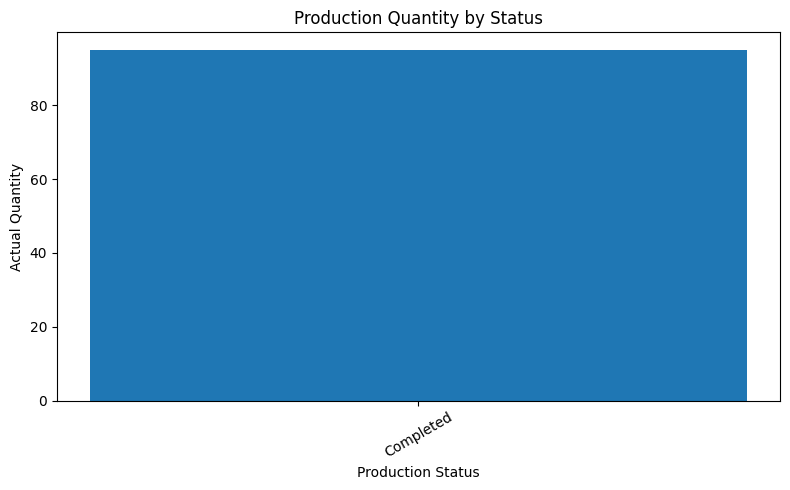

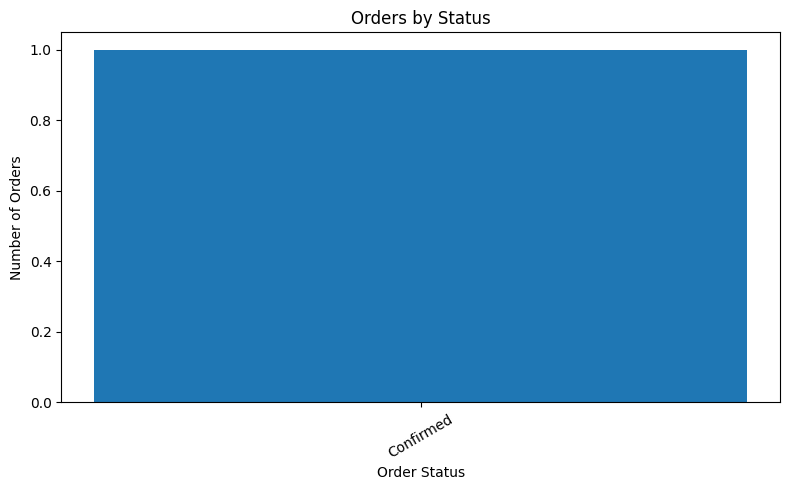

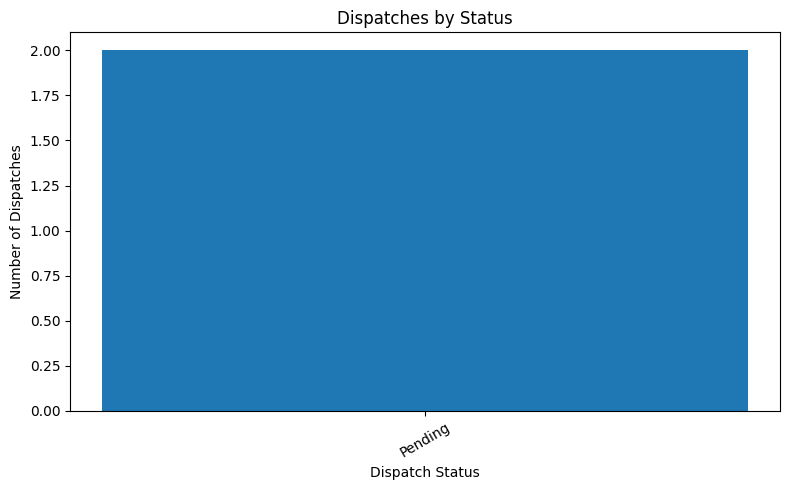

✅ Dashboard visual charts generated


In [283]:

# 📊 DASHBOARD - VISUAL CHARTS

import matplotlib.pyplot as plt

# -------------------------------
# 1. PRODUCTION STATUS CHART
# -------------------------------
if production_summary:
    production_status = [row[0] for row in production_summary]
    production_actual = [row[3] for row in production_summary]

    plt.figure(figsize=(8, 5))
    plt.bar(production_status, production_actual)
    plt.title("Production Quantity by Status")
    plt.xlabel("Production Status")
    plt.ylabel("Actual Quantity")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No production data available for chart.")


# -------------------------------
# 2. ORDER STATUS CHART
# -------------------------------
if order_summary:
    order_status = [row[0] for row in order_summary]
    order_count = [row[1] for row in order_summary]

    plt.figure(figsize=(8, 5))
    plt.bar(order_status, order_count)
    plt.title("Orders by Status")
    plt.xlabel("Order Status")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No order data available for chart.")


# -------------------------------
# 3. DISPATCH STATUS CHART
# -------------------------------
if dispatch_summary:
    dispatch_status = [row[0] for row in dispatch_summary]
    dispatch_count = [row[1] for row in dispatch_summary]

    plt.figure(figsize=(8, 5))
    plt.bar(dispatch_status, dispatch_count)
    plt.title("Dispatches by Status")
    plt.xlabel("Dispatch Status")
    plt.ylabel("Number of Dispatches")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No dispatch data available for chart.")


print("✅ Dashboard visual charts generated")

In [284]:
# 📊 DASHBOARD - RAW MATERIAL STOCK CHART

import matplotlib.pyplot as plt

if raw_material_summary:

    material_names = [row[1] for row in raw_material_summary]
    current_stock = [row[2] for row in raw_material_summary]
    minimum_stock = [row[3] for row in raw_material_summary]

    x = range(len(material_names))

    plt.figure(figsize=(10, 5))

    plt.bar(x, current_stock, width=0.4, label="Current Stock")
    plt.bar(
        [i + 0.4 for i in x],
        minimum_stock,
        width=0.4,
        label="Minimum Stock"
    )

    plt.title("Raw Material Stock vs Minimum Stock")
    plt.xlabel("Raw Material")
    plt.ylabel("Quantity")
    plt.xticks(
        [i + 0.2 for i in x],
        material_names,
        rotation=45,
        ha="right"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("No raw material data available for chart.")

print("✅ Raw material stock chart completed")

No raw material data available for chart.
✅ Raw material stock chart completed


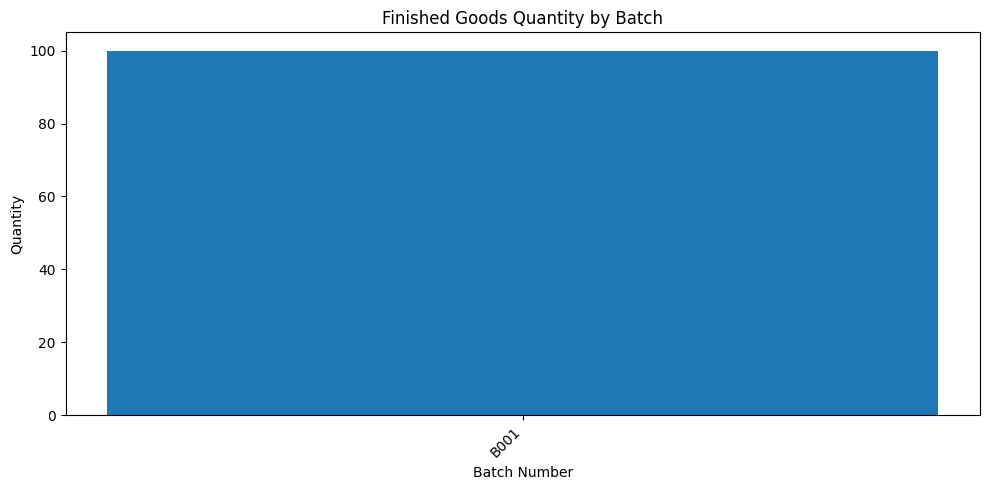

✅ Finished goods chart completed


In [285]:
# 📦 DASHBOARD - FINISHED GOODS CHART

import matplotlib.pyplot as plt

if finished_goods_summary:

    batch_numbers = [row[1] for row in finished_goods_summary]
    quantities = [row[2] for row in finished_goods_summary]

    plt.figure(figsize=(10, 5))
    plt.bar(batch_numbers, quantities)

    plt.title("Finished Goods Quantity by Batch")
    plt.xlabel("Batch Number")
    plt.ylabel("Quantity")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

else:
    print("No finished goods data available for chart.")

print("✅ Finished goods chart completed")

In [286]:
# 📊 DASHBOARD - FINAL SUMMARY

print("🏭 MRPL SMART MANAGEMENT SYSTEM")
print("📊 MANAGEMENT DASHBOARD - FINAL SUMMARY")
print("=" * 80)

# Raw Materials
cursor.execute("SELECT COUNT(*) FROM raw_materials")
total_raw_materials = cursor.fetchone()[0]

# Production
cursor.execute("SELECT COUNT(*) FROM production")
total_production = cursor.fetchone()[0]

# Finished Goods
cursor.execute("SELECT COUNT(*) FROM finished_goods")
total_finished_goods = cursor.fetchone()[0]

# Orders
cursor.execute("SELECT COUNT(*) FROM orders")
total_orders = cursor.fetchone()[0]

# Dispatches
cursor.execute("SELECT COUNT(*) FROM dispatch")
total_dispatches = cursor.fetchone()[0]

# Stock
cursor.execute("SELECT COUNT(*) FROM stock")
total_stock_records = cursor.fetchone()[0]

print(f"🧱 Raw Materials       : {total_raw_materials}")
print(f"🏭 Production Records  : {total_production}")
print(f"📦 Finished Goods      : {total_finished_goods}")
print(f"📝 Orders              : {total_orders}")
print(f"🚚 Dispatches          : {total_dispatches}")
print(f"📊 Stock Records       : {total_stock_records}")

print("=" * 80)
print("✅ DASHBOARD DATA VERIFICATION COMPLETED")

🏭 MRPL SMART MANAGEMENT SYSTEM
📊 MANAGEMENT DASHBOARD - FINAL SUMMARY
🧱 Raw Materials       : 0
🏭 Production Records  : 1
📦 Finished Goods      : 3
📝 Orders              : 1
🚚 Dispatches          : 2
📊 Stock Records       : 0
✅ DASHBOARD DATA VERIFICATION COMPLETED


In [287]:
# 💾 FINAL DATABASE SAVE

conn.commit()

print("💾 Database changes committed successfully")
print("✅ All current database changes are saved")
print("🚀 Backend database phase completed")

💾 Database changes committed successfully
✅ All current database changes are saved
🚀 Backend database phase completed


####Streamlit

In [288]:
# 🚀 MRPL SMART MANAGEMENT SYSTEM
# STREAMLIT APP - BASIC SETUP

app_code = r'''
import streamlit as st
import sqlite3
import pandas as pd

st.set_page_config(
    page_title="MRPL Smart Management System",
    page_icon="🏭",
    layout="wide"
)

# -----------------------------
# DATABASE CONNECTION
# -----------------------------

DB_PATH = "mrpl.db"

def get_connection():
    return sqlite3.connect(DB_PATH)

# -----------------------------
# HEADER
# -----------------------------

st.title("🏭 MRPL Smart Management System")
st.caption("Smart Manufacturing & Quality Management System")

st.divider()

# -----------------------------
# SIDEBAR
# -----------------------------

st.sidebar.title("📋 Navigation")

menu = st.sidebar.radio(
    "Select Module",
    [
        "Dashboard",
        "Raw Materials",
        "Production",
        "Quality Control",
        "Finished Goods",
        "Orders & Dispatch"
    ]
)

# -----------------------------
# DASHBOARD
# -----------------------------

if menu == "Dashboard":

    st.header("📊 Management Dashboard")

    conn = get_connection()

    raw_materials = pd.read_sql_query(
        "SELECT * FROM raw_materials",
        conn
    )

    production = pd.read_sql_query(
        "SELECT * FROM production",
        conn
    )

    finished_goods = pd.read_sql_query(
        "SELECT * FROM finished_goods",
        conn
    )

    orders = pd.read_sql_query(
        "SELECT * FROM orders",
        conn
    )

    dispatch = pd.read_sql_query(
        "SELECT * FROM dispatch",
        conn
    )

    conn.close()

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("🧱 Raw Materials", len(raw_materials))

    with col2:
        st.metric("🏭 Production Records", len(production))

    with col3:
        st.metric("📦 Finished Goods", len(finished_goods))

    col4, col5, col6 = st.columns(3)

    with col4:
        st.metric("📝 Orders", len(orders))

    with col5:
        st.metric("🚚 Dispatches", len(dispatch))

    with col6:
        st.metric("⚠️ Low Stock",
                  len(raw_materials[
                      raw_materials["current_stock"]
                      <= raw_materials["minimum_stock"]
                  ]) if not raw_materials.empty else 0)

# -----------------------------
# OTHER MODULES
# -----------------------------

elif menu == "Raw Materials":
    st.header("🧱 Raw Material Management")
    st.info("Raw Material module")

elif menu == "Production":
    st.header("🏭 Production Management")
    st.info("Production module")

elif menu == "Quality Control":
    st.header("✅ Quality Control")
    st.info("Quality Control module")

elif menu == "Finished Goods":
    st.header("📦 Finished Goods / Warehouse")
    st.info("Finished Goods module")

elif menu == "Orders & Dispatch":
    st.header("🚚 Orders & Dispatch")
    st.info("Orders & Dispatch module")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created successfully")
print("🚀 Basic Streamlit application is ready")

✅ app.py created successfully
🚀 Basic Streamlit application is ready


In [289]:
# 📁 MRPL PROJECT STRUCTURE

import os

folders = [
    "MRPL_Smart_Manufacturing",
    "MRPL_Smart_Manufacturing/models",
    "MRPL_Smart_Manufacturing/data",
    "MRPL_Smart_Manufacturing/utils"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("📁 MRPL PROJECT STRUCTURE")
print("=" * 60)

for folder in folders:
    print("✅", folder)

print("=" * 60)
print("🚀 GitHub-ready project structure created")

📁 MRPL PROJECT STRUCTURE
✅ MRPL_Smart_Manufacturing
✅ MRPL_Smart_Manufacturing/models
✅ MRPL_Smart_Manufacturing/data
✅ MRPL_Smart_Manufacturing/utils
🚀 GitHub-ready project structure created


In [290]:
# 🚀 CREATE FINAL STREAMLIT APP

app_code = r'''
import streamlit as st
import sqlite3
import pandas as pd

# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="MRPL Smart Manufacturing System",
    page_icon="🏭",
    layout="wide"
)

# ==========================================
# DATABASE
# ==========================================

DB_PATH = "mrpl.db"

def get_connection():
    return sqlite3.connect(DB_PATH)

def load_data(table):
    conn = get_connection()
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    conn.close()
    return df

# ==========================================
# HEADER
# ==========================================

st.title("🏭 MRPL Smart Manufacturing System")
st.caption("Smart Manufacturing & Quality Management System")

# ==========================================
# SIDEBAR
# ==========================================

st.sidebar.title("📋 Navigation")

menu = st.sidebar.radio(
    "Select Module",
    [
        "📊 Dashboard",
        "🧱 Raw Materials",
        "🏭 Production",
        "🧪 Quality Control",
        "📦 Finished Goods",
        "🚚 Orders & Dispatch"
    ]
)

# ==========================================
# DASHBOARD
# ==========================================

if menu == "📊 Dashboard":

    st.header("📊 Management Dashboard")

    raw_materials = load_data("raw_materials")
    production = load_data("production")
    finished_goods = load_data("finished_goods")
    orders = load_data("orders")
    dispatch = load_data("dispatch")

    low_stock = 0

    if not raw_materials.empty:
        low_stock = len(
            raw_materials[
                raw_materials["current_stock"]
                <= raw_materials["minimum_stock"]
            ]
        )

    col1, col2, col3 = st.columns(3)

    col1.metric("🧱 Raw Materials", len(raw_materials))
    col2.metric("🏭 Production", len(production))
    col3.metric("📦 Finished Goods", len(finished_goods))

    col4, col5, col6 = st.columns(3)

    col4.metric("📝 Orders", len(orders))
    col5.metric("🚚 Dispatches", len(dispatch))
    col6.metric("⚠️ Low Stock", low_stock)

    st.divider()

    if not production.empty:
        st.subheader("🏭 Production Overview")

        production_chart = production.groupby(
            "status"
        )["actual_quantity"].sum()

        st.bar_chart(production_chart)

    if not orders.empty:
        st.subheader("📝 Order Status")

        order_chart = orders["status"].value_counts()

        st.bar_chart(order_chart)

# ==========================================
# RAW MATERIALS
# ==========================================

elif menu == "🧱 Raw Materials":

    st.header("🧱 Raw Material Management")

    df = load_data("raw_materials")

    if df.empty:
        st.info("No raw material records available.")
    else:
        st.dataframe(
            df,
            use_container_width=True
        )

# ==========================================
# PRODUCTION
# ==========================================

elif menu == "🏭 Production":

    st.header("🏭 Production Management")

    df = load_data("production")

    if df.empty:
        st.info("No production records available.")
    else:
        st.dataframe(
            df,
            use_container_width=True
        )

# ==========================================
# QUALITY CONTROL
# ==========================================

elif menu == "🧪 Quality Control":

    st.header("🧪 Quality Control")

    df = load_data("quality_control")

    if df.empty:
        st.info("No quality control records available.")
    else:
        st.dataframe(
            df,
            use_container_width=True
        )

# ==========================================
# FINISHED GOODS
# ==========================================

elif menu == "📦 Finished Goods":

    st.header("📦 Finished Goods / Warehouse")

    df = load_data("finished_goods")

    if df.empty:
        st.info("No finished goods records available.")
    else:
        st.dataframe(
            df,
            use_container_width=True
        )

# ==========================================
# ORDERS & DISPATCH
# ==========================================

elif menu == "🚚 Orders & Dispatch":

    st.header("🚚 Orders & Dispatch")

    st.subheader("📝 Orders")

    orders = load_data("orders")

    if orders.empty:
        st.info("No order records available.")
    else:
        st.dataframe(
            orders,
            use_container_width=True
        )

    st.subheader("🚚 Dispatch")

    dispatch = load_data("dispatch")

    if dispatch.empty:
        st.info("No dispatch records available.")
    else:
        st.dataframe(
            dispatch,
            use_container_width=True
        )
'''

with open(
    "MRPL_Smart_Manufacturing/app.py",
    "w"
) as f:
    f.write(app_code)

print("✅ Final app.py created")
print("📁 Location: MRPL_Smart_Manufacturing/app.py")
print("🚀 Streamlit app is ready for GitHub")

✅ Final app.py created
📁 Location: MRPL_Smart_Manufacturing/app.py
🚀 Streamlit app is ready for GitHub


In [291]:
# 📦 CREATE REQUIREMENTS.TXT

requirements = """streamlit
pandas
scikit-learn
matplotlib
openpyxl
"""

with open(
    "MRPL_Smart_Manufacturing/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("✅ requirements.txt created")
print("📁 Location: MRPL_Smart_Manufacturing/requirements.txt")

✅ requirements.txt created
📁 Location: MRPL_Smart_Manufacturing/requirements.txt


In [292]:
# 📁 CHECK - MRPL PROJECT FILES

import os

project_path = "MRPL_Smart_Manufacturing"

print("📁 MRPL PROJECT FILES")
print("=" * 60)

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}📂 {os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    📄 {file}")

print("=" * 60)
print("✅ Project structure checked")

📁 MRPL PROJECT FILES
📂 MRPL_Smart_Manufacturing/
    📄 app.py
    📄 requirements.txt
    📂 data/
    📂 utils/
    📂 models/
✅ Project structure checked


In [293]:
# 📦 CREATE PROJECT ZIP FOR GITHUB

import shutil
import os

project_path = "MRPL_Smart_Manufacturing"

zip_path = shutil.make_archive(
    "MRPL_Smart_Manufacturing",
    "zip",
    project_path
)

print("✅ Project ZIP created successfully")
print("📦 File:", zip_path)

print("\n📁 Files inside project:")
for root, dirs, files in os.walk(project_path):
    for file in files:
        print("   📄", os.path.join(root, file))

✅ Project ZIP created successfully
📦 File: /content/MRPL_Smart_Manufacturing.zip

📁 Files inside project:
   📄 MRPL_Smart_Manufacturing/app.py
   📄 MRPL_Smart_Manufacturing/requirements.txt


In [294]:
from google.colab import files

files.download("MRPL_Smart_Manufacturing.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###